In [1]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.10.18


# Python libraries

In [2]:
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import numpy as np
import pandas as pd


import matplotlib as mpl

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path


from cmdstanpy import CmdStanModel



# (Re)load your package
import TEXAS
# 1) Grab the low‐level functions you need

from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler  import StanSampler
from TEXAS.stan.sampler import get_posterior, save_posterior
from TEXAS.stan.io import load_posterior
from TEXAS.plotting import *

import TEXAS
print(TEXAS.__version__)  

import importlib

import bayspline as bsl
import bayspar as bsr

from functools import partial


0.1.0


In [3]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,loN_meso = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(loN_meso,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    loN_meso, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(loN_meso - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.ataN_meso(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient



In [4]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(66.6667,-18.6667),
        'schouten03':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:

    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(0.015,0.280),
        'schouten03':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

## Logistic equations

In [5]:
def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def inverse_logistic_fixed_upper(y, x0, k, b):
    return x0 + (np.log((1 - b)/y - 1) / -k)


def generalized_logistic_model(x, x0, a, b, k, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((a - b) / np.power(1 + Q * np.exp(-k * (x - x0)), 1/v))
    return Y

def generalized_logistic_model_fixed_upper(x, x0, b, k, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((1 - b) / np.power(1 + Q * np.exp(-k * (x - x0)), 1/v))
    return Y

In [6]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


In [7]:
# ## the cmdstanpy needed to run install_cmdstan once on every new computer/new environment

# from cmdstanpy import install_cmdstan
# install_cmdstan(overwrite=True)

In [8]:
# set the path to local folder other than github
login_name = os.getlogin()

from cmdstanpy import set_cmdstan_path
set_cmdstan_path(f"/home/{login_name}/.cmdstan/cmdstan-2.36.0")

from cmdstanpy import cmdstan_path
print(cmdstan_path())

### 1.4.1 Local path on PC
local_documents_path = f'/home/{login_name}/Documents' ### this is the path when code is run on Linux

### 1.4.2 Path to github folder
gitpath_idx = os.getcwd().find('TEXAS')+len('TEXAS')
local_github_path = os.getcwd()[:gitpath_idx]

### 1.4.3 Path to OneDrive folder
local_onedrive_path = f'/home/{login_name}/OneDrive'


### stan_models path 
stan_models_path = local_github_path+'/TEXAS/stan_models/'

/home/rrattan/.cmdstan/cmdstan-2.36.0


# ensure fresh stan models

In [9]:
# importlib.reload(TEXAS.stan.compiler)
# from TEXAS.stan.compiler import StanCompiler

# sc = StanCompiler()
# model = sc.get_model("gen_logi_fixed_hier_crtp_multiv", recompile=False)



In [10]:
os.environ["CC"] = "/usr/bin/gcc"
os.environ["CXX"] = "/usr/bin/g++"
os.environ["TBB_CXX_TYPE"] = "gcc"
os.environ["CMDSTAN"] = os.path.expanduser("~/.cmdstan/cmdstan-2.36.0")
# from TEXAS.stan_utils import refresh_stan_models
# refresh_stan_models(stan_models_dir=stan_models_path,n_jobs=8, clean=True)

In [11]:
### Regression dataset compilation
fpath = fr'{local_github_path}/spreadsheets'
fname = r'culture_mesocosm_combined_rev_030425.csv'

culture_meso_df = pd.read_csv(os.path.join(fpath, fname))
culture_meso_growthrate = culture_meso_df[culture_meso_df['experiment_setup'].isin(['Culture-growth-rate','Culture-oxygen'])].reset_index(drop=True)  
culture_meso_df = culture_meso_df[culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])].reset_index(drop=True)
culture_meso_df['gdgt23ratio'] = culture_meso_df['fGDGT_2']/culture_meso_df['fGDGT_3']
# culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Sinninghe Damste et al. (2002) Journal of Lipid Research'].reset_index(drop=True)
culture_meso_df['Strains_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['Strains'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['Strains_edited'].iloc[i] = culture_meso_df['Strains'].iloc[i]

culture_meso_df['GTDB_genus_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['GTDB_genus'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['GTDB_genus_edited'].iloc[i] = culture_meso_df['GTDB_genus'].iloc[i]

culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Varma et al. (2024) Biogeosciences']
culture_meso_df


,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,Strains_edited,GTDB_genus_edited
0,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
1,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
2,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
3,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
4,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,TEXAS_PSM_mesocosm_RR017,meso_017,Schouten2007,25,0.449778,2.772491,0.693123,2.629108,0.0,mesocosm,...,0.013396,0.635200,0.011792,mesocosm,0.159209,0.266255,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
126,TEXAS_PSM_mesocosm_RR018,meso_018,Schouten2007,32,0.683519,2.627887,0.656972,3.553719,0.0,mesocosm,...,0.015702,0.564495,0.039904,mesocosm,0.169194,0.325581,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
127,TEXAS_PSM_mesocosm_RR019,meso_019,Schouten2007,34,0.606766,3.236153,0.809038,2.318038,0.0,mesocosm,...,0.019677,0.747221,0.011769,mesocosm,0.131807,0.144080,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
128,TEXAS_PSM_mesocosm_RR020,meso_020,Schouten2007,36,0.813041,3.598787,0.899697,2.396907,0.0,mesocosm,...,0.022633,0.822493,0.027125,mesocosm,0.106058,0.056856,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles


In [12]:
fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
fname = 'woa23_decav91C0_t00_04.nc'

T_da = xr.open_dataset(os.path.join(fpath, fname), decode_times=False)
woas23_sst = T_da.isel(depth=0).t_an
woas23_sst

<xarray.DataArray 't_an' (time: 1, lat: 720, lon: 1440)> Size: 4MB
[1036800 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
    depth    float32 4B 0.0
  * time     (time) float32 4B 1.878e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

# Raw coretop

In [13]:
fpath = f'{local_github_path}/spreadsheets/'
fname = 'ds03_processed_coretop_tex.csv'

raw_coretop_df = pd.read_csv(os.path.join(fpath, fname))
raw_coretop_df['scaledRI'] = raw_coretop_df['ringIndex']/4
raw_coretop_df['deltaRI_group'] = pd.cut(raw_coretop_df['deltaRI'],
                                            bins=[-np.inf, -0.3, 0.3, np.inf],
                                            labels=['<-0.3','-0.3 to 0.3','>0.3'])

raw_coretop_df['deltaRI_flip'] = raw_coretop_df['ringIndex'] - raw_coretop_df['TEX_RI']

In [14]:
fig, axs = plot.subplots(proj='cyl', width=7)
axs.format(
    land=True,landcolor='lightgray',landzorder=0,
    coast=True,coastcolor='black',coastzorder=1,
    facecolor='lightblue'
)


grouped = raw_coretop_df.groupby('publicationYear')
for name, group in grouped:
    axs.scatter(group['Longitude'], group['Latitude'], label=int(name), s=20, zorder=2,
                mec='black', mew=0.5,
                c='gray7' if name > 2010 else 'gray3',)
    
axs.legend(loc='b', ncols=6, fontsize=8, frame=False, title='Publication Year')

ValueError: 'vertices' must be 2D with shape (M, 2). Your input has shape (0,).

Figure(nrows=1, ncols=1, figwidth=7.0)

In [15]:
array = [
    [1,2,2,2],
    [3,4,5,0],
    [6,7,8,0],
]
fig, axs = plot.subplots(array,proj=(None,'eck3',None),
                         figsize=(12,11),share=0,
                         wspace=5,
                         hratios=(1,1,1),)

ax = axs[1]
ax.format(
    title=f'Coretop locations (all data; n = {len(raw_coretop_df)})',
    land=True,landcolor='lightgray',landzorder=0,
    coast=True,coastcolor='black',coastzorder=1,
    facecolor='lightblue',
)



grouped = raw_coretop_df.groupby('publicationYear')
for pubYear, group in grouped:

    ax = axs[0]
    ax.scatter(group['TEX86'], group['ringIndex'], label=int(pubYear), 
               s=20, mec='black', mew=0.5,
               c='pink4' if pubYear > 2010 else 'pink9',
               zorder= 2 if pubYear > 2010 else 3,)
    
    ax = axs[1]
    grouped2 = group.groupby('deltaRI_group')
    for deltaRI_group, group2 in grouped2:
        ax.scatter(group2['Longitude'], group2['Latitude'], label=int(pubYear), 
                s=30, 
                mec = 'black', 
                mew = 0.5 if deltaRI_group == '-0.3 to 0.3' else 2,
                zorder = 2 if deltaRI_group == '-0.3 to 0.3' else 3,
                c = 'pink4' if pubYear > 2010 else 'pink9',)


xx = np.linspace(0.2, 0.9, 100)
pred_texRI = -0.77*xx + 3.32*xx**2 + 1.59

pred_texRI_plus03 = pred_texRI + 0.3
pred_texRI_minus03 = pred_texRI - 0.3


### linear fit for all data
lin_reg = LinearRegression()
reg_data = raw_coretop_df.dropna(subset=['TEX86', 'ringIndex']).reset_index(drop=True)
X = reg_data['TEX86'].values.reshape(-1, 1)
y = reg_data['ringIndex'].values
lin_reg.fit(X, y)
slope = lin_reg.coef_[0]
yintercept = lin_reg.intercept_
equation_text = f'$RI = {slope:.4f} * TEX86 + {yintercept:.4f}$'
print(f'Linear regression equation: {equation_text}')

### exponential fit for all data
ln_y = np.log(y)
exp_reg = LinearRegression()
exp_reg.fit(X, ln_y)
exp_slope = exp_reg.coef_[0]
exp_yintercept = exp_reg.intercept_
exp_equation_text = f'$ln(RI) = {exp_slope:.4f} * TEX86 + {exp_yintercept:.4f}$'
print(f'Exponential regression equation: {exp_equation_text}')

sigma = np.std(y - lin_reg.predict(X))
pred_texRI_all = lin_reg.predict(xx.reshape(-1, 1))
pred_ln_texRI_all = np.exp(exp_reg.predict(xx.reshape(-1, 1)))
axs_idx = [0,5,6,7]
for idx in axs_idx:
    axs[idx].plot(xx, pred_texRI, color='pink7', lw=2, label='Zhang16 fit',zorder=1)
    axs[idx].fill_between(xx, pred_texRI_plus03, pred_texRI_minus03,
                   color='pink5', alpha=0.3, label='±0.3 range',
                   zorder=0)
    
    axs[idx].plot(xx, pred_texRI_all, 
                color='k', 
                zorder=3,
                lw=2, label='Linear fit (all data)\n'+equation_text)
    
    axs[idx].plot(xx, pred_ln_texRI_all,
                color='k', 
                ls='--', lw=1, label='Exponential fit (all data)\n'+exp_equation_text,
                zorder=2)
    
    axs[idx].format(
    xlim=(0,1),
    ylim=(0, 4),
    )

raw_coretop_df['pred_new_texRI'] = lin_reg.predict(raw_coretop_df['TEX86'].values.reshape(-1, 1))
raw_coretop_df['pred_new_ln_texRI'] = np.exp(exp_reg.predict(raw_coretop_df['TEX86'].values.reshape(-1, 1)))

raw_coretop_df['new_deltaRI'] = raw_coretop_df['ringIndex'] - raw_coretop_df['pred_new_texRI']
raw_coretop_df['new_ln_deltaRI'] = raw_coretop_df['ringIndex'] - raw_coretop_df['pred_new_ln_texRI']

coretop_until2010 = raw_coretop_df[raw_coretop_df['publicationYear']<=2010].reset_index(drop=True)
coretop_after2010 = raw_coretop_df[raw_coretop_df['publicationYear']>2010].reset_index(drop=True)
axs[0].format(
    lrtitle=f'Zhang16 data (n = {len(coretop_until2010)})\nAll data (n = {len(raw_coretop_df)})',
)

ax = axs[2]
data1 = coretop_until2010['deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)
ax.format(
    xlabel='ΔRI (Zhang16)',
)
### calculate how much data outside of ±0.3
inside_abs03_until2010 = coretop_until2010[np.abs(coretop_until2010['deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_until2010 = coretop_until2010[np.abs(coretop_until2010['deltaRI'])<=0.5].reset_index(drop=True)
inside_abs03_all = raw_coretop_df[np.abs(raw_coretop_df['deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_all = raw_coretop_df[np.abs(raw_coretop_df['deltaRI'])<=0.5].reset_index(drop=True)
ax.axvline(0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(-0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(0.5, color='k', ls=':', lw=1, zorder=3)
ax.axvline(-0.5, color='k', ls=':', lw=1, zorder=3)
ax.format(ltitle=(r"Zhang16's |ΔRI|>0.3 (>0.5)\n"
          +f'Zhang16 data: exclude {(100-len(inside_abs03_until2010)/len(coretop_until2010)*100):.1f}% ({(100-len(inside_abs05_until2010)/len(coretop_until2010)*100):.1f}%)\n'
          +f'All data: exclude {(100-len(inside_abs03_all)/len(raw_coretop_df)*100):.1f}% ({(100-len(inside_abs05_all)/len(raw_coretop_df)*100):.1f}%)'),)

ax = axs[3]
data1 = coretop_until2010['new_deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['new_deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)
ax.format(
    xlabel='ΔRI (linear; all data)',
)
### calculate how much data outside of ±0.3
inside_abs03_until2010_linear = coretop_until2010[np.abs(coretop_until2010['new_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_until2010_linear = coretop_until2010[np.abs(coretop_until2010['new_deltaRI'])<=0.5].reset_index(drop=True)
inside_abs03_all_linear = raw_coretop_df[np.abs(raw_coretop_df['new_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_all_linear = raw_coretop_df[np.abs(raw_coretop_df['new_deltaRI'])<=0.5].reset_index(drop=True)
ax.axvline(0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(-0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(0.5, color='k', ls=':', lw=1, zorder=3)
ax.axvline(-0.5, color='k', ls=':', lw=1, zorder=3)
ax.format(ltitle=(r"Linear |ΔRI|>0.3 (>0.5)\n"
          +f'Zhang16 data: exclude {(100-len(inside_abs03_until2010_linear)/len(coretop_until2010)*100):.1f}% ({(100-len(inside_abs05_until2010_linear)/len(coretop_until2010)*100):.1f}%)\n'
          +f'All data: exclude {(100-len(inside_abs03_all_linear)/len(raw_coretop_df)*100):.1f}% ({(100-len(inside_abs05_all_linear)/len(raw_coretop_df)*100):.1f}%)'),)

ax = axs[4]
data1 = coretop_until2010['new_ln_deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['new_ln_deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)
ax.format(
    xlabel='ΔRI (exponential; all data)',
)
#### calculate how much data outside of ±0.3
inside_abs03_until2010_ln = coretop_until2010[np.abs(coretop_until2010['new_ln_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_until2010_ln = coretop_until2010[np.abs(coretop_until2010['new_ln_deltaRI'])<=0.5].reset_index(drop=True)
inside_abs03_all_ln = raw_coretop_df[np.abs(raw_coretop_df['new_ln_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_all_ln = raw_coretop_df[np.abs(raw_coretop_df['new_ln_deltaRI'])<=0.5].reset_index(drop=True)
ax.axvline(0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(-0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(0.5, color='k', ls=':', lw=1, zorder=3)
ax.axvline(-0.5, color='k', ls=':', lw=1, zorder=3)
ax.format(ltitle=(r"Exponential |ΔRI|>0.3 (>0.5)\n"
          +f'Zhang16 data: exclude {(100-len(inside_abs03_until2010_ln)/len(coretop_until2010)*100):.1f}% ({(100-len(inside_abs05_until2010_ln)/len(coretop_until2010)*100):.1f}%)\n'
          +f'All data: exclude {(100-len(inside_abs03_all_ln)/len(raw_coretop_df)*100):.1f}% ({(100-len(inside_abs05_all_ln)/len(raw_coretop_df)*100):.1f}%)'),)


ax = axs[3]
data1 = coretop_until2010['new_deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['new_deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)
ax.format(
    xlabel='ΔRI (linear; all data)',
)



plot_data = raw_coretop_df[np.abs(raw_coretop_df['new_ln_deltaRI'])>0.5].reset_index(drop=True)
axs[1].scatter(
    plot_data['Longitude'], plot_data['Latitude'],
    zorder=4,
    s=100, mec='red9', mew=0.5, facecolor='none',
)

h, l = axs[1].get_legend_handles_labels()
axs[1].legend(
    [h[i] for i in [1,10,9,-1]], 
    ['until 2010', 'after 2010', 'data with |ΔRI|>0.3','new exponetial |ΔRI|>0.5'],
    # h,l,
    loc='t', ncols=4, frame=False,
)

h, l = axs[0].get_legend_handles_labels()
axs[0].legend(
    [h[i] for i in [0,-1,1,2]],
    [l[i] for i in [0,-1,1,2]],
    # h,l,
    loc='r', ncols=1, frame=False,
)

ax = axs[5]
plot_x = raw_coretop_df[raw_coretop_df['BIT']<=0.1]['TEX86']
plot_y = raw_coretop_df[raw_coretop_df['BIT']<=0.1]['ringIndex']
plot_c = raw_coretop_df[raw_coretop_df['BIT']<=0.1]['BIT']
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,
           c='gray5',
           label='BIT <= 0.1')
h, l = ax.get_legend_handles_labels()
ax.legend(h[-1],l[-1],loc='b', ncols=1, frame=True)
plot_x = raw_coretop_df[raw_coretop_df['BIT']>0.1]['TEX86']
plot_y = raw_coretop_df[raw_coretop_df['BIT']>0.1]['ringIndex']
plot_c = raw_coretop_df[raw_coretop_df['BIT']>0.1]['BIT']
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,

           c=plot_c, cmap='coldhot',
           levels=np.arange(0.1, 1.1, 0.1),
           label='BIT index')
ax.colorbar(m, loc='lr', label='BIT index', ticks=np.arange(0.1, 1.1, 0.1))

ax = axs[6]
plot_x = raw_coretop_df[raw_coretop_df['methaneIndex']<=0.1]['TEX86']
plot_y = raw_coretop_df[raw_coretop_df['methaneIndex']<=0.1]['ringIndex']
plot_c = raw_coretop_df[raw_coretop_df['methaneIndex']<=0.1]['methaneIndex']
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,
           c='gray5',
           label='MI <= 0.1')
h, l = ax.get_legend_handles_labels()
ax.legend(h[-1],l[-1],loc='b', ncols=1, frame=True)
plot_x = raw_coretop_df[raw_coretop_df['methaneIndex']>0.1]['TEX86']
plot_y = raw_coretop_df[raw_coretop_df['methaneIndex']>0.1]['ringIndex']
plot_c = raw_coretop_df[raw_coretop_df['methaneIndex']>0.1]['methaneIndex']
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,
           c=plot_c, cmap='coldhot',
           levels=np.arange(0.1, 1.1, 0.1),
           label='MI')
ax.colorbar(m, loc='lr', label='MI', ticks=np.arange(0.1, 1.1, 0.1))

ax = axs[7]
plot_x = raw_coretop_df[raw_coretop_df['gdgtZeroOverZeroCren']<=0.1]['TEX86']
plot_y = raw_coretop_df[raw_coretop_df['gdgtZeroOverZeroCren']<=0.1]['ringIndex']
plot_c = raw_coretop_df[raw_coretop_df['gdgtZeroOverZeroCren']<=0.1]['gdgtZeroOverZeroCren']
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,
           c='gray5',
           label='<= 10 %GDGT-0 ')
h, l = ax.get_legend_handles_labels()
ax.legend(h[-1],l[-1],loc='b', ncols=1, frame=True)
plot_x = raw_coretop_df[raw_coretop_df['gdgtZeroOverZeroCren']>0.1]['TEX86']
plot_y = raw_coretop_df[raw_coretop_df['gdgtZeroOverZeroCren']>0.1]['ringIndex']
plot_c = raw_coretop_df[raw_coretop_df['gdgtZeroOverZeroCren']>0.1]['gdgtZeroOverZeroCren']*100
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,
           c=plot_c, cmap='coldhot',
           levels=np.arange(10, 101, 10),
           label='%GDGT-0')
ax.colorbar(m, loc='lr', label='%GDGT-0', ticks=np.arange(10, 101, 10))

axs.format(
    abc=True,abcstyle='A',abcloc='ul',
    abcsize=16,abcweight='bold',
)

Linear regression equation: $RI = 3.1517 * TEX86 + 0.5808$
Exponential regression equation: $ln(RI) = 1.4352 * TEX86 + 0.0244$


ValueError: 'vertices' must be 2D with shape (M, 2). Your input has shape (0,).

Figure(nrows=3, ncols=4, figwidth=12.0, figheight=11.0)

In [16]:
import numpy as np
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv

# Define features
features = ['SST', 'fGDGT_0', 'fGDGT_1', 'fGDGT_2',
            'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime',]

# Replace inf/-inf with NaN, then drop rows with any NaN in selected features
X_clean = raw_coretop_df[features].replace([np.inf, -np.inf], np.nan).dropna()
X_array = X_clean.to_numpy(dtype=float)

# Compute mean and covariance matrix
mean_vec = np.mean(X_array, axis=0)
cov_matrix = np.cov(X_array, rowvar=False)
inv_cov_matrix = inv(cov_matrix)

# Calculate Mahalanobis distance
distances = [mahalanobis(x, mean_vec, inv_cov_matrix) for x in X_array]

# Create mask of valid (non-NaN/inf) rows to assign distances back to original df
valid_idx = raw_coretop_df[features].replace([np.inf, -np.inf], np.nan).dropna().index

# Assign distances
raw_coretop_df['mahalanobis_distance'] = np.nan
raw_coretop_df.loc[valid_idx, 'mahalanobis_distance'] = distances
raw_coretop_df['mahalanobis_distance_weights'] = (
    1-((raw_coretop_df['mahalanobis_distance'] - raw_coretop_df['mahalanobis_distance'].min())
    / (raw_coretop_df['mahalanobis_distance'].max() - raw_coretop_df['mahalanobis_distance'].min()))
)   


In [17]:
from scipy.stats import chi2

dof = len(features)  # = 7
confidence = 0.99
threshold = chi2.ppf(confidence, df=dof)
# Square the Mahalanobis distances
squared_distances = np.square(distances)

# Identify which ones exceed the threshold
outlier_flags = squared_distances > threshold
# Assign NaN first
raw_coretop_df['mahalanobis_outlier'] = np.nan

# Assign True/False to valid rows only
raw_coretop_df.loc[valid_idx, 'mahalanobis_outlier'] = outlier_flags


In [18]:
fig, axs = plot.subplots(width=8,ncols=2,nrows=2,
                         proj={1: 'eck3', 2: 'eck3'},
                         hratios=[0.5,1])
ax = axs[0]
axs[0,:].format(
    land=True,landcolor='lightgray',landzorder=0,
    coast=True,coastcolor='black',coastzorder=1,
)
plot_lat = raw_coretop_df['Latitude']
plot_lon = raw_coretop_df['Longitude']
plot_c = raw_coretop_df['mahalanobis_distance']
m = ax.scatter(plot_lon, plot_lat, s=20, zorder=2,
           mec='black', mew=0.5,
           c=plot_c, cmap='viridis',
           levels=np.arange(0, 11, 1),
           label='Mahalanobis distance')

ax = axs[2]
plot_x = raw_coretop_df['TEX86']
plot_y = raw_coretop_df['ringIndex']
plot_c = raw_coretop_df['mahalanobis_distance']
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,
           c=plot_c, cmap='viridis',
           levels=np.arange(0, 11, 1),
           label='Mahalanobis distance')
ax.colorbar(m, loc='b', label='Mahalanobis distance', 
            ticks=np.arange(0, 11, 1))

######################

grouped = raw_coretop_df.groupby('mahalanobis_outlier')
for name, group in grouped:
    axs[1].scatter(group['Longitude'], group['Latitude'], label=name,
                   s=20, zorder=2,
                   mec='black', mew=0.5)

    axs[3].scatter(group['TEX86'], group['ringIndex'], label=name,
               s=20, zorder=2,
               mec='black', mew=0.5)
    
h, l = axs[3].get_legend_handles_labels()
axs[3].legend(h, l, loc='b', ncols=2, frame=False, title='Mahalanobis outlier')

ValueError: 'vertices' must be 2D with shape (M, 2). Your input has shape (0,).

Figure(nrows=2, ncols=2, figwidth=8.0)

# Gridded coretop

In [19]:
fpath = f'{local_github_path}/nc_files/'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_properties_ds_tmp = xr.open_dataset(os.path.join(fpath, fname), engine='h5netcdf')
ocean_properties_ds = xr.merge(
    [ocean_properties_ds_tmp, woas23_sst.rename('sst')],
    compat='override',
    join='override'
)
display(ocean_properties_ds)

fpath = f'{local_github_path}/nc_files/'
fname = 'ds04_gridded_coretop_tex_scaledRI.nc'
coretop_ds = xr.open_dataset(os.path.join(fpath, fname))
coretop_ds

<xarray.Dataset> Size: 25MB
Dimensions:        (lat: 720, lon: 1440, time: 1)
Coordinates:
  * lat            (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
    depth          float32 4B 0.0
  * time           (time) float32 4B 1.878e+03
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 4MB ...
    no3_tc         (lat, lon) float32 4MB ...
    t_sf2tc_avg    (lat, lon) float32 4MB ...
    tc_depth       (lat, lon) float32 4MB ...
    t_tc           (lat, lon) float32 4MB ...
    sst            (time, lat, lon) float32 4MB ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

<xarray.Dataset> Size: 124MB
Dimensions:                    (lat: 720, lon: 1440)
Coordinates:
  * lat                        (lat) float32 3kB -89.88 -89.62 ... 89.62 89.88
  * lon                        (lon) float32 6kB -179.9 -179.6 ... 179.6 179.9
Data variables: (12/15)
    region_ID                  (lon, lat) float64 8MB ...
    tex_count                  (lon, lat) float64 8MB ...
    tex_median                 (lon, lat) float64 8MB ...
    tex_mean                   (lon, lat) float64 8MB ...
    tex_std                    (lon, lat) float64 8MB ...
    scaledRI_count             (lon, lat) float64 8MB ...
    ...                         ...
    gdgt23ratio_count          (lon, lat) float64 8MB ...
    gdgt23ratio_median         (lon, lat) float64 8MB ...
    gdgt23ratio_mean           (lon, lat) float64 8MB ...
    gdgt23ratio_std            (lon, lat) float64 8MB ...
    modernWaterDepth_mean      (lon, lat) float64 8MB ...
    mahalanobis_distance_mean  (lon, lat) float64 8MB ...
Attributes:
    title:             Gridded coretop TEX86 data
    long_name:         statistics of TEX86 for each grid cell with the same l...
    units:             TEX86 [unitless], Scaled RI [unitless]
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    processing_level:  Derived product
    history:           Computed from the global compilation of core-top GDGT ...
    references:        This study

In [20]:
def pred_texRI_fn(x, method_name='zhang16'):
    """
    Predicts the ring index (RI) based on the TEX86 value using the Zhang16 method.
    
    Parameters:
    x (float or array-like): The TEX86 value(s).
    method_name (str): The method to use for prediction. Default is 'zhang16'.
    
    Returns:
    float or array-like: The predicted ring index (RI) value(s).
    """
    if method_name == 'zhang16':
        return -0.77 * x + 3.32 * x**2 + 1.59
    elif method_name == 'linear_thisStudy':
        return 3.1517 * x + 0.5808
    elif method_name == 'exp_thisStudy':
        return np.exp(1.4352 * x + 0.0244)
        
    else:
        raise ValueError(f"Method '{method_name}' is not implemented.")

In [21]:
coretop_ds_merged = xr.merge([coretop_ds, ocean_properties_ds])

coretop_df_temp = coretop_ds_merged.to_dataframe()
coretop_df_temp['pred_new_texRI'] = pred_texRI_fn(coretop_df_temp['tex_median'], method_name='exp_thisStudy')
coretop_df_temp['new_deltaRI'] = coretop_df_temp['scaledRI_median']*4 - coretop_df_temp['pred_new_texRI']
coretop_df_temp = coretop_df_temp.replace([np.inf, -np.inf], np.nan).dropna(subset=['scaledRI_median','gdgt23ratio_median',]).reset_index()
coretop_df = coretop_df_temp[coretop_df_temp['new_deltaRI'].abs()<=0.5].reset_index(drop=True)
coretop_df

,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,mahalanobis_distance_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc,depth,sst,pred_new_texRI,new_deltaRI
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,2.684224,NaN,NaN,-1.636017,30.0,-1.75611,0.0,-1.64841,1.855344,0.184584
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,2.016756,NaN,NaN,-1.586854,50.0,-1.66971,0.0,-1.50741,1.695801,0.056499
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,2.380477,NaN,NaN,-1.692642,30.0,-1.76631,0.0,-1.70171,1.735232,-0.091510
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,2.422640,28.365620,28.426125,-1.498910,10.0,-1.56971,0.0,-1.42831,1.659622,0.073747
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,2.392552,29.118933,29.757280,-1.651191,40.0,-1.75551,0.0,-1.74881,1.674860,0.115210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1350,84.125,46.625,1878.0,3.0,1.0,0.373000,0.373000,NaN,1.0,0.446550,...,1.913307,7.489292,8.702111,-1.237260,95.0,-0.19781,0.0,-1.48951,1.750199,0.036001
1351,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,2.447200,7.665815,9.033155,-1.373924,125.0,0.08159,0.0,-1.64041,1.654927,0.181673
1352,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,4.652252,8.384475,9.424562,-1.477433,150.0,-0.88321,0.0,-1.57180,1.921330,-0.321930
1353,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,3.303009,6.828367,8.589128,-1.377392,150.0,-0.05211,0.0,-1.73371,2.100132,-0.367832


In [22]:
# # ─── prepare sample points ────────────────────────────────────────────────────
# xx = np.linspace(-4, 50, 200)

# # ─── filter & group your data ──────────────────────────────────────────────────
# plot_data = culture_meso_df[culture_meso_df['Temperature'] < 50]
# min_count = 2
# groups = [g for g, df in plot_data.groupby('Strains_edited') if len(df) >= min_count]

# # ─── build the figure with one trace per strain per model ─────────────────────
# fig = go.Figure()

# fig.add_trace(go.Scatter(
#     x=coretop_df['t_sf2tc_avg'],
#     y=coretop_df['scaledRI_median'],
#     mode='markers',
#     marker=dict(color='rgba(178,178,178,1.000)', size=5),
#     name='Core-top data',
#     showlegend=True   # you can allow toggling it via legend if you like
# ))
# core_idx = 0  # index of this core-top trace

# # ─── add global fits ────────────────────────────────────────────────
# X_all = plot_data['Temperature'].values.reshape(-1,1)
# y_all = plot_data['scaledRI'].values

# # -- Linear fit --
# ols_all = LinearRegression().fit(X_all, y_all)
# y_lin_all = ols_all.predict(xx.reshape(-1,1))


# # -- Logistic fixed upper --
# p0f = [25, 0.1, 0.1]
# bf = (0, [50,1,1])
# popt_f_all, _ = curve_fit(logistic_fixed_upper, plot_data['Temperature'], plot_data['scaledRI'], p0=p0f, bounds=bf)
# y_logif_all = logistic_fixed_upper(xx, *popt_f_all)
# r2_logif_all = 1 - np.var(plot_data['scaledRI'] - logistic_fixed_upper(plot_data['Temperature'], *popt_f_all)) / np.var(plot_data['scaledRI'])

# # -- Full logistic --
# p0_all = [25,0.1,0.1,0.1]
# bnd_all = (0, [50,1,1,1])
# popt_all, _ = curve_fit(logistic, plot_data['Temperature'], plot_data['scaledRI'], p0=p0_all, bounds=bnd_all)
# y_logi_all = logistic(xx, *popt_all)
# r2_logi_all = 1 - np.var(plot_data['scaledRI'] - logistic(plot_data['Temperature'], *popt_all)) / np.var(plot_data['scaledRI'])

# ## add global fits to figure
# for model, y, r2 in [
#     ("Linear", y_lin_all, ols_all.score(X_all, y_all)),
#     ("Logistic fixed", y_logif_all, r2_logif_all),
#     ("Logistic", y_logi_all, r2_logi_all)
# ]:
#     fig.add_trace(go.Scatter(
#         x=xx, y=y,
#         mode='lines',
#         name=f"glob_cul_meso -- {model} (R²={r2:.2f})",
#         visible=True
#     ))

# ### add X_all and y_all with coretop data and fit the glob_cul_meso_crtp
# X_all_full = np.concatenate((coretop_df['t_sf2tc_avg'].values.reshape(-1,1), plot_data['Temperature'].values.reshape(-1,1)))
# y_all_full = np.concatenate((coretop_df['scaledRI_median'].values, plot_data['scaledRI'].values))

# # -- Linear fit --
# ols_all_full = LinearRegression().fit(X_all_full, y_all_full)
# y_lin_all_full = ols_all_full.predict(xx.reshape(-1,1))
# # -- Logistic fixed upper --
# p0f_full = [25, 0.1, 0.1]
# bf_full = (0, [50,1,1])
# popt_f_all_full, _ = curve_fit(logistic_fixed_upper, np.squeeze(X_all_full), y_all_full, p0=p0f_full, bounds=bf_full)
# y_logif_all_full = logistic_fixed_upper(xx, *popt_f_all_full)
# r2_logif_all_full = 1 - np.var(y_all_full - logistic_fixed_upper(X_all_full, *popt_f_all_full)) / np.var(y_all_full)
# # -- Full logistic --
# p0_all_full = [25,0.1,0.1,0.1]
# bnd_all_full = (0, [50,1,1,1])
# popt_all_full, _ = curve_fit(logistic, np.squeeze(X_all_full), y_all_full, p0=p0_all_full, bounds=bnd_all_full)
# y_logi_all_full = logistic(xx, *popt_all_full)
# r2_logi_all_full = 1 - np.var(y_all_full - logistic(X_all_full, *popt_all_full)) / np.var(y_all_full)
# ## add global fits to figure
# for model, y, r2 in [
#     ("Linear", y_lin_all_full, ols_all_full.score(X_all_full, y_all_full)),
#     ("Logistic fixed", y_logif_all_full, r2_logif_all_full),
#     ("Logistic", y_logi_all_full, r2_logi_all_full)
# ]:
#     fig.add_trace(go.Scatter(
#         x=xx, y=y,
#         mode='lines',
#         name=f"glob_cul_meso_crtp -- {model} (R²={r2:.2f})",
#         visible=True
#     ))
    
# # ─── add all your strain traces ───────────────────────────
# for strain in groups:
#     df = plot_data[plot_data['Strains_edited'] == strain]
#     X = df['Temperature'].values.reshape(-1,1)
#     y = df['scaledRI'].values
    
#     # -- Linear fit --
#     ols = LinearRegression().fit(X, y)
#     y_lin = ols.predict(xx.reshape(-1,1))
#     fig.add_trace(go.Scatter(
#         x=xx, y=y_lin, 
#         mode='lines',
#         name=f"{strain} -- Linear (R²={ols.score(X,y):.2f})",
#         visible=(strain == groups[0])  # only first strain visible initially
#     ))
    
#     # -- Logistic fixed upper --
#     p0f = [25, 0.1, 0.1]
#     bf = (0, [50,1,1])
#     popt_f, _ = curve_fit(logistic_fixed_upper, df['Temperature'], df['scaledRI'], p0=p0f, bounds=bf)
#     y_logf = logistic_fixed_upper(xx, *popt_f)
#     r2_f = 1 - np.var(df['scaledRI'] - logistic_fixed_upper(df['Temperature'], *popt_f)) / np.var(df['scaledRI'])
#     fig.add_trace(go.Scatter(
#         x=xx, y=y_logf,
#         mode='lines',
#         name=f"{strain} -- Logistic fixed (R²={r2_f:.2f})",
#         visible=False
#     ))
    
#     # -- Full logistic --
#     p0 = [25,0.1,0.1,0.1]
#     bnd = (0, [50,1,1,1])
#     popt, _ = curve_fit(logistic, df['Temperature'], df['scaledRI'], p0=p0, bounds=bnd)
#     y_log = logistic(xx, *popt)
#     r2 = 1 - np.var(df['scaledRI'] - logistic(df['Temperature'], *popt)) / np.var(df['scaledRI'])
#     fig.add_trace(go.Scatter(
#         x=xx, y=y_log,
#         mode='lines',
#         name=f"{strain} -- Logistic (R²={r2:.2f})",
#         visible=False
#     ))
    
#     # -- Always-on scatter of raw data --
#     fig.add_trace(go.Scatter(
#         x=df['Temperature'], y=df['scaledRI'],
#         mode='markers',
#         marker=dict(size=6, line=dict(width=1, color='black')),
#         name=f"{strain} -- data",
#         visible=True
#     ))
# # build a mapping strain → color
# palette1 = px.colors.qualitative.Set1
# palette2 = px.colors.qualitative.Set2

# # make one long list
# all_colors = palette1 + palette2

# # then map strains in order
# strain_colors = {
#     strain: all_colors[i % len(all_colors)]
#     for i, strain in enumerate(groups)
# }

# # now loop through all traces
# for trace in fig.data:
#     # The “cultures + mesocosm only” global fit
#     if trace.name.startswith("glob_cul_meso --"):
#         trace.update(line=dict(
#             color="black",   # pick any CSS name or hex code
#             dash="solid",        # “solid”, “dash”, “dot”, “dashdot”, etc
#             width=4              # thicker line
#         ))

#     # The “cultures + mesocosm + coretop” global fit
#     elif trace.name.startswith("glob_cul_meso_crtp --"):
#         trace.update(line=dict(
#             color="black",
#             dash="dashdot",
#             width=3
#         ))
        
#     # skip the core-top (and any other truly global or background traces)
#     elif trace.name == "Core-top data":
#         continue

#     # split off the strain name (everything before the “ – ”)
#     strain = trace.name.split(" -- ")[0]

#     # pick a color: if it’s one of our strains, use its palette color;
#     # otherwise (e.g. “Global”) fall back to black or whatever you like
#     col = strain_colors.get(strain, "black")

#     # apply to both marker & line
#     trace.update(
#         marker=dict(color=col),
#         line=dict(color=col)
#     )



# # Hide all line traces (fits) by default, leave markers visible
# for trace in fig.data:
#     if "lines" in trace.mode:
#         trace.visible = "legendonly"
#     else:
#         trace.visible = True

# # # Make “raw data” the initial visibility state:
# # for tr in fig.data:
# #     if tr.name == "Core-top data" or tr.name.endswith("-- data"):
# #         tr.visible = True
# #     else:
# #         tr.visible = False
        


# # reposition the model‐dropdown as a vertical nav bar on the left
# fig.update_layout(

#     autosize=False,     # turn off responsive “fill the container”
#     width=900,          # fixed pixel width
#     height=500,         # fixed pixel height
#     margin=dict(l=40, r=40, t=50, b=40),

#     title="Scaled RI vs Temperature",
#     xaxis_title="Temperature (°C)",
#     yaxis_title="Scaled RI",
    
#     yaxis=dict(
#         range=[0.1, 1.1],
#         autorange=False    # turn off auto‐scaling
#     ),

#     # put the legend also on the left, so users can click each strain on/off
#     legend=dict(
#         traceorder="normal",
#         orientation="v",
#         x=1.13,      # just inside the left margin
#         y=0.5,
#         xanchor="left",
#         yanchor="middle",
#         itemsizing="constant"
#     ),
#     template='seaborn',
#     font=dict(
#         family="TeX Gyre Heros",
#         size=14,
#         color="black"
#     ),
    
# )

# # lock X/Y so the units match (remove if you don’t want a 1:1 scale)
# fig.update_xaxes(constrain='domain')            # keep the X‐axis from expanding

# # set a default
# # fig.update_layout(template="plotly_white")

# fig.show()

# # in your Python script / notebook:
# fig.write_html(
#   os.path.join(local_github_path, 'html_figures', 'scaledRI_vs_Temperature.html'),
#   include_plotlyjs="cdn",   # pull Plotly.js from the CDN
#   full_html=False           # only the <div>+<script>—no <html>/<body> wrapper
# )


In [23]:
culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='culture']
culture_data_full = culture_data_full.replace([np.inf, -np.inf], np.nan).dropna(subset=['Temperature',
                                                                                        'scaledRI',
                                                                                        'gdgt23ratio']).reset_index(drop=True)
meso_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='mesocosm']
meso_data_full = meso_data_full.replace([np.inf, -np.inf], np.nan).dropna(subset=['Temperature',
                                                                                'scaledRI',
                                                                                'gdgt23ratio']).reset_index(drop=True)

coretop_df = coretop_df.replace([np.inf, -np.inf],np.nan).dropna(subset=['scaledRI_median','gdgt23ratio_median']).reset_index(drop=True)
coretop_df = coretop_df[coretop_df['gdgt23ratio_median']<100].reset_index(drop=True)
coretop_df


,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,mahalanobis_distance_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc,depth,sst,pred_new_texRI,new_deltaRI
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,2.684224,NaN,NaN,-1.636017,30.0,-1.75611,0.0,-1.64841,1.855344,0.184584
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,2.016756,NaN,NaN,-1.586854,50.0,-1.66971,0.0,-1.50741,1.695801,0.056499
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,2.380477,NaN,NaN,-1.692642,30.0,-1.76631,0.0,-1.70171,1.735232,-0.091510
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,2.422640,28.365620,28.426125,-1.498910,10.0,-1.56971,0.0,-1.42831,1.659622,0.073747
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,2.392552,29.118933,29.757280,-1.651191,40.0,-1.75551,0.0,-1.74881,1.674860,0.115210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1349,84.125,46.625,1878.0,3.0,1.0,0.373000,0.373000,NaN,1.0,0.446550,...,1.913307,7.489292,8.702111,-1.237260,95.0,-0.19781,0.0,-1.48951,1.750199,0.036001
1350,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,2.447200,7.665815,9.033155,-1.373924,125.0,0.08159,0.0,-1.64041,1.654927,0.181673
1351,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,4.652252,8.384475,9.424562,-1.477433,150.0,-0.88321,0.0,-1.57180,1.921330,-0.321930
1352,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,3.303009,6.828367,8.589128,-1.377392,150.0,-0.05211,0.0,-1.73371,2.100132,-0.367832


# PhanSST on TEX-RI relationship

In [24]:
fpath = fr'{local_github_path}/spreadsheets/fitted_models'
fname = 'ols_tex_thermoT_thisStudy.pkl'

import pickle

with open(os.path.join(fpath,fname), 'rb') as f:
    ols_tex_thermoT = pickle.load(f)
    
slope = ols_tex_thermoT.coef_[0]
intercept = ols_tex_thermoT.intercept_

fpath = fr'{local_github_path}/spreadsheets/published_data'
fname = 'PhanSST_v001.csv'
PhanSST_df = pd.read_csv(os.path.join(fpath,fname))
PhanSST_df['pubYear'] = PhanSST_df['LeadAuthor'] + PhanSST_df['Year'].astype(str)

In [25]:
PhanTEX_df = PhanSST_df[PhanSST_df['ProxyType']=='tex'].reset_index(drop=True)
PhanTEX_df = PhanTEX_df.rename(columns={'ProxyValue':'TEX86',
                                        'GDGT0':'fGDGT_0',
                                        'GDGT1':'fGDGT_1',
                                        'GDGT2':'fGDGT_2',
                                        'GDGT3':'fGDGT_3',
                                        'Cren':'fGDGT_cren',
                                        'Crenisomer':'fGDGT_cren_prime'})
PhanTEX_df = PhanTEX_df.dropna(subset=['fGDGT_0','fGDGT_1','fGDGT_2','fGDGT_3','fGDGT_cren','fGDGT_cren_prime']).reset_index(drop=True)


features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
PhanTEX_df['ringIndex'] = np.array([PhanTEX_df[features[i]]*ringNumbers_dict_zhang16.get(features[i]) for i in range(len(features))]).sum(axis=0)
PhanTEX_df['pred_texRI'] = pred_texRI_fn(PhanTEX_df['TEX86'], method_name='zhang16')
PhanTEX_df['deltaRI'] = PhanTEX_df['pred_texRI'] - PhanTEX_df['ringIndex']
PhanTEX_df['deltaRI_flip'] = PhanTEX_df['ringIndex'] - PhanTEX_df['pred_texRI']
PhanTEX_df['scaledRI'] = PhanTEX_df['ringIndex'] / 4
PhanTEX_df['gdgt23ratio'] = PhanTEX_df['fGDGT_2'] / PhanTEX_df['fGDGT_3']

PhanTEX_df['thermoT_linear'] = (PhanTEX_df['TEX86'] - intercept)/slope
PhanTEX_df['SST_Schouten02'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='schouten02')
PhanTEX_df['SST_Kim10'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='kim2010_tex86H')
PhanTEX_df['pred_new_linear_texRI'] = pred_texRI_fn(PhanTEX_df['TEX86'], method_name='linear_thisStudy')
PhanTEX_df['pred_new_exp_texRI'] = pred_texRI_fn(PhanTEX_df['TEX86'], method_name='exp_thisStudy')
PhanTEX_df['new_linear_deltaRI'] = PhanTEX_df['ringIndex'] - PhanTEX_df['pred_new_linear_texRI']
PhanTEX_df['new_exp_deltaRI'] = PhanTEX_df['ringIndex'] - PhanTEX_df['pred_new_exp_texRI']

In [26]:
PhanTEX_df['hothouse_flag'] = [
    1 if PhanTEX_df['Period'][i] in ['Cretaceous'] 
    or PhanTEX_df['Stage'][i] in ['Lutetian', 'Ypresian'] 
    else 0 for i in range(len(PhanTEX_df))
]
PhanTEX_df['hothouse_flag'].unique()

array([1, 0])

In [27]:
array = [
    [1,1,2,2],
    [1,1,0,0],
    [3,4,5,0]
]
fig, axs = plot.subplots(array,proj=(None,'eck3',None),
                         figsize=(12,11),
                         share=0,
                        #  wspace=8,
                         hratios=(1,1,1),)

ax = axs[1]
ax.format(
    title=f'Coretop locations (all data; n = {len(raw_coretop_df)})',
    land=True,landcolor='lightgray',landzorder=0,
    coast=True,coastcolor='black',coastzorder=1,
    facecolor='lightblue',
)
ax = axs[0]
plot_data = raw_coretop_df
ax.scatter(plot_data['TEX86'], plot_data['ringIndex'], label=int(pubYear), 
        # s=10,0
        s=plot_data['mahalanobis_distance_weights']**10, 
        # mec='k', 
        # mew=0.5,
        #    c='pink4' if pubYear > 2010 else 'pink9',
        c=plot_data['mahalanobis_distance'],levels=np.arange(0, 11, 1),
        cmap='magma_r',
        zorder=3)


grouped = raw_coretop_df.groupby('publicationYear')
for pubYear, group in grouped:

    # ax = axs[0]
    # ax.scatter(group['TEX86'], group['ringIndex'], label=int(pubYear), 
    #         s=10,
    #         #    s=((1/group['mahalanobis_distance'])*10)**2, 
    #         #    mec='black', mew=0.5,
    #         #    c='pink4' if pubYear > 2010 else 'pink9',
    #         c=group['mahalanobis_distance'],
    #         zorder= 2 if pubYear > 2010 else 3,)
    
    ax = axs[1]
    grouped2 = group.groupby('deltaRI_group')
    for deltaRI_group, group2 in grouped2:
        ax.scatter(group2['Longitude'], group2['Latitude'], label=int(pubYear), 
                s=30, 
                mec = 'black', 
                mew = 0.5 if deltaRI_group == '-0.3 to 0.3' else 2,
                zorder = 2 if deltaRI_group == '-0.3 to 0.3' else 3,
                c = 'pink4' if pubYear > 2010 else 'pink9',)

# ### plot PhanTEX data
# paleo_grouped = PhanTEX_df.groupby('hothouse_flag')
# hothouse_flag_dict = {0: 'non-hothouse', 1: 'hothouse'}
# for hothouse_flag, group in paleo_grouped: 
#     ax = axs[0]
#     ax.scatter(group['TEX86'], group['ringIndex'], label=hothouse_flag_dict.get(hothouse_flag), 
#                s=10, 
#             #    mec='black', mew=0.5,
#                c='blue9' if hothouse_flag == 1 else 'blue4',
#                zorder= 1 if hothouse_flag == 1 else 0)

xx = np.linspace(0.2, 0.9, 100)
pred_texRI = -0.77*xx + 3.32*xx**2 + 1.59
pred_texRI_plus03 = pred_texRI + 0.3
pred_texRI_minus03 = pred_texRI - 0.3


### linear fit for all data
lin_reg = LinearRegression()
min_tex_threshold = 0
reg_data = raw_coretop_df[raw_coretop_df['TEX86']>min_tex_threshold].dropna(subset=['TEX86', 'ringIndex','mahalanobis_distance_weights']).reset_index(drop=True)
X = reg_data['TEX86'].values.reshape(-1, 1)
y = reg_data['ringIndex'].values
lin_reg.fit(X, y)
slope = lin_reg.coef_[0]
yintercept = lin_reg.intercept_
equation_text = f'$RI = {slope:.4f} * TEX86 + {yintercept:.4f}$'
print(f'Linear regression equation: {equation_text}')

## weighted linear regression based on mahalanobis distance (higher distance = lower weight)
weights = reg_data['mahalanobis_distance_weights']
lin_reg_weighted = LinearRegression()
lin_reg_weighted.fit(X, y, sample_weight=weights)
slope_weighted = lin_reg_weighted.coef_[0]
yintercept_weighted = lin_reg_weighted.intercept_
equation_text_weighted = f'$RI = {slope_weighted:.4f} * TEX86 + {yintercept_weighted:.4f}$'
print(f'Weighted linear regression equation: {equation_text_weighted}')

### linear fit for only data with mahalanobis distance < 4
lin_reg_mahalanobis = LinearRegression()
reg_data_mahalanobis = reg_data[reg_data['mahalanobis_distance'] < 4].reset_index(drop=True)
X_mahalanobis = reg_data_mahalanobis['TEX86'].values.reshape(-1, 1)
y_mahalanobis = reg_data_mahalanobis['ringIndex'].values
lin_reg_mahalanobis.fit(X_mahalanobis, y_mahalanobis)
slope_mahalanobis = lin_reg_mahalanobis.coef_[0]
yintercept_mahalanobis = lin_reg_mahalanobis.intercept_
equation_text_mahalanobis = f'$RI = {slope_mahalanobis:.4f} * TEX86 + {yintercept_mahalanobis:.4f}$'
print(f'Linear regression equation (mahalanobis < 4): {equation_text_mahalanobis}')

### exponential fit for all data
ln_y = np.log(y)
exp_reg = LinearRegression()
exp_reg.fit(X, ln_y)
exp_slope = exp_reg.coef_[0]
exp_yintercept = exp_reg.intercept_
exp_equation_text = f'$ln(RI) = {exp_slope:.4f} * TEX86 + {exp_yintercept:.4f}$'
print(f'Exponential regression equation: {exp_equation_text}')

sigma = np.std(y - lin_reg.predict(X))
pred_texRI_all = lin_reg.predict(xx.reshape(-1, 1))
pred_ln_texRI_all = np.exp(exp_reg.predict(xx.reshape(-1, 1)))

### weighted exponential fit based on mahalanobis distance (higher distance = lower weight)
weights_exp = reg_data['mahalanobis_distance_weights']
exp_reg_weighted = LinearRegression()
exp_reg_weighted.fit(X, ln_y, sample_weight=weights_exp)
exp_slope_weighted = exp_reg_weighted.coef_[0]
exp_yintercept_weighted = exp_reg_weighted.intercept_
exp_equation_text_weighted = f'$ln(RI) = {exp_slope_weighted:.4f} * TEX86 + {exp_yintercept_weighted:.4f}$'
print(f'Weighted exponential regression equation: {exp_equation_text_weighted}')

### exp fit for only data with mahalanobis distance < 4
exp_reg_mahalanobis = LinearRegression()
reg_data_mahalanobis = reg_data[reg_data['mahalanobis_distance'] < 4].reset_index(drop=True)
X_mahalanobis = reg_data_mahalanobis['TEX86'].values.reshape(-1, 1)
y_mahalanobis = reg_data_mahalanobis['ringIndex'].values
exp_reg_mahalanobis.fit(X_mahalanobis, np.log(y_mahalanobis))
exp_slope_mahalanobis = exp_reg_mahalanobis.coef_[0]
exp_yintercept_mahalanobis = exp_reg_mahalanobis.intercept_
exp_equation_text_mahalanobis = f'$ln(RI) = {exp_slope_mahalanobis:.4f} * TEX86 + {exp_yintercept_mahalanobis:.4f}$'
print(f'Exponential regression equation (mahalanobis < 4): {exp_equation_text_mahalanobis}')

### np.log10 fit for all data
log10_y = np.log10(y)
log10_reg = LinearRegression()
log10_reg.fit(X, log10_y)
log10_slope = log10_reg.coef_[0]
log10_yintercept = log10_reg.intercept_
log10_equation_text = f'$log10(RI) = {log10_slope:.4f} * TEX86 + {log10_yintercept:.4f}$'
print(f'Log10 regression equation: {log10_equation_text}')

## weighted 3-degree polynomial fit based on mahalanobis distance (higher distance = lower weight)
from sklearn.preprocessing import PolynomialFeatures  # noqa: E402
poly_features = PolynomialFeatures(degree=4)
X_poly = poly_features.fit_transform(X)
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y, sample_weight=weights)
poly_slope = poly_reg.coef_[1]
poly_yintercept = poly_reg.intercept_
poly_equation_text = f'$RI = {poly_slope:.4f} * TEX86^3 + {poly_reg.coef_[0]:.4f} * TEX86^2 + {poly_yintercept:.4f}$'
print(f'Polynomial regression equation: {poly_equation_text}')
axs_idx = [0]
for idx in axs_idx:
    axs[idx].plot(xx, pred_texRI, color='pink7', lw=1, label='Zhang16 fit',zorder=4)
    # axs[idx].fill_between(xx, pred_texRI_plus03, pred_texRI_minus03,
    #                color='pink5', alpha=0.3, label='±0.3 range',
    #                zorder=0)
    
    axs[idx].plot(xx, poly_reg.predict(poly_features.transform(xx.reshape(-1, 1))),
                color='pink7', 
                ls='--', lw=1, label='Polynomial fit (all data)\n'+poly_equation_text,
                zorder=4)
    
    axs[idx].plot(xx, pred_texRI_all, 
                color='k', 
                zorder=5,
                lw=1, label='Linear fit (all data)\n'+equation_text)
    
    axs[idx].plot(xx, lin_reg_weighted.predict(xx.reshape(-1, 1)),
                color='k', 
                ls=':', lw=1, label='Weighted linear fit (all data)\n'+equation_text_weighted)
    
    
    axs[idx].plot(xx, lin_reg_mahalanobis.predict(xx.reshape(-1, 1)),
                color='k', 
                ls='--', lw=1, label='Linear fit (mahalanobis < 4)\n'+equation_text_mahalanobis)

    axs[idx].plot(xx, pred_ln_texRI_all,
                color='gray5', 
                lw=1, label='Exponential fit (all data)\n'+exp_equation_text,
                zorder=6)
    
    axs[idx].plot(xx, np.exp(exp_reg_weighted.predict(xx.reshape(-1, 1))),
                color='gray5', 
                ls=':', lw=1, label='Weighted exponential fit (all data)\n'+exp_equation_text_weighted,
                zorder=6)
    
    axs[idx].plot(xx, np.exp(exp_reg_mahalanobis.predict(xx.reshape(-1, 1))),
                color='gray5', 
                ls='--', lw=1, label='Exponential fit (mahalanobis < 4)\n'+exp_equation_text_mahalanobis,
                zorder=7)
    axs[idx].plot(xx, np.power(10, log10_reg.predict(xx.reshape(-1, 1))),
                color='teal5',
                lw=1, label='Log10 fit (all data)\n'+log10_equation_text,
                zorder=8)
    
    axs[idx].format(
    xlim=(0,1),
    ylim=(-0.4,4.4),
    )

raw_coretop_df['pred_new_texRI'] = lin_reg.predict(raw_coretop_df['TEX86'].values.reshape(-1, 1))
raw_coretop_df['pred_new_ln_texRI'] = np.exp(exp_reg.predict(raw_coretop_df['TEX86'].values.reshape(-1, 1)))

raw_coretop_df['new_deltaRI'] = raw_coretop_df['ringIndex'] - raw_coretop_df['pred_new_texRI']
raw_coretop_df['new_ln_deltaRI'] = raw_coretop_df['ringIndex'] - raw_coretop_df['pred_new_ln_texRI']

coretop_until2010 = raw_coretop_df[raw_coretop_df['publicationYear']<=2010].reset_index(drop=True)
coretop_after2010 = raw_coretop_df[raw_coretop_df['publicationYear']>2010].reset_index(drop=True)
axs[0].format(
    lrtitle=f'Zhang16 data (n = {len(coretop_until2010)})\nAll data (n = {len(raw_coretop_df)})',
)

ax = axs[2]
data1 = coretop_until2010['deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)


ax.twinx().hist(PhanTEX_df['deltaRI'],
        bins=np.arange(-1, 1.1, 0.1),
        histtype='step',
        color='k', lw=1, label='PhanTEX (Zhang16)',
        zorder=3)

ax.format(
    xlabel='ΔRI (Zhang16)',
)
### calculate how much data outside of ±0.3
inside_abs03_until2010 = coretop_until2010[np.abs(coretop_until2010['deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_until2010 = coretop_until2010[np.abs(coretop_until2010['deltaRI'])<=0.5].reset_index(drop=True)
inside_abs03_all = raw_coretop_df[np.abs(raw_coretop_df['deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_all = raw_coretop_df[np.abs(raw_coretop_df['deltaRI'])<=0.5].reset_index(drop=True)
ax.axvline(0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(-0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(0.5, color='k', ls=':', lw=1, zorder=3)
ax.axvline(-0.5, color='k', ls=':', lw=1, zorder=3)
ax.format(ltitle=(r"Zhang16's |ΔRI|>0.3 (>0.5)"
          +f'\nZhang16 data: exclude {(100-len(inside_abs03_until2010)/len(coretop_until2010)*100):.1f}% ({(100-len(inside_abs05_until2010)/len(coretop_until2010)*100):.1f}%)\n'
          +f'All data: exclude {(100-len(inside_abs03_all)/len(raw_coretop_df)*100):.1f}% ({(100-len(inside_abs05_all)/len(raw_coretop_df)*100):.1f}%)'),)

ax = axs[3]
data1 = coretop_until2010['new_deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['new_deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)
ax.twinx().hist(PhanTEX_df['new_linear_deltaRI'],
        bins=np.arange(-1, 1.1, 0.1),
        histtype='step',
        color='k', lw=1, label='PhanTEX (linear)',
        zorder=3)

ax.format(
    xlabel='ΔRI (linear; all data)',
)
### calculate how much data outside of ±0.3
inside_abs03_until2010_linear = coretop_until2010[np.abs(coretop_until2010['new_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_until2010_linear = coretop_until2010[np.abs(coretop_until2010['new_deltaRI'])<=0.5].reset_index(drop=True)
inside_abs03_all_linear = raw_coretop_df[np.abs(raw_coretop_df['new_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_all_linear = raw_coretop_df[np.abs(raw_coretop_df['new_deltaRI'])<=0.5].reset_index(drop=True)
ax.axvline(0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(-0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(0.5, color='k', ls=':', lw=1, zorder=3)
ax.axvline(-0.5, color='k', ls=':', lw=1, zorder=3)
ax.format(ltitle=(r"Linear |ΔRI|>0.3 (>0.5)"
          +f'\nZhang16 data: exclude {(100-len(inside_abs03_until2010_linear)/len(coretop_until2010)*100):.1f}% ({(100-len(inside_abs05_until2010_linear)/len(coretop_until2010)*100):.1f}%)\n'
          +f'All data: exclude {(100-len(inside_abs03_all_linear)/len(raw_coretop_df)*100):.1f}% ({(100-len(inside_abs05_all_linear)/len(raw_coretop_df)*100):.1f}%)'),)

ax = axs[4]
data1 = coretop_until2010['new_deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['new_deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)

ax.twinx().hist(PhanTEX_df['new_exp_deltaRI'],
        bins=np.arange(-1, 1.1, 0.1),
        histtype='step',
        color='k', lw=1, label='PhanTEX (exponential)',
        zorder=3)

ax.format(
    xlabel='ΔRI (exponential; all data)',
)
#### calculate how much data outside of ±0.3
inside_abs03_until2010_ln = coretop_until2010[np.abs(coretop_until2010['new_ln_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_until2010_ln = coretop_until2010[np.abs(coretop_until2010['new_ln_deltaRI'])<=0.5].reset_index(drop=True)
inside_abs03_all_ln = raw_coretop_df[np.abs(raw_coretop_df['new_ln_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_all_ln = raw_coretop_df[np.abs(raw_coretop_df['new_ln_deltaRI'])<=0.5].reset_index(drop=True)
ax.axvline(0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(-0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(0.5, color='k', ls=':', lw=1, zorder=3)
ax.axvline(-0.5, color='k', ls=':', lw=1, zorder=3)
ax.format(ltitle=(r"Exponential |ΔRI|>0.3 (>0.5)"
          +f'\nZhang16 data: exclude {(100-len(inside_abs03_until2010_ln)/len(coretop_until2010)*100):.1f}% ({(100-len(inside_abs05_until2010_ln)/len(coretop_until2010)*100):.1f}%)\n'
          +f'All data: exclude {(100-len(inside_abs03_all_ln)/len(raw_coretop_df)*100):.1f}% ({(100-len(inside_abs05_all_ln)/len(raw_coretop_df)*100):.1f}%)'),)


ax = axs[3]
data1 = coretop_until2010['new_deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['new_deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)

ax.format(
    xlabel='ΔRI (linear; all data)',
)



plot_data = raw_coretop_df[np.abs(raw_coretop_df['new_ln_deltaRI'])>0.5].reset_index(drop=True)
axs[1].scatter(
    plot_data['Longitude'], plot_data['Latitude'],
    zorder=4,
    s=100, mec='red9', mew=0.5, facecolor='none',
)

h, l = axs[1].get_legend_handles_labels()
axs[1].legend(
    [h[i] for i in [1,10,9,-1]], 
    ['until 2010', 'after 2010', 'data with |ΔRI|>0.3','new exponetial |ΔRI|>0.5'],
    # h,l,
    loc='b', ncols=2, frame=False,
)

h, l = axs[0].get_legend_handles_labels()
axs[0].legend(
    [h[i] for i in [0,-1,1,2]],
    [l[i] for i in [0,-1,1,2]],
    # h,l,
    loc='ul', ncols=1, frame=False,
    bbox_to_anchor=(0.05, 1),
)

axs[0].format(facecolor='gray3')

axs.format(
    abc=True,abcstyle='A',abcloc='ul',
    abcsize=16,abcweight='bold',
)

Linear regression equation: $RI = 3.1398 * TEX86 + 0.5876$
Weighted linear regression equation: $RI = 3.1008 * TEX86 + 0.6111$
Linear regression equation (mahalanobis < 4): $RI = 3.0884 * TEX86 + 0.6256$
Exponential regression equation: $ln(RI) = 1.4312 * TEX86 + 0.0269$
Weighted exponential regression equation: $ln(RI) = 1.4053 * TEX86 + 0.0445$
Exponential regression equation (mahalanobis < 4): $ln(RI) = 1.3878 * TEX86 + 0.0601$
Log10 regression equation: $log10(RI) = 0.6215 * TEX86 + 0.0117$
Polynomial regression equation: $RI = -11.5641 * TEX86^3 + 0.0000 * TEX86^2 + 2.7901$


ValueError: 'vertices' must be 2D with shape (M, 2). Your input has shape (0,).

Figure(nrows=3, ncols=4, figwidth=12.0, figheight=11.0)

In [28]:
raw_coretop_df.columns

Index(['sampleID', 'index_column', 'core_name', 'core_type',
       'sample_depth_start', 'sample_depth_end', 'Latitude', 'Longitude',
       'modernWaterDepth', 'TEX86', 'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3',
       'fGDGT_cren', 'fGDGT_cren_prime', 'BIT', 'publicationYear',
       'reference_name', 'remark', 'reference_link', 'dataset_DOI',
       'ringIndex', 'scaledRI', 'gdgt23ratio', 'methaneIndex',
       'gdgtZeroOverZeroCren', 'TEX_RI', 'deltaRI', 'QC_flag', 'match_lat',
       'match_lon', 'match_depth', 'SST', 'thermocline_depth', 'thermocline_T',
       'thermocline_T_depthIntegral', 'SSN', 'thermocline_nitrate',
       'thermocline_nitrate_depthIntegral', 'region_ID', 'regionName',
       'mahalanobis_distance', 'mahalanobis_distance_weights',
       'mahalanobis_outlier', 'deltaRI_group', 'deltaRI_flip',
       'pred_new_texRI', 'pred_new_ln_texRI', 'new_deltaRI', 'new_ln_deltaRI'],
      dtype='object')

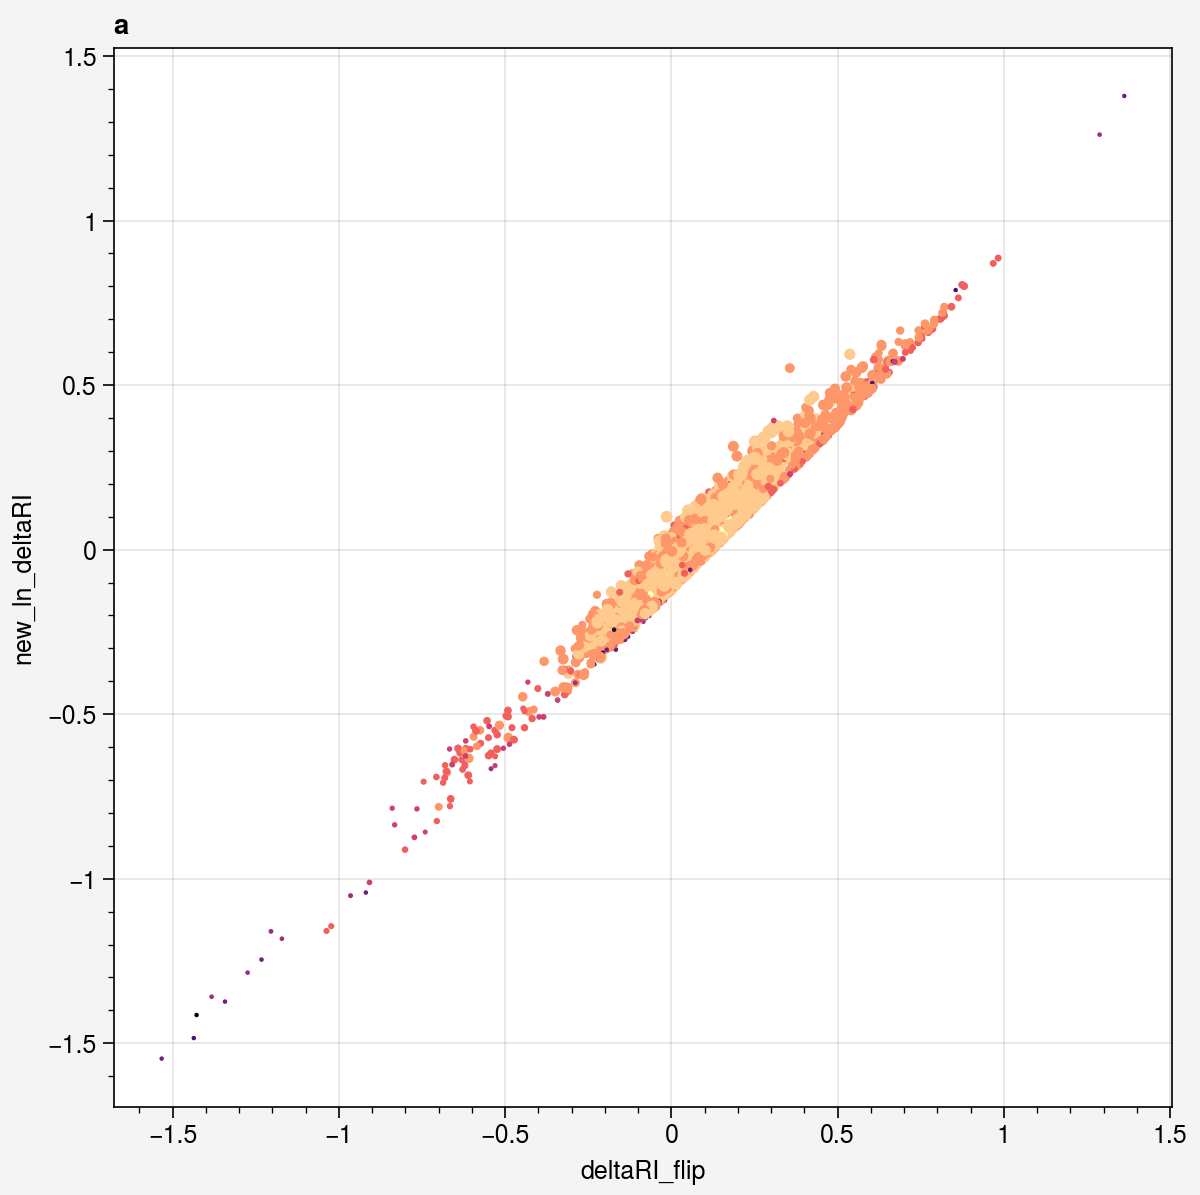

In [29]:
fig, axs = plot.subplots(width=6)

ax = axs[0]
plot_x = raw_coretop_df['deltaRI_flip']
plot_y = raw_coretop_df['new_ln_deltaRI']
ax.scatter(plot_x, plot_y, 
           s=raw_coretop_df['mahalanobis_distance_weights']**10,
           c=raw_coretop_df['mahalanobis_distance'], levels=np.arange(0, 11, 1),
           cmap='magma_r',
           zorder=3)

# Input Data for stan models

In [30]:
t_cul = culture_data_full['Temperature'].astype(float).tolist() 
scaledRI_cul = culture_data_full['scaledRI'].astype(float).tolist() 
gdgt23ratio_cul = culture_data_full['gdgt23ratio'].astype(float).tolist()

t_meso = meso_data_full['Temperature'].astype(float).tolist()
scaledRI_meso = meso_data_full['scaledRI'].astype(float).tolist()
gdgt23ratio_meso = meso_data_full['gdgt23ratio'].astype(float).tolist()



In [35]:
## combined coretop and culture/mesocosm to a single dataframe
sel_cul_data = culture_data_full.reset_index(drop=True)

combined_df = pd.DataFrame({
    't_sf2tc': pd.concat([coretop_df['t_sf2tc_avg'], 
                          sel_cul_data['Temperature'], 
                          meso_data_full['Temperature']]),
    'scaledRI': pd.concat([coretop_df['scaledRI_median'], 
                           sel_cul_data['scaledRI'], 
                           meso_data_full['scaledRI']]),
    'gdgt23ratio': pd.concat([coretop_df['gdgt23ratio_median'], 
                              sel_cul_data['gdgt23ratio'], 
                              meso_data_full['gdgt23ratio']]),
    'datatype': pd.concat(
        [pd.Series(['coretop'] * len(coretop_df)),
         pd.Series(['culture'] * len(sel_cul_data)),
         pd.Series(['mesocosm'] * len(meso_data_full))]
    )
})

display(combined_df)

########
fpath = f'/home/rrattan/Documents/GitHub/TEXAS/spreadsheets'
fname = 'combined_df_culmesocore_griddedRI.csv'
combined_df.to_csv(os.path.join(fpath,fname))

,t_sf2tc,scaledRI,gdgt23ratio,datatype
0,-1.636017,0.509982,1.502839,coretop
1,-1.586854,0.438075,2.833333,coretop
2,-1.692642,0.410931,1.824832,coretop
3,-1.498910,0.433342,2.066396,coretop
4,-1.651191,0.447518,2.040640,coretop
...,...,...,...,...
16,25.000000,0.693123,2.629108,mesocosm
17,32.000000,0.656972,3.553719,mesocosm
18,34.000000,0.809038,2.318038,mesocosm
19,36.000000,0.899697,2.396907,mesocosm


# Simple curve-fitting comparison

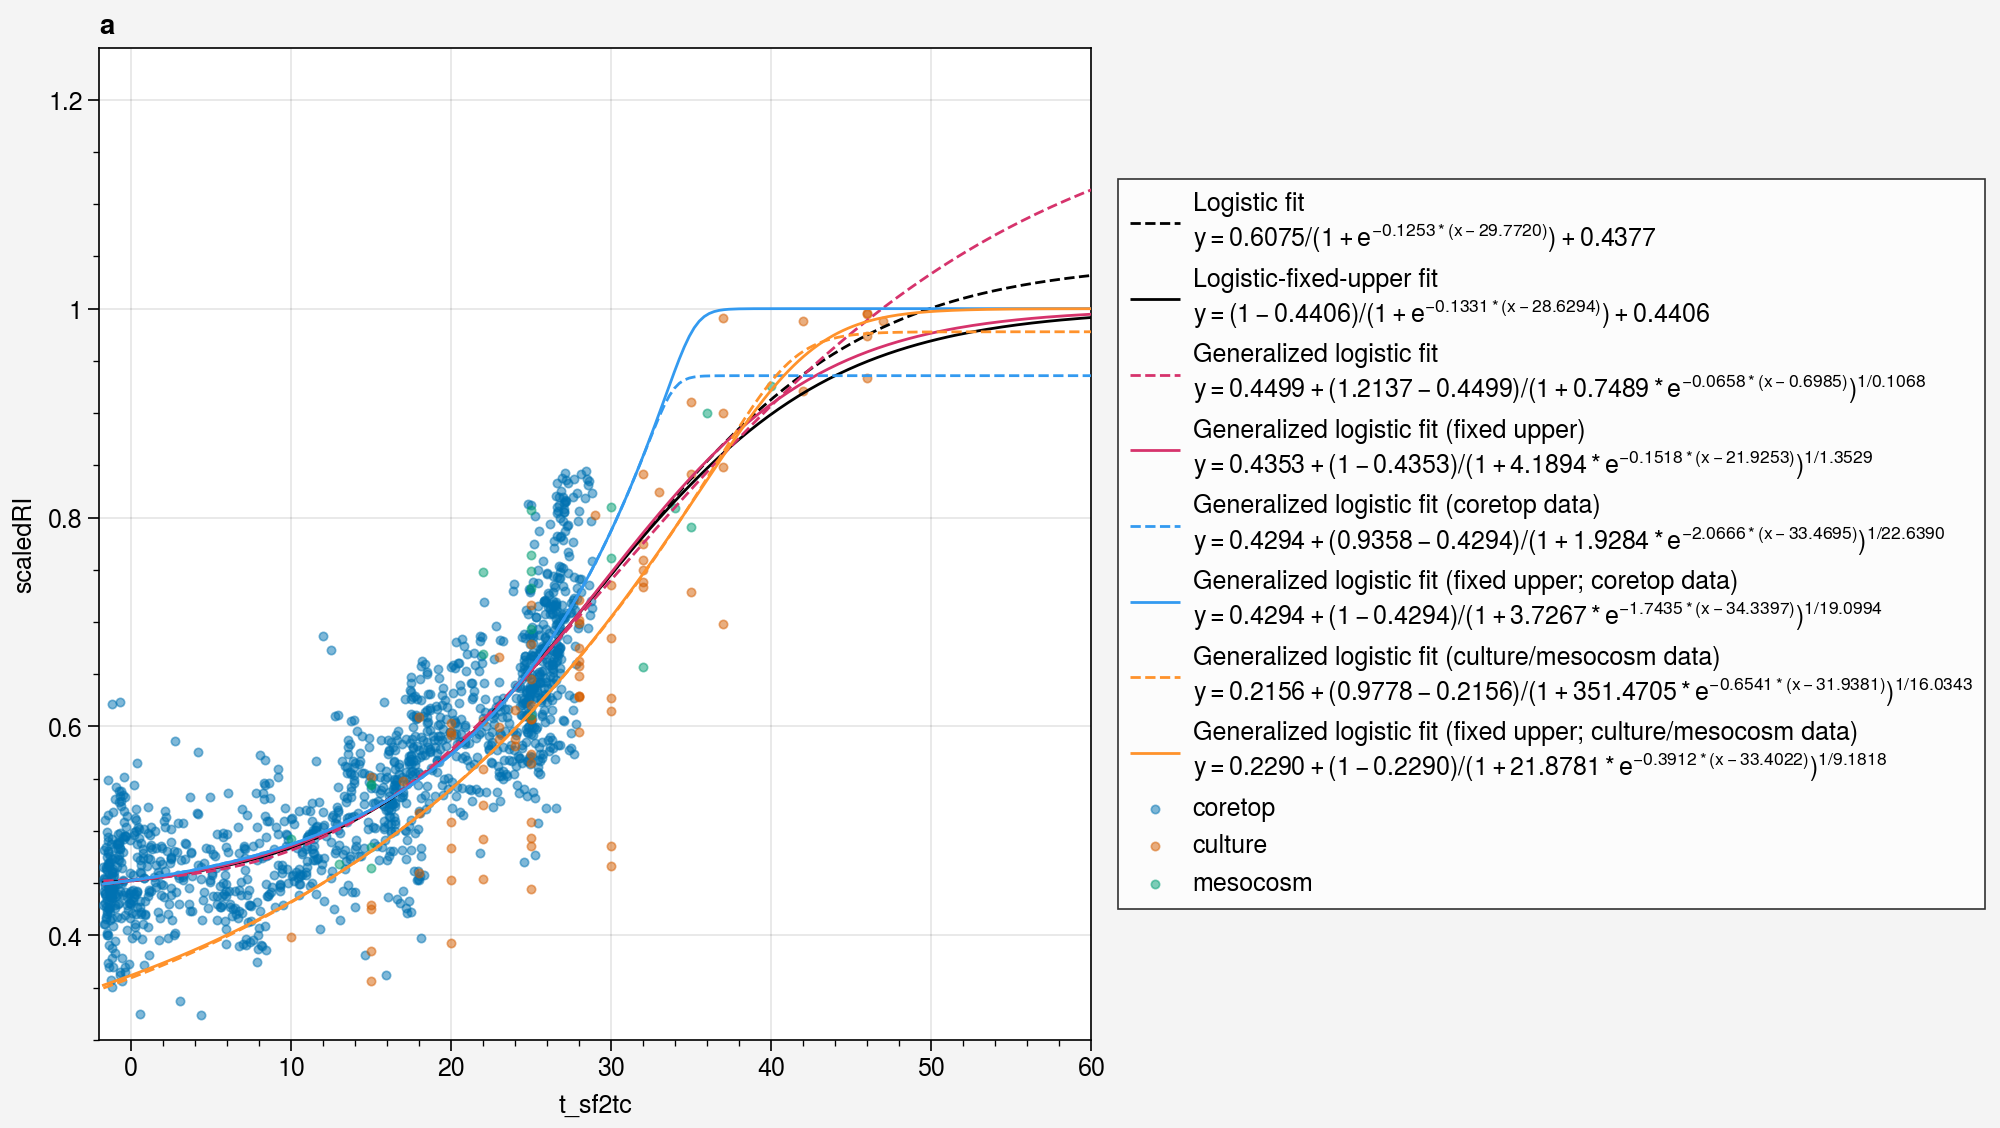

In [32]:
fig, axs = plot.subplots(width=10)

grouped = combined_df.groupby('datatype')
for name, group in grouped:
    ax = axs[0]
    ax.scatter(group['t_sf2tc'], group['scaledRI'], label=name, 
               m='.',alpha=0.5,zorder=3)

nonnan_idx = combined_df['t_sf2tc'].notna() & combined_df['scaledRI'].notna()
sel_X = combined_df['t_sf2tc'][nonnan_idx].values
sel_Y = combined_df['scaledRI'][nonnan_idx].values
XX = np.linspace(sel_X.min(), 60, 200)

### use logistic function for curve fitting
popt, pcov = curve_fit(
    logistic,
    sel_X, sel_Y,
    bounds=(0, [np.inf, np.inf, np.inf, np.inf]))
fitted_x0 = popt[0]
fitted_k = popt[1]
fitted_L = popt[2]
fitted_b = popt[3]
axs[0].plot(XX, logistic(XX, *popt), 
            color='k', lw=1, ls='--',
            label=f'Logistic fit\n$y = {fitted_L:.4f} / (1 + e^{{-{fitted_k:.4f} * (x - {fitted_x0:.4f})}}) + {fitted_b:.4f}$',
            zorder=4)

## define inflection point with differential
def plot_inflection_point(ax, x_vals, y_vals,sel_color='k',sel_linestyle='--'):
    """Plot the inflection point on the given axis."""
    # Compute numerical first and second derivatives
    dy_dx = np.gradient(y_vals, x_vals)
    d2y_dx2 = np.gradient(dy_dx, x_vals)

    # Find zero crossing in second derivative
    sign_change = np.where(np.diff(np.sign(d2y_dx2)))[0]
    
    # Get estimated inflection x value
    if sign_change.size > 0:
        inflection_idx = sign_change[0]
        inflection_x = x_vals[inflection_idx]
        ax.axvline(inflection_x, color=sel_color, ls=sel_linestyle, lw=1,)
        return inflection_x
    else:
        print("No inflection point found")
        return None

# inflection_x = plot_inflection_point(axs[0], XX, logistic(XX, *popt),
#                                     sel_color='pink7', sel_linestyle=':')

### use logistic_fixed_upper function for curve fitting
popt_fixed, pcov_fixed = curve_fit(
    logistic_fixed_upper,
    sel_X,sel_Y,
    bounds=(0, [np.inf, np.inf, np.inf]))
fitted_x0_fixed = popt_fixed[0]
fitted_k_fixed = popt_fixed[1]
fitted_b_fixed = popt_fixed[2]
axs[0].plot(XX, logistic_fixed_upper(XX, *popt_fixed), 
            color='k', lw=1, 
            label=f'Logistic-fixed-upper fit\n$y = (1-{fitted_b_fixed:.4f}) / (1 + e^{{-{fitted_k_fixed:.4f} * (x - {fitted_x0_fixed:.4f})}}) + {fitted_b_fixed:.4f}$',
            zorder=4)

# inflection_x_fixed = plot_inflection_point(axs[0], XX, logistic_fixed_upper(XX, *popt_fixed),
#                                              sel_color='k', sel_linestyle=':')



### use the generalized logistic function for curve fitting
popt_gen, pcov_gen = curve_fit(
    generalized_logistic_model,
    sel_X, sel_Y,
    bounds=(0, [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]))
fitted_x0_gen = popt_gen[0]
fitted_a_gen = popt_gen[1]
fitted_b_gen = popt_gen[2]
fitted_k_gen = popt_gen[3]
fitted_v_gen = popt_gen[4]
fitted_Q_gen = popt_gen[5]
axs[0].plot(XX, generalized_logistic_model(XX, *popt_gen), 
            color='pink7', lw=1, ls='--',
            label=f'Generalized logistic fit\n$y = {fitted_b_gen:.4f} + ({fitted_a_gen:.4f} - {fitted_b_gen:.4f}) / (1 + {fitted_Q_gen:.4f} * e^{{-{fitted_k_gen:.4f} * (x - {fitted_x0_gen:.4f})}})^{{1/{fitted_v_gen:.4f}}}$',
            zorder=4)

# inflection_x_gen = plot_inflection_point(axs[0], XX, generalized_logistic_model(XX, *popt_gen),
#                                          sel_color='gray5', sel_linestyle=':')

### use the generalized logistic function with fixed upper limit for curve fitting by setting K = 1

popt_gen_fixed, pcov_gen_fixed = curve_fit(
    generalized_logistic_model_fixed_upper,
    sel_X, sel_Y,
    bounds=(0, [np.inf, np.inf, np.inf, np.inf, np.inf]))
fitted_x0_gen_fixed = popt_gen_fixed[0]
fitted_b_gen_fixed = popt_gen_fixed[1]
fitted_k_gen_fixed = popt_gen_fixed[2]
fitted_v_gen_fixed = popt_gen_fixed[3]
fitted_Q_gen_fixed = popt_gen_fixed[4]
axs[0].plot(XX, generalized_logistic_model_fixed_upper(XX, *popt_gen_fixed), 
            color='pink7', lw=1, 
            label=f'Generalized logistic fit (fixed upper)\n$y = {fitted_b_gen_fixed:.4f} + (1 - {fitted_b_gen_fixed:.4f}) / (1 + {fitted_Q_gen_fixed:.4f} * e^{{-{fitted_k_gen_fixed:.4f} * (x - {fitted_x0_gen_fixed:.4f})}})^{{1/{fitted_v_gen_fixed:.4f}}}$',
            zorder=4)

# inflection_x_gen_fixed = plot_inflection_point(axs[0], XX, generalized_logistic_model_fixed_upper(XX, *popt_gen_fixed),
#                                                sel_color='teal5', sel_linestyle=':')

#### fit data with coretop data only

coretop_data = combined_df[combined_df['datatype'] == 'coretop']
coretop_X = coretop_data['t_sf2tc']
coretop_Y = coretop_data['scaledRI']
coretop_nonnan_idx = coretop_X.notna() & coretop_Y.notna()
coretop_sel_X = coretop_X[coretop_nonnan_idx].values
coretop_sel_Y = coretop_Y[coretop_nonnan_idx].values   

### fit with generalized logistic function
popt_gen_coretop, pcov_gen_coretop = curve_fit(
    generalized_logistic_model,
    coretop_sel_X, coretop_sel_Y,
    bounds=([10, 0, 0, 0, 0, 0],
            [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]))
fitted_x0_gen_coretop = popt_gen_coretop[0]
fitted_a_gen_coretop = popt_gen_coretop[1]
fitted_b_gen_coretop = popt_gen_coretop[2]
fitted_k_gen_coretop = popt_gen_coretop[3]
fitted_v_gen_coretop = popt_gen_coretop[4]
fitted_Q_gen_coretop = popt_gen_coretop[5]
axs[0].plot(XX, generalized_logistic_model(XX, *popt_gen_coretop), 
            color='blue5', lw=1, ls='--',
            label=f'Generalized logistic fit (coretop data)\n$y = {fitted_b_gen_coretop:.4f} + ({fitted_a_gen_coretop:.4f} - {fitted_b_gen_coretop:.4f}) / (1 + {fitted_Q_gen_coretop:.4f} * e^{{-{fitted_k_gen_coretop:.4f} * (x - {fitted_x0_gen_coretop:.4f})}})^{{1/{fitted_v_gen_coretop:.4f}}}$',
            zorder=4)
# inflection_x_gen_coretop = plot_inflection_point(axs[0], XX, generalized_logistic_model(XX, *popt_gen_coretop),
#                                                  sel_color='blue5', sel_linestyle=':')

### fit with generalized logistic function with fixed upper limit 
popt_gen_fixed_coretop, pcov_gen_fixed_coretop = curve_fit(
    generalized_logistic_model_fixed_upper,
    coretop_sel_X, coretop_sel_Y,
    bounds=([10, 0, 0, 0, 0,], 
            [np.inf, np.inf, np.inf, np.inf, np.inf]))
fitted_x0_gen_fixed_coretop = popt_gen_fixed_coretop[0]
fitted_b_gen_fixed_coretop = popt_gen_fixed_coretop[1]
fitted_k_gen_fixed_coretop = popt_gen_fixed_coretop[2]
fitted_v_gen_fixed_coretop = popt_gen_fixed_coretop[3]
fitted_Q_gen_fixed_coretop = popt_gen_fixed_coretop[4]
axs[0].plot(XX, generalized_logistic_model_fixed_upper(XX, *popt_gen_fixed_coretop), 
            color='blue5', lw=1, 
            label=f'Generalized logistic fit (fixed upper; coretop data)\n$y = {fitted_b_gen_fixed_coretop:.4f} + (1 - {fitted_b_gen_fixed_coretop:.4f}) / (1 + {fitted_Q_gen_fixed_coretop:.4f} * e^{{-{fitted_k_gen_fixed_coretop:.4f} * (x - {fitted_x0_gen_fixed_coretop:.4f})}})^{{1/{fitted_v_gen_fixed_coretop:.4f}}}$',
            zorder=4)
# inflection_x_gen_fixed_coretop = plot_inflection_point(axs[0], XX, generalized_logistic_model_fixed_upper(XX, *popt_gen_fixed_coretop),
#                                                      sel_color='blue5', sel_linestyle=':')

## fit culture and mesocosm data only
culture_mesocosm_data = combined_df[combined_df['datatype'].isin(['culture', 'mesocosm'])]
culture_mesocosm_X = culture_mesocosm_data['t_sf2tc']
culture_mesocosm_Y = culture_mesocosm_data['scaledRI']
culture_mesocosm_nonnan_idx = culture_mesocosm_X.notna() & culture_mesocosm_Y.notna()
culture_mesocosm_sel_X = culture_mesocosm_X[culture_mesocosm_nonnan_idx].values
culture_mesocosm_sel_Y = culture_mesocosm_Y[culture_mesocosm_nonnan_idx].values

### fit with generalized logistic function
popt_gen_culture_mesocosm, pcov_gen_culture_mesocosm = curve_fit(
    generalized_logistic_model,
    culture_mesocosm_sel_X, culture_mesocosm_sel_Y,
    bounds=([10, 0, 0, 0, 0, 0],
            [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]))
fitted_x0_gen_culture_mesocosm = popt_gen_culture_mesocosm[0]
fitted_a_gen_culture_mesocosm = popt_gen_culture_mesocosm[1]
fitted_b_gen_culture_mesocosm = popt_gen_culture_mesocosm[2]
fitted_k_gen_culture_mesocosm = popt_gen_culture_mesocosm[3]
fitted_v_gen_culture_mesocosm = popt_gen_culture_mesocosm[4]
fitted_Q_gen_culture_mesocosm = popt_gen_culture_mesocosm[5]
axs[0].plot(XX, generalized_logistic_model(XX, *popt_gen_culture_mesocosm), 
            color='orange5', lw=1, ls='--',
            label=f'Generalized logistic fit (culture/mesocosm data)\n$y = {fitted_b_gen_culture_mesocosm:.4f} + ({fitted_a_gen_culture_mesocosm:.4f} - {fitted_b_gen_culture_mesocosm:.4f}) / (1 + {fitted_Q_gen_culture_mesocosm:.4f} * e^{{-{fitted_k_gen_culture_mesocosm:.4f} * (x - {fitted_x0_gen_culture_mesocosm:.4f})}})^{{1/{fitted_v_gen_culture_mesocosm:.4f}}}$',
            zorder=4)

### fit with generalized logistic function with fixed upper limit
popt_gen_fixed_culture_mesocosm, pcov_gen_fixed_culture_mesocosm = curve_fit(
    generalized_logistic_model_fixed_upper,
    culture_mesocosm_sel_X, culture_mesocosm_sel_Y,
    bounds=([10, 0, 0, 0, 0],
            [np.inf, np.inf, np.inf, np.inf, np.inf]))
fitted_x0_gen_fixed_culture_mesocosm = popt_gen_fixed_culture_mesocosm[0]
fitted_b_gen_fixed_culture_mesocosm = popt_gen_fixed_culture_mesocosm[1]
fitted_k_gen_fixed_culture_mesocosm = popt_gen_fixed_culture_mesocosm[2]
fitted_v_gen_fixed_culture_mesocosm = popt_gen_fixed_culture_mesocosm[3]
fitted_Q_gen_fixed_culture_mesocosm = popt_gen_fixed_culture_mesocosm[4]
axs[0].plot(XX, generalized_logistic_model_fixed_upper(XX, *popt_gen_fixed_culture_mesocosm), 
            color='orange5', lw=1, 
            label=f'Generalized logistic fit (fixed upper; culture/mesocosm data)\n$y = {fitted_b_gen_fixed_culture_mesocosm:.4f} + (1 - {fitted_b_gen_fixed_culture_mesocosm:.4f}) / (1 + {fitted_Q_gen_fixed_culture_mesocosm:.4f} * e^{{-{fitted_k_gen_fixed_culture_mesocosm:.4f} * (x - {fitted_x0_gen_fixed_culture_mesocosm:.4f})}})^{{1/{fitted_v_gen_fixed_culture_mesocosm:.4f}}}$',
            zorder=4)


axs.format(
    xlim=(-2,60),
    ylim=(0.3,1.25)
)

# print(f'Inflection point (logistic): {inflection_x:.4f}')
# print(f'Inflection point (logistic-fixed-upper): {inflection_x_fixed:.4f}')
# print(f'Inflection point (generalized logistic): {inflection_x_gen:.4f}')
# print(f'Inflection point (generalized logistic-fixed-upper): {inflection_x_gen_fixed:.4f}')

ax.legend(loc='r',ncols=1)

# Calibration posteriors

## 1. Models with only culture-mesocosm data

In [33]:
# 2) Build your data dict exactly as before
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
}

stan_file_name = "gen_logi_free_culmeso"

# 3a) Functional style
gen_logi_free_cul_meso_post_ds, diag = get_posterior(
    data=data,
    stan_file=stan_file_name,
    temptype="cultureT",
    chains=4,
    iter_warmup=500,
    iter_sampling=1000,
)


display(gen_logi_free_cul_meso_post_ds)
# 4) Persist the result
save_posterior(gen_logi_free_cul_meso_post_ds)


15:18:26 - cmdstanpy - INFO - compiling stan file /home/rrattan/Documents/GitHub/TEXAS/TEXAS/stan_models/gen_logi_free_culmeso.stan to exe file /home/rrattan/Documents/GitHub/TEXAS/TEXAS/stan_models/gen_logi_free_culmeso


🔧 Compiling Stan model: gen_logi_free_culmeso.stan


15:18:36 - cmdstanpy - INFO - compiled model executable: /home/rrattan/Documents/GitHub/TEXAS/TEXAS/stan_models/gen_logi_free_culmeso
15:18:36 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: gen_logi_free_culmeso.stan


chain 1 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

15:18:37 - cmdstanpy - INFO - CmdStan done processing.
15:18:37 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Location parameter[1] is -nan, but must be finite! (in 'gen_logi_free_culmeso.stan', line 42, column 2 to column 62)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_free_culmeso.stan', line 42, column 2 to column 62)
	Exception: beta_lpdf: Random variable is 1.03862, but must be in the interval [0, 1] (in 'gen_logi_free_culmeso.stan', line 30, column 2 to column 30)
Exception: normal_lpdf: Location parameter[1] is inf, but must be finite! (in 'gen_logi_free_culmeso.stan', line 42, column 2 to column 62)
	Exception: beta_lpdf: Random variable is 25.6258, but must be in the interval [0, 1] (in 'gen_logi_free_culmeso.stan', line 30, column 2 to column 30)
	Exception: beta_lpdf: Random variable is 1.49393, but must be in the interval [0, 1] (in 'gen_logi_free_culmeso.stan', line 30, column 2 to column 30)
Excepti

<xarray.Dataset> Size: 352kB
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 32kB 0 1 2 3 4 ... 3996 3997 3998 3999
Data variables:
    t0_culmeso              (draw) float64 32kB 38.1 31.4 30.48 ... 33.19 33.18
    k_culmeso               (draw) float64 32kB 0.6758 0.4784 ... 0.2788 0.2892
    Q_culmeso               (draw) float64 32kB 3.851 68.31 23.78 ... 6.28 21.7
    v_culmeso               (draw) float64 32kB 11.23 13.5 7.843 ... 7.706 9.804
    b_culmeso               (draw) float64 32kB 0.3482 0.09395 ... 0.04271
    a_culmeso               (draw) float64 32kB 0.9784 0.9813 ... 0.9877 1.043
    sigma_scaledRI_cul      (draw) float64 32kB 0.07717 0.078 ... 0.08156
    sigma_scaledRI_meso     (draw) float64 32kB 0.08863 0.09998 ... 0.1025
    sigma_scaledRI_culmeso  (draw) float64 32kB 0.07971 0.0831 ... 0.08638
    inflection_point        (draw) float64 32kB 41.68 36.84 35.2 ... 40.51 41.08
Attributes: (12/33)
    stan_model_name:              gen_logi_free_culmeso
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    run_time:                     2025-08-04T15:18:37.804257
    run_duration (sec):           1.61
    temptype:                     cultureT
    ...                           ...
    stan_diag_max_rhat:           1.00525
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       952.021
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/rrattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/gen_logi_free_culmeso_cultureT.nc


PosixPath('/home/rrattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/gen_logi_free_culmeso_cultureT.nc')

In [33]:

# Save data for Stan
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,

}

stan_file_name = 'gen_logi_fixed_culmeso'
gen_logi_fixed_cul_meso_post_ds, diag = get_posterior(data=data, 
                                        stan_file=stan_file_name,
                                        temptype='cultureT')


# Save posteriors
save_posterior(gen_logi_fixed_cul_meso_post_ds)

07:39:20 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/gen_logi_fixed_culmeso.stan to exe file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/gen_logi_fixed_culmeso


🔧 Compiling Stan model: gen_logi_fixed_culmeso.stan


07:39:26 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/gen_logi_fixed_culmeso
07:39:26 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: gen_logi_fixed_culmeso.stan


chain 1 |          | 00:00 Status

...

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

07:39:26 - cmdstanpy - INFO - CmdStan done processing.
07:39:26 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: beta_lpdf: Random variable is 1.2853, but must be in the interval [0, 1] (in 'gen_logi_fixed_culmeso.stan', line 29, column 2 to column 30)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_culmeso.stan', line 40, column 2 to column 62)
	Exception: normal_lpdf: Location parameter[1] is -nan, but must be finite! (in 'gen_logi_fixed_culmeso.stan', line 40, column 2 to column 62)
Exception: beta_lpdf: Random variable is 4.84977, but must be in the interval [0, 1] (in 'gen_logi_fixed_culmeso.stan', line 29, column 2 to column 30)
Exception: beta_lpdf: Random variable is 1.81471, but must be in the interval [0, 1] (in 'gen_logi_fixed_culmeso.stan', line 29, column 2 to column 30)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_culmeso.stan', line 40, column 2 to column 62)
	Exceptio


Saved forward posterior to /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/gen_logi_fixed_culmeso_cultureT.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/gen_logi_fixed_culmeso_cultureT.nc')

In [34]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()

# Save data for Stan
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
}

stan_file_name = 'jnt_cul_meso'
jnt_cul_meso_post_ds, diag = get_posterior(data=data, 
                                    stan_file=stan_file_name,
                                    temptype='cultureT')


# Save posteriors
save_posterior(jnt_cul_meso_post_ds)

07:39:26 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/jnt_cul_meso.stan to exe file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/jnt_cul_meso


🔧 Compiling Stan model: jnt_cul_meso.stan


07:39:31 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/jnt_cul_meso
07:39:31 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: jnt_cul_meso.stan


chain 1 |          | 00:00 Status

...

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

07:39:32 - cmdstanpy - INFO - CmdStan done processing.
07:39:32 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: beta_lpdf: Random variable is 3.99313, but must be in the interval [0, 1] (in 'jnt_cul_meso.stan', line 28, column 2 to column 29)
	Exception: beta_lpdf: Random variable is 1.20948, but must be in the interval [0, 1] (in 'jnt_cul_meso.stan', line 28, column 2 to column 29)
	Exception: beta_lpdf: Random variable is 234.467, but must be in the interval [0, 1] (in 'jnt_cul_meso.stan', line 28, column 2 to column 29)
	Exception: beta_lpdf: Random variable is 1.03503, but must be in the interval [0, 1] (in 'jnt_cul_meso.stan', line 28, column 2 to column 29)
	Exception: beta_lpdf: Random variable is 2.42449, but must be in the interval [0, 1] (in 'jnt_cul_meso.stan', line 28, column 2 to column 29)
	Exception: beta_lpdf: Random variable is 2.1373, but must be in the interval [0, 1] (in 'jnt_cul_meso.stan', line 28, column 2 to column 29)
	Exception: beta_lpdf: 


Saved forward posterior to /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/jnt_cul_meso_cultureT.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/jnt_cul_meso_cultureT.nc')

In [35]:
# Create x-axis (temperature or predictor) values
x_vals = np.linspace(0, 100, 500)

## CASE 1: Generalized logistic model with free upper limit
# Sample 500 draws from posterior
post_ds = gen_logi_free_cul_meso_post_ds
n_draws = 500
posterior_df = post_ds[['t0_culmeso', 'a_culmeso', 'b_culmeso', 'k_culmeso', 'v_culmeso', 'Q_culmeso']].to_dataframe().reset_index()
sampled_draws = posterior_df.sample(n=n_draws, replace=False, random_state=42).reset_index(drop=True)

ensemble = np.zeros((n_draws, len(x_vals)))

for i in range(n_draws):
    row = sampled_draws.loc[i]
    ensemble[i, :] = generalized_logistic_model(
        x_vals,
        x0=row['t0_culmeso'],
        a=row['a_culmeso'],
        b=row['b_culmeso'],
        k=row['k_culmeso'],
        v=row['v_culmeso'],
        Q=row['Q_culmeso']
    )
##
lower_bound_free = np.percentile(ensemble, 5, axis=0)
upper_bound_free = np.percentile(ensemble, 95, axis=0)
median_curve_free = np.percentile(ensemble, 50, axis=0)


## CASE 2: Generalized logistic model with fixed upper limit
# Sample 500 draws from posterior
post_ds = gen_logi_fixed_cul_meso_post_ds
n_draws = 500
posterior_df = post_ds[['t0_culmeso', 'b_culmeso', 'k_culmeso', 'v_culmeso', 'Q_culmeso']].to_dataframe().reset_index()
sampled_draws = posterior_df.sample(n=n_draws, replace=False, random_state=42).reset_index(drop=True)



# Initialize matrix for storing ensemble predictions
ensemble = np.zeros((n_draws, len(x_vals)))

# Evaluate the S-curve for each draw
for i in range(n_draws):
    row = sampled_draws.loc[i]
    ensemble[i, :] = generalized_logistic_model_fixed_upper(
        x_vals,
        x0=row['t0_culmeso'],
        b=row['b_culmeso'],
        k=row['k_culmeso'],
        v=row['v_culmeso'],
        Q=row['Q_culmeso']
    )
    
# Compute percentiles
lower_bound = np.percentile(ensemble, 5, axis=0)
upper_bound = np.percentile(ensemble, 95, axis=0)
median_curve = np.percentile(ensemble, 50, axis=0)

## CASE 3: Joint model with fixed upper limit
### jnt_cul_meso_post_ds
post_ds_jnt = jnt_cul_meso_post_ds
n_draws_jnt = 500
posterior_df_jnt = post_ds_jnt[['t0_culmeso','k_culmeso','b_culmeso']].to_dataframe().reset_index()
sampled_draws_jnt = posterior_df_jnt.sample(n=n_draws_jnt, replace=False, random_state=42).reset_index(drop=True)

# Initialize matrix for storing ensemble predictions
ensemble_jnt = np.zeros((n_draws_jnt, len(x_vals)))

# Evaluate the S-curve for each draw
for i in range(n_draws_jnt):
    row = sampled_draws_jnt.loc[i]
    ensemble_jnt[i, :] = logistic_fixed_upper(
        x_vals,
        x0=row['t0_culmeso'],
        k=row['k_culmeso'],
        b=row['b_culmeso']
    )

# Compute percentiles
lower_bound_jnt = np.percentile(ensemble_jnt, 5, axis=0)
upper_bound_jnt = np.percentile(ensemble_jnt, 95, axis=0)
median_curve_jnt = np.percentile(ensemble_jnt, 50, axis=0)


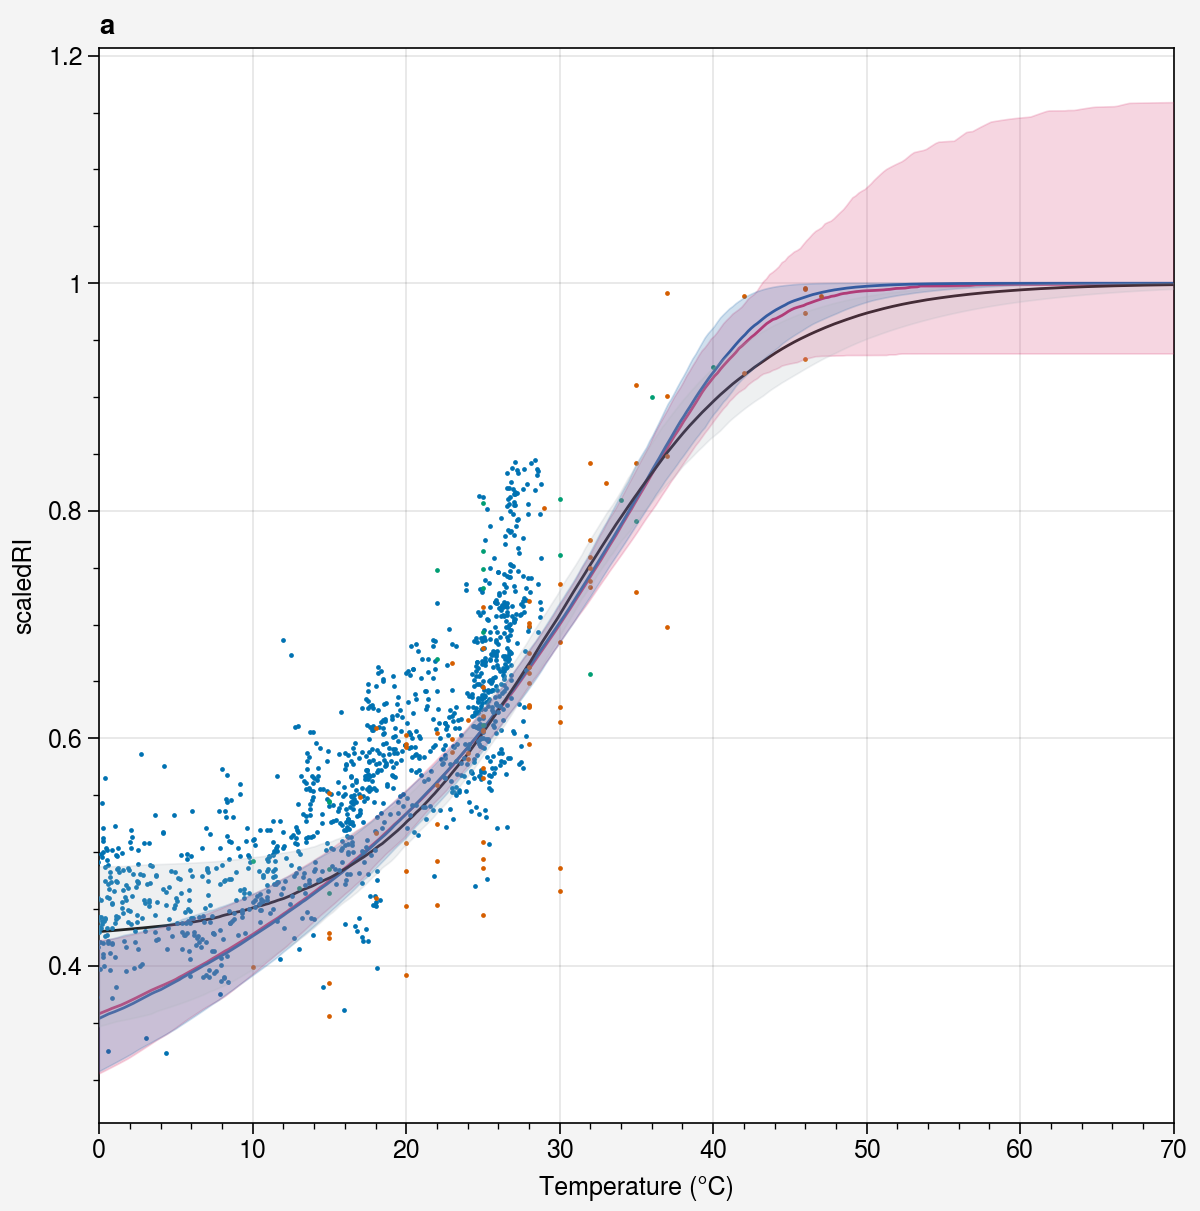

In [36]:

# Plot
fig, axs = plot.subplots(width=6)

axs[0].plot(x_vals, median_curve_free, color='pink7', lw=1, label='Fitted model (free upper limit)')
axs[0].fill_between(x_vals, lower_bound_free, upper_bound_free,
                   color='pink7', alpha=0.2, label='95% CI (free upper limit)',
                   zorder=5)

axs[0].plot(x_vals, median_curve, color='blue9', lw=1, label='Fitted model')
axs[0].fill_between(x_vals, lower_bound, upper_bound, 
                   color='blue9', alpha=0.2, label='95% CI',
                   zorder=5)

axs[0].plot(x_vals, median_curve_jnt, color='k', lw=1, label='Joint model')
axs[0].fill_between(x_vals, lower_bound_jnt, upper_bound_jnt, 
                   color='gray5', alpha=0.2, label='95% CI (joint model)',
                   zorder=5)
axs[0].set_xlabel('Temperature (°C)')

grouped = combined_df.groupby('datatype')
for name, group in grouped:
    axs[0].scatter(group['t_sf2tc'], group['scaledRI'], label=name, 
                   m='.', s=5, zorder=3)
axs.format(
    xlim=(0,70)
)

## 2. Models with coretop data

### 2.1 hier_crtp | prior approximation

In [37]:
# Drop NaNs from coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

# Get posterior-based priors from generalized logistic fit
prior_mean_t0 = gen_logi_fixed_cul_meso_post_ds['t0_culmeso'].mean(dim="draw").item()
prior_sd_t0 = gen_logi_fixed_cul_meso_post_ds['t0_culmeso'].std(dim="draw").item()

prior_mean_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].mean(dim="draw").item()
prior_sd_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].std(dim="draw").item()

prior_mean_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].mean(dim="draw").item()
prior_sd_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].std(dim="draw").item()

prior_mean_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).mean(dim="draw").item()
prior_sd_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).std(dim="draw").item()

prior_mean_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).mean(dim="draw").item()
prior_sd_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).std(dim="draw").item()

data_normal_prior = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
    "prior_mean_Q": prior_mean_Q,
    "prior_sd_Q": prior_sd_Q,
    "prior_mean_v": prior_mean_v,
    "prior_sd_v": prior_sd_v,
}

stan_file_name = 'gen_logi_fixed_hier_crtp_univ_priorApprox'
gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds, diag = get_posterior(
    data_normal_prior,
    stan_file=stan_file_name,
    temptype='thermoT'
)
save_posterior(gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds)


07:39:32 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/gen_logi_fixed_hier_crtp_univ_priorApprox.stan to exe file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/gen_logi_fixed_hier_crtp_univ_priorApprox


🔧 Compiling Stan model: gen_logi_fixed_hier_crtp_univ_priorApprox.stan


07:39:37 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/gen_logi_fixed_hier_crtp_univ_priorApprox
07:39:37 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: gen_logi_fixed_hier_crtp_univ_priorApprox.stan


chain 1 |          | 00:00 Status

...

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

07:39:46 - cmdstanpy - INFO - CmdStan done processing.
07:39:46 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_pri


Saved forward posterior to /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT.nc')

In [38]:
# Drop NaNs from coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

# Get posterior-based priors from generalized logistic fit
prior_mean_t0 = gen_logi_fixed_cul_meso_post_ds['t0_culmeso'].mean(dim="draw").item()
prior_sd_t0 = gen_logi_fixed_cul_meso_post_ds['t0_culmeso'].std(dim="draw").item()

prior_mean_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].mean(dim="draw").item()
prior_sd_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].std(dim="draw").item()

prior_mean_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].mean(dim="draw").item()
prior_sd_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].std(dim="draw").item()

prior_mean_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).mean(dim="draw").item()
prior_sd_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).std(dim="draw").item()

prior_mean_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).mean(dim="draw").item()
prior_sd_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).std(dim="draw").item()

data_normal_prior = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
    "prior_mean_Q": prior_mean_Q,
    "prior_sd_Q": prior_sd_Q,
    "prior_mean_v": prior_mean_v,
    "prior_sd_v": prior_sd_v,
}

stan_file_name = 'gen_logi_fixed_hier_crtp_univ_priorApprox'
gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds_sst, diag = get_posterior(
    data_normal_prior,
    stan_file=stan_file_name,
    temptype='sst'
)
save_posterior(gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds_sst)


07:39:47 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

07:39:58 - cmdstanpy - INFO - CmdStan done processing.
07:39:58 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_pr


Saved forward posterior to /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/gen_logi_fixed_hier_crtp_univ_priorApprox_sst.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/gen_logi_fixed_hier_crtp_univ_priorApprox_sst.nc')

In [39]:
# Drop NaNs from coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

# Get posterior-based priors from generalized logistic fit
prior_mean_t0 = gen_logi_free_cul_meso_post_ds['t0_culmeso'].mean(dim="draw").item()
prior_sd_t0 = gen_logi_free_cul_meso_post_ds['t0_culmeso'].std(dim="draw").item()

prior_mean_k = gen_logi_free_cul_meso_post_ds["k_culmeso"].mean(dim="draw").item()
prior_sd_k = gen_logi_free_cul_meso_post_ds["k_culmeso"].std(dim="draw").item()

prior_mean_b = gen_logi_free_cul_meso_post_ds["b_culmeso"].mean(dim="draw").item()
prior_sd_b = gen_logi_free_cul_meso_post_ds["b_culmeso"].std(dim="draw").item()

prior_mean_a = gen_logi_free_cul_meso_post_ds["a_culmeso"].mean(dim="draw").item()
prior_sd_a = gen_logi_free_cul_meso_post_ds["a_culmeso"].std(dim="draw").item()

prior_mean_Q = np.log(gen_logi_free_cul_meso_post_ds["Q_culmeso"]).mean(dim="draw").item()
prior_sd_Q = np.log(gen_logi_free_cul_meso_post_ds["Q_culmeso"]).std(dim="draw").item()

prior_mean_v = np.log(gen_logi_free_cul_meso_post_ds["v_culmeso"]).mean(dim="draw").item()
prior_sd_v = np.log(gen_logi_free_cul_meso_post_ds["v_culmeso"]).std(dim="draw").item()

data_normal_prior = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
    "prior_mean_a": prior_mean_a,
    "prior_sd_a": prior_sd_a,
    "prior_mean_Q": prior_mean_Q,
    "prior_sd_Q": prior_sd_Q,
    "prior_mean_v": prior_mean_v,
    "prior_sd_v": prior_sd_v,
}

stan_file_name = 'gen_logi_free_hier_crtp_univ_priorApprox'
gen_logi_free_hier_crtp_univ_prior_approx_post_ds, diag = get_posterior(
    data_normal_prior,
    stan_file=stan_file_name,
    temptype='thermoT'
)
save_posterior(gen_logi_free_hier_crtp_univ_prior_approx_post_ds)


07:39:58 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/gen_logi_free_hier_crtp_univ_priorApprox.stan to exe file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/gen_logi_free_hier_crtp_univ_priorApprox


🔧 Compiling Stan model: gen_logi_free_hier_crtp_univ_priorApprox.stan


07:40:03 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/gen_logi_free_hier_crtp_univ_priorApprox
07:40:03 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: gen_logi_free_hier_crtp_univ_priorApprox.stan


chain 1 |          | 00:00 Status

...

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

07:40:18 - cmdstanpy - INFO - CmdStan done processing.
07:40:18 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_free_hier_crtp_univ_priorApprox.stan', line 46, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_free_hier_crtp_univ_priorApprox.stan', line 46, column 2 to column 64)
	Exception: normal_lpdf: Location parameter[1] is -nan, but must be finite! (in 'gen_logi_free_hier_crtp_univ_priorApprox.stan', line 46, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_free_hier_crtp_univ_priorApprox.stan', line 46, column 2 to column 64)
Exception: normal_lpdf: Location parameter[1] is inf, but must be finite! (in 'gen_logi_free_hier_crtp_univ_priorApprox.stan', line 46, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_free_hier_crtp_u


Saved forward posterior to /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/gen_logi_free_hier_crtp_univ_priorApprox_thermoT.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/gen_logi_free_hier_crtp_univ_priorApprox_thermoT.nc')

In [40]:


# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

prior_mean_t0 = jnt_cul_meso_post_ds["t0_culmeso"].mean(dim="draw").item()
prior_sd_t0 = jnt_cul_meso_post_ds["t0_culmeso"].std(dim="draw").item()

prior_mean_k = jnt_cul_meso_post_ds["k_culmeso"].mean(dim="draw").item()
prior_sd_k = jnt_cul_meso_post_ds["k_culmeso"].std(dim="draw").item()

prior_mean_b = jnt_cul_meso_post_ds["b_culmeso"].mean(dim="draw").item()
prior_sd_b = jnt_cul_meso_post_ds["b_culmeso"].std(dim="draw").item()

data_normal_prior = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
}

stan_file_name = 'hier_crtp_univ_priorApprox'
hier_crtp_univ_prior_approx_post_ds, diag = get_posterior(data=data_normal_prior, 
                                                                 stan_file=stan_file_name,
                                                                 temptype='thermoT',)
# Save posteriors
save_posterior(hier_crtp_univ_prior_approx_post_ds)

###################################################
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

data_normal_prior = {
    "N_crtp": len(sst_crtp),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
}

stan_file_name = 'hier_crtp_univ_priorApprox'
hier_crtp_sst_univ_prior_approx_post_ds, diag = get_posterior(data=data_normal_prior, 
                                                                 stan_file=stan_file_name,
                                                                 temptype='sst',)
# Save posteriors
save_posterior(hier_crtp_sst_univ_prior_approx_post_ds)

07:40:19 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/hier_crtp_univ_priorApprox.stan to exe file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/hier_crtp_univ_priorApprox


🔧 Compiling Stan model: hier_crtp_univ_priorApprox.stan


07:40:23 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/hier_crtp_univ_priorApprox
07:40:23 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: hier_crtp_univ_priorApprox.stan


chain 1 |          | 00:00 Status

...

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

07:40:25 - cmdstanpy - INFO - CmdStan done processing.
07:40:25 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 64)
Consider re-running with show_console=True if the above output is unclear!



Saved forward posterior to /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/hier_crtp_univ_priorApprox_sst.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/hier_crtp_univ_priorApprox_sst.nc')

In [41]:
x_vals = np.linspace(0, 100, 500)

## CASE 1: Generalized logistic model with free upper limit for coretop
post_ds = gen_logi_free_hier_crtp_univ_prior_approx_post_ds
n_draws = 500
posterior_df = post_ds[['t0_crtp', 'a_crtp', 'b_crtp', 'k_crtp', 'v_crtp', 'Q_crtp']].to_dataframe().reset_index()
sampled_draws = posterior_df.sample(n=n_draws, replace=False, random_state=42).reset_index(drop=True)
ensemble_free_crtp = np.zeros((n_draws, len(x_vals)))

for i in range(n_draws):
    row = sampled_draws.loc[i]
    ensemble_free_crtp[i, :] = generalized_logistic_model(
        x_vals,
        x0=row['t0_crtp'],
        a=row['a_crtp'],
        b=row['b_crtp'],
        k=row['k_crtp'],
        v=row['v_crtp'],
        Q=row['Q_crtp']
    )
    
median_curve_free_crtp = np.percentile(ensemble_free_crtp, 50, axis=0)
lower_bound_free_crtp = np.percentile(ensemble_free_crtp, 5, axis=0)
upper_bound_free_crtp = np.percentile(ensemble_free_crtp, 95, axis=0)

## CASE 2: Generalized logistic model with fixed upper limit for coretop
### calculate "median_curve_gen_logi_crtp"
post_ds = gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds
n_draws = 500
posterior_df = post_ds[['t0_crtp','k_crtp','b_crtp','v_crtp','Q_crtp']].to_dataframe().reset_index()
sampled_draws = posterior_df.sample(n=n_draws, replace=False, random_state=42).reset_index(drop=True) 

ensemble_gen_logi_crtp = np.zeros((n_draws, len(x_vals)))

for i in range(n_draws):
    row = sampled_draws.loc[i]
    ensemble_gen_logi_crtp[i, :] = generalized_logistic_model_fixed_upper(
        x_vals,
        x0=row['t0_crtp'],
        b=row['b_crtp'],
        k=row['k_crtp'],
        v=row['v_crtp'],
        Q=row['Q_crtp']
    )

# Compute percentiles
lower_bound_gen_logi_crtp = np.percentile(ensemble_gen_logi_crtp, 5, axis=0)
upper_bound_gen_logi_crtp = np.percentile(ensemble_gen_logi_crtp, 95, axis=0)
median_curve_gen_logi_crtp = np.percentile(ensemble_gen_logi_crtp, 50, axis=0)

## CASE 3: Joint model with fixed upper limit for coretop
### hier_crtp_univ_prior_approx_post_ds
post_ds = hier_crtp_univ_prior_approx_post_ds
n_draws = 500
posterior_df = post_ds[['t0_crtp','k_crtp','b_crtp']].to_dataframe().reset_index()
sampled_draws = posterior_df.sample(n=n_draws, replace=False, random_state=42).reset_index(drop=True)

# Initialize matrix for storing ensemble predictions
ensemble_hier_crtp_priorApprox = np.zeros((n_draws, len(x_vals)))

# Evaluate the S-curve for each draw
for i in range(n_draws):
    row = sampled_draws.loc[i]
    ensemble_hier_crtp_priorApprox[i, :] = logistic_fixed_upper(
        x_vals,
        x0=row['t0_crtp'],
        k=row['k_crtp'],
        b=row['b_crtp']
    )

# Compute percentiles
lower_bound_hier_crtp_priorApprox = np.percentile(ensemble_hier_crtp_priorApprox, 5, axis=0)
upper_bound_hier_crtp_priorApprox = np.percentile(ensemble_hier_crtp_priorApprox, 95, axis=0)
median_curve_hier_crtp_priorApprox = np.percentile(ensemble_hier_crtp_priorApprox, 50, axis=0)

Grouped param names: {'t0': ['t0_crtp', 't0_culmeso'], 'k': ['k_crtp', 'k_culmeso'], 'b': ['b_culmeso', 'b_crtp'], 'v': ['v_culmeso', 'v_crtp'], 'Q': ['Q_crtp', 'Q_culmeso'], 'a': ['a_culmeso', 'a_crtp'], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Grouped param names: {'t0': ['t0_crtp', 't0_culmeso'], 'k': ['k_crtp', 'k_culmeso'], 'b': ['b_culmeso', 'b_crtp'], 'v': ['v_culmeso', 'v_crtp'], 'Q': ['Q_crtp', 'Q_culmeso'], 'a': ['a_culmeso', 'a_crtp'], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
['t0', 'k', 'b', 'v', 'Q', 'a']


(<Figure size 900x800 with 6 Axes>,
 array([[<AxesSubplot:xlabel='t0'>, <AxesSubplot:xlabel='k'>,
         <AxesSubplot:xlabel='b'>],
        [<AxesSubplot:xlabel='v'>, <AxesSubplot:xlabel='Q'>,
         <AxesSubplot:xlabel='a'>]], dtype=object))

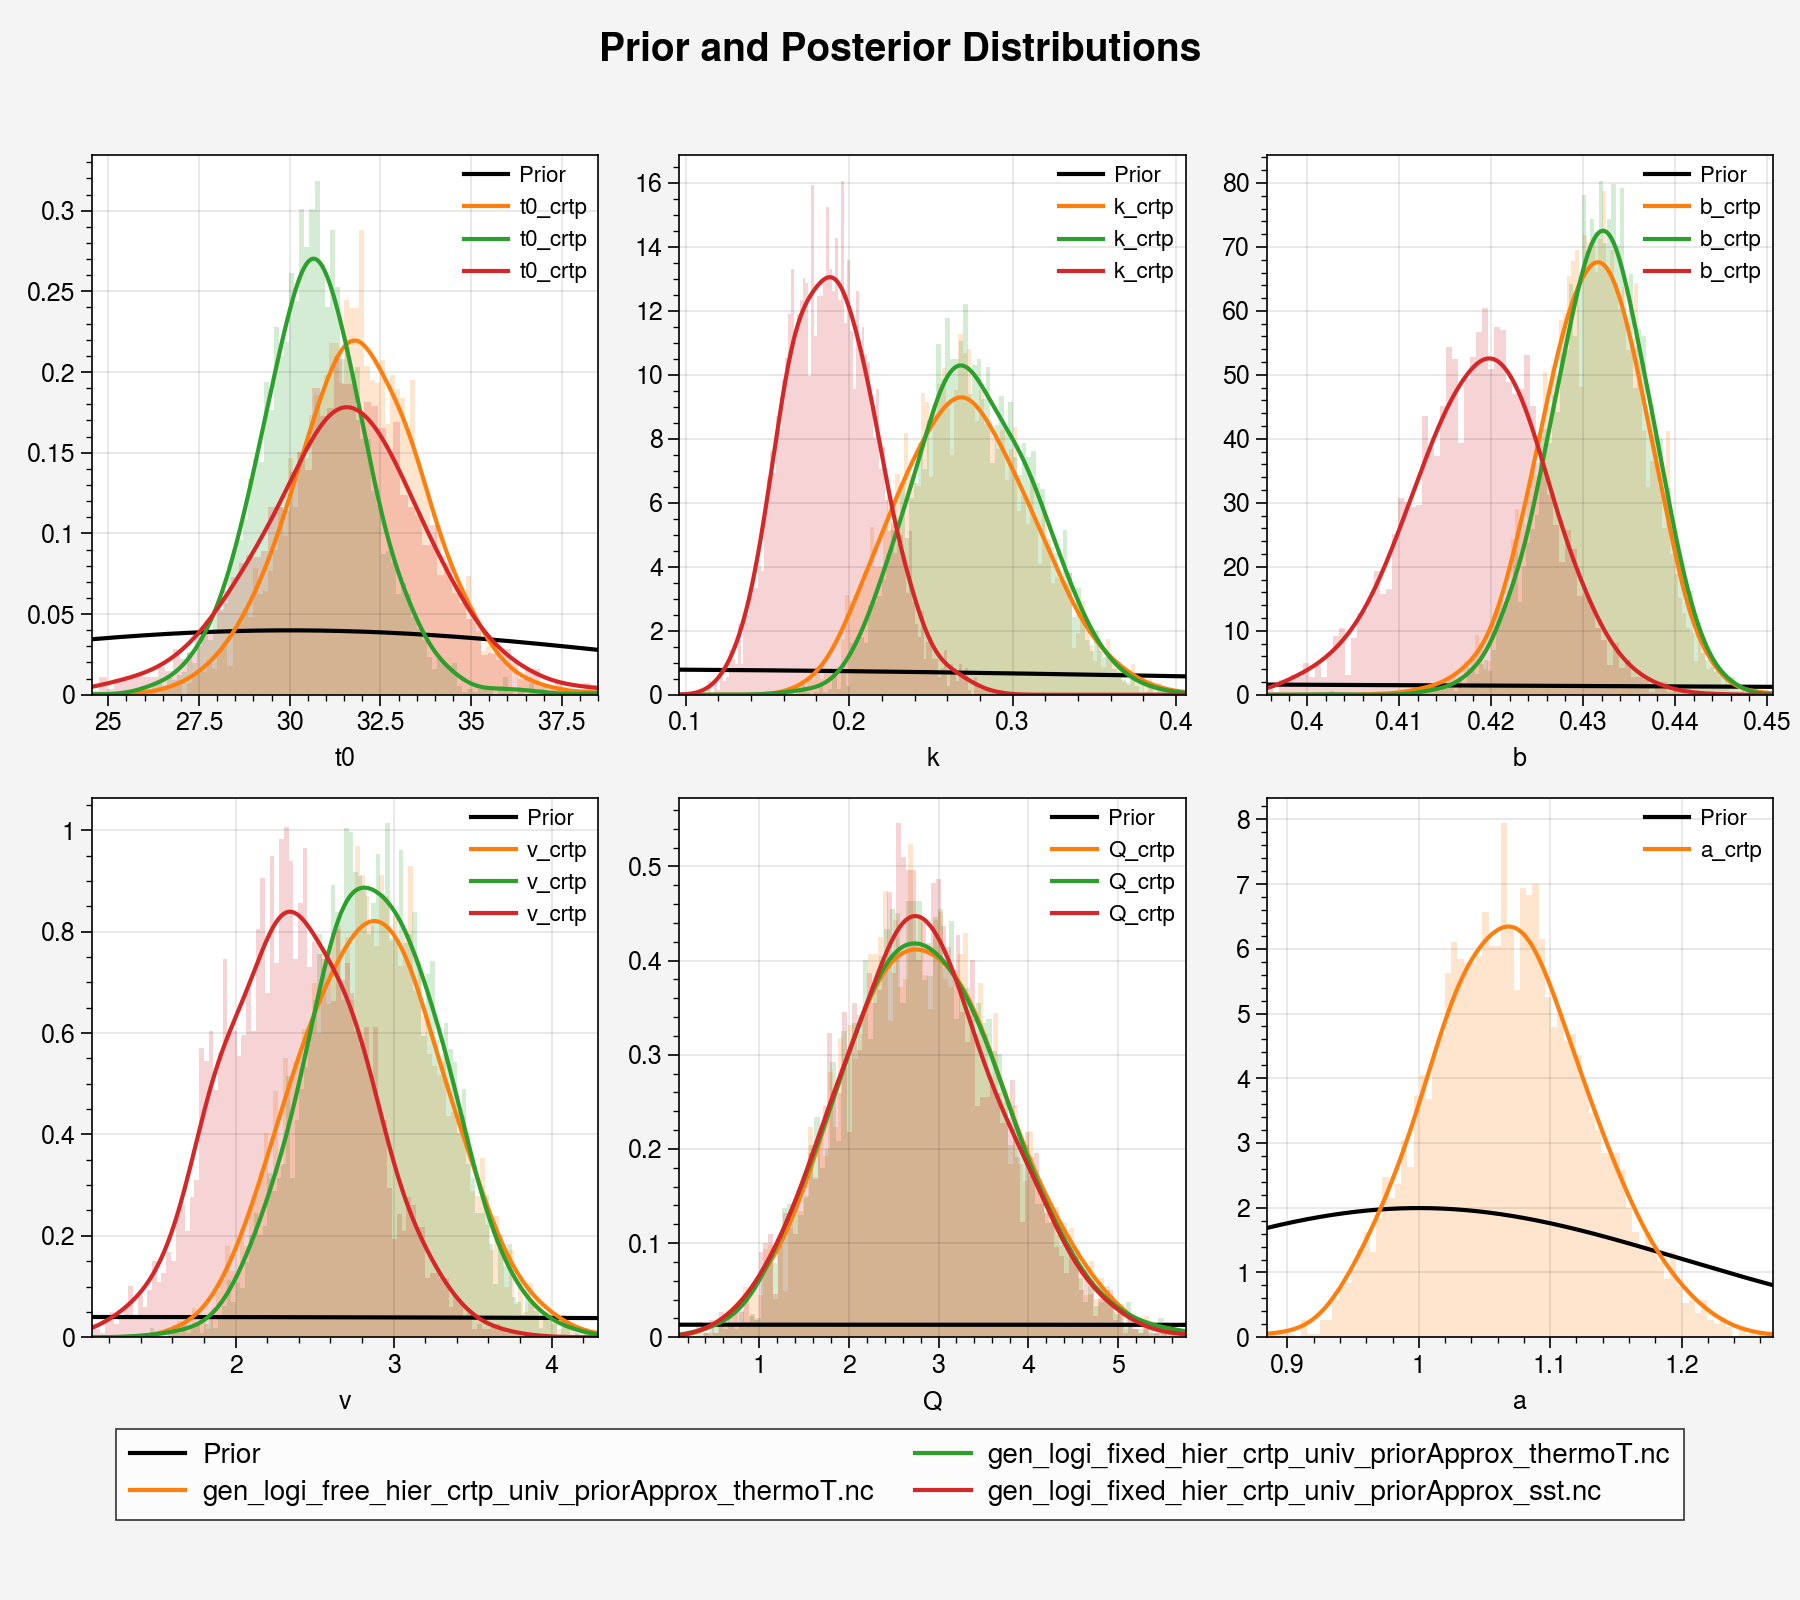

In [44]:
plot_prior_distributions(
    priors_list=gen_logi_free_cul_meso_post_ds.attrs['priors'],
    posterior_datasets=[
        gen_logi_free_cul_meso_post_ds,
        gen_logi_free_hier_crtp_univ_prior_approx_post_ds,
        gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds,
        gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds_sst,
        ],
    set_leg_max_ncol=2,
    set_fig_height_factor=4,
    suffix_include="crtp"
)

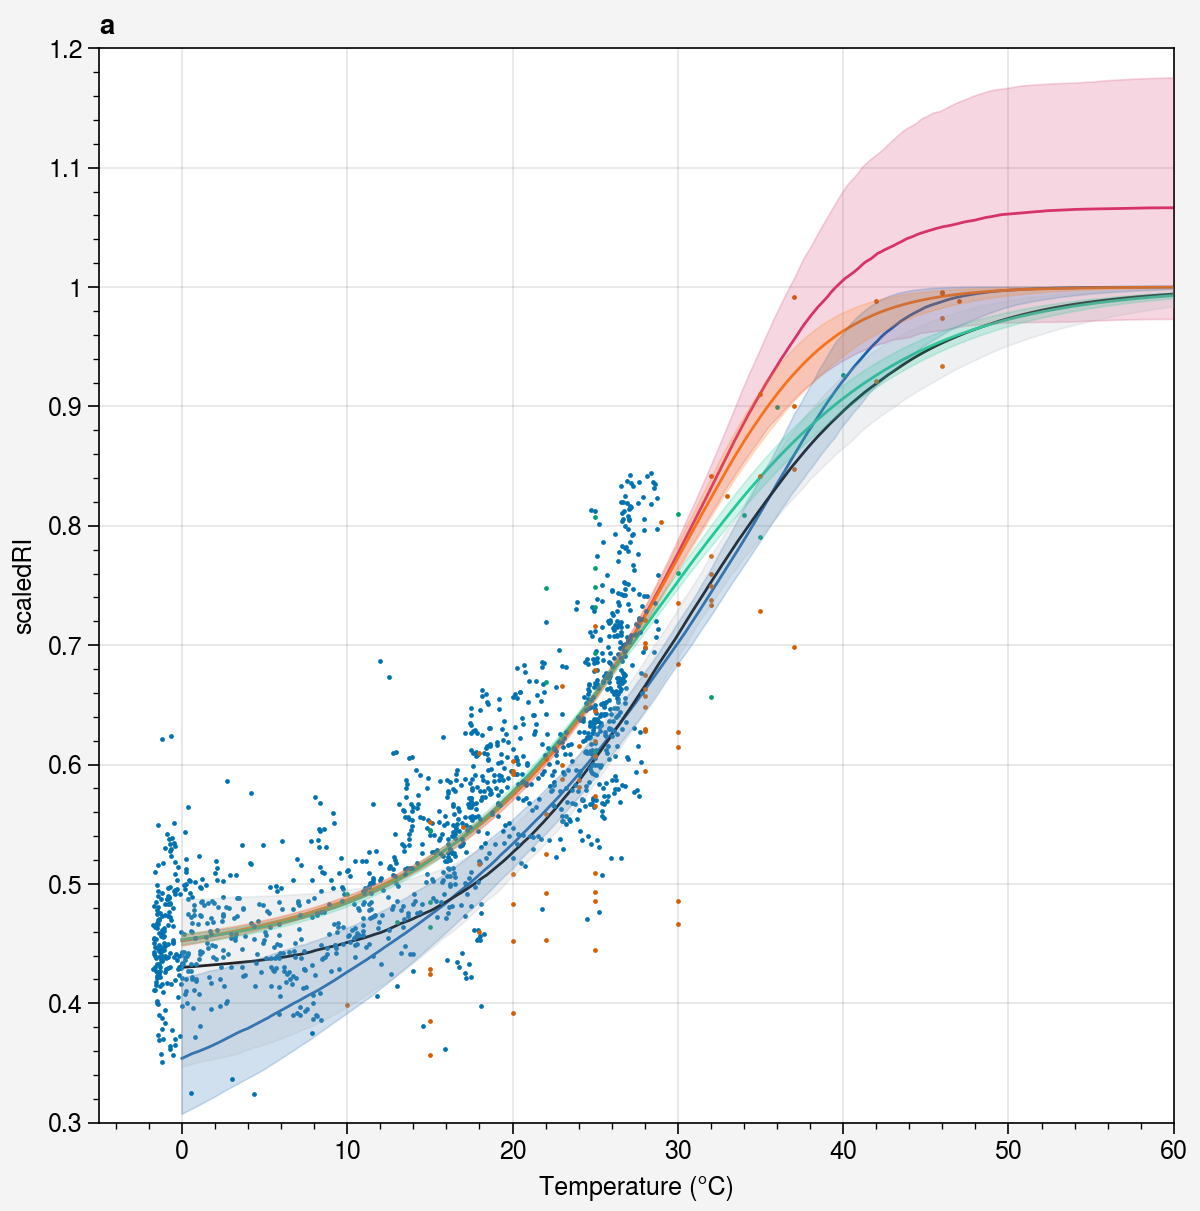

In [45]:
# Create 1000 ensemble members of S-curve from the posterior samples


# Plot
fig, axs = plot.subplots(width=6)

axs[0].plot(x_vals, median_curve_free_crtp, color='pink7', lw=1, label='Fitted model (free upper limit)')
axs[0].fill_between(x_vals, lower_bound_free_crtp, upper_bound_free_crtp,
                   color='pink7', alpha=0.2, label='95% CI (free upper limit)',
                   zorder=5)

axs[0].plot(x_vals, median_curve, color='blue9', lw=1, label='Fitted model')
axs[0].fill_between(x_vals, lower_bound, upper_bound, 
                   color='blue9', alpha=0.2, label='95% CI',
                   zorder=5)

axs[0].plot(x_vals, median_curve_jnt, color='k', lw=1, label='Joint model')
axs[0].fill_between(x_vals, lower_bound_jnt, upper_bound_jnt, 
                   color='gray5', alpha=0.2, label='95% CI (joint model)',
                   zorder=5)

axs[0].plot(x_vals, median_curve_gen_logi_crtp, color='tab:orange', lw=1, label='Hierarchical model (univariate prior approx.)')
axs[0].fill_between(x_vals, lower_bound_gen_logi_crtp, upper_bound_gen_logi_crtp, 
                   color='tab:orange', alpha=0.2, label='95% CI (hierarchical model)',
                   zorder=5)

axs[0].plot(x_vals, median_curve_hier_crtp_priorApprox, color='teal5', lw=1, label='Hierarchical model (univariate prior approx. SST)')
axs[0].fill_between(x_vals, lower_bound_hier_crtp_priorApprox, upper_bound_hier_crtp_priorApprox, 
                   color='teal5', alpha=0.2, label='95% CI (hierarchical model SST)',
                   zorder=5)

axs[0].set_xlabel('Temperature (°C)')

grouped = combined_df.groupby('datatype')
for name, group in grouped:
    axs[0].scatter(group['t_sf2tc'], group['scaledRI'], label=name, 
                   m='.', s=5, zorder=3)
    
# y_linear_schouten02 = predictTEXfromSST(x_vals, method_name='schouten02')
# y_kim10 = predictTEXfromSST(x_vals,method_name='kim2010_tex86H')

# ax = axs[0]
# ax.plot(x_vals, y_linear_schouten02, color='red9', lw=1, label='Schouten et al. (2002) linear fit')
# ax.plot(x_vals, y_kim10, color='green9', lw=1, label='Kim et al. (2010) linear fit')

axs.format(
    ylim=(0.3, 1.2),
    xlim=(-5, 60)
)

### 2.2 Fully joint cul-meso-coretop

In [46]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
}
stan_file_name = 'jnt_cul_meso_crtp'
jnt_cul_meso_crtp_post_ds, diag = get_posterior(data=data, 
                                                       stan_file=stan_file_name,
                                                       temptype='thermoT')
display(jnt_cul_meso_crtp_post_ds)

# Save posteriors
save_posterior(jnt_cul_meso_crtp_post_ds)

##########################################################
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(sst_crtp),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,
}
stan_file_name = 'jnt_cul_meso_crtp'
jnt_cul_meso_crtp_sst_post_ds, diag = get_posterior(data=data, 
                                                           stan_file=stan_file_name,
                                                           temptype='sst')
display(jnt_cul_meso_crtp_sst_post_ds)

# Save posteriors
save_posterior(jnt_cul_meso_crtp_sst_post_ds)


07:41:45 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/jnt_cul_meso_crtp.stan to exe file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/jnt_cul_meso_crtp


🔧 Compiling Stan model: jnt_cul_meso_crtp.stan


07:41:50 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/jnt_cul_meso_crtp
07:41:50 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: jnt_cul_meso_crtp.stan


chain 1 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

07:41:52 - cmdstanpy - INFO - CmdStan done processing.
07:41:52 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: beta_lpdf: Random variable is 3.99313, but must be in the interval [0, 1] (in 'jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'jnt_cul_meso_crtp.stan', line 42, column 2 to column 65)
Exception: beta_lpdf: Random variable is 3.25794, but must be in the interval [0, 1] (in 'jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
	Exception: beta_lpdf: Random variable is 1.39111, but must be in the interval [0, 1] (in 'jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
	Exception: beta_lpdf: Random variable is 1.54016, but must be in the interval [0, 1] (in 'jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
	Exception: beta_lpdf: Random variable is 1.51299, but must be in the interval [0, 1] (in 'jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
	Exception

<xarray.Dataset> Size: 224kB
Dimensions:              (draw: 4000)
Coordinates:
  * draw                 (draw) int64 32kB 0 1 2 3 4 ... 3996 3997 3998 3999
Data variables:
    t0_culmesocore       (draw) float64 32kB 29.93 29.77 30.11 ... 29.92 29.92
    k_culmesocore        (draw) float64 32kB 0.1209 0.1221 ... 0.1287 0.115
    b_culmesocore        (draw) float64 32kB 0.437 0.4364 ... 0.4428 0.4299
    sigma_scaledRI_cul   (draw) float64 32kB 0.08102 0.08174 ... 0.09061 0.08328
    sigma_scaledRI_meso  (draw) float64 32kB 0.07974 0.06484 ... 0.1003 0.08081
    sigma_scaledRI_crtp  (draw) float64 32kB 0.05487 0.05497 ... 0.05439 0.05447
Attributes: (12/39)
    stan_model_name:              jnt_cul_meso_crtp
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    run_time:                     2025-08-04T07:41:52.309057
    run_duration (sec):           0.96
    temptype:                     sst
    ...                           ...
    stan_diag_max_rhat:           1.00405
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1805.02
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/jnt_cul_meso_crtp_sst.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/jnt_cul_meso_crtp_sst.nc')

In [47]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
}
stan_file_name = 'gen_logi_fixed_culmesocore'
gen_logi_fixed_culmesocore_post_ds, diag = get_posterior(data=data, 
                                                       stan_file=stan_file_name,
                                                       temptype='thermoT')
display(gen_logi_fixed_culmesocore_post_ds)

# Save posteriors
save_posterior(gen_logi_fixed_culmesocore_post_ds)

##########################################################
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(sst_crtp),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,
}
stan_file_name = 'gen_logi_fixed_culmesocore'
gen_logi_fixed_culmesocore_sst_post_ds, diag = get_posterior(data=data, 
                                                           stan_file=stan_file_name,
                                                           temptype='sst')
display(gen_logi_fixed_culmesocore_sst_post_ds)

# Save posteriors
save_posterior(gen_logi_fixed_culmesocore_sst_post_ds)


07:41:53 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/gen_logi_fixed_culmesocore.stan to exe file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/gen_logi_fixed_culmesocore


🔧 Compiling Stan model: gen_logi_fixed_culmesocore.stan


07:41:59 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/gen_logi_fixed_culmesocore
07:41:59 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: gen_logi_fixed_culmesocore.stan


chain 1 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

07:43:09 - cmdstanpy - INFO - CmdStan done processing.
07:43:09 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_culmesocore.stan', line 50, column 2 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_culmesocore.stan', line 50, column 2 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_culmesocore.stan', line 50, column 2 to column 63)
Exception: beta_lpdf: Random variable is 3.25794, but must be in the interval [0, 1] (in 'gen_logi_fixed_culmesocore.stan', line 33, column 2 to column 35)
	Exception: beta_lpdf: Random variable is 1.51299, but must be in the interval [0, 1] (in 'gen_logi_fixed_culmesocore.stan', line 33, column 2 to column 35)
	Exception: beta_lpdf: Random variable is 1.50402, but must be in the interval [0, 1] (in 'gen_logi_fixed_culmesocore.stan', line 33, column 2 to c

<xarray.Dataset> Size: 320kB
Dimensions:              (draw: 4000)
Coordinates:
  * draw                 (draw) int64 32kB 0 1 2 3 4 ... 3996 3997 3998 3999
Data variables:
    t0_culmesocore       (draw) float64 32kB 26.6 22.35 24.47 ... 31.72 31.82
    k_culmesocore        (draw) float64 32kB 0.2724 0.2337 ... 0.4305 0.4076
    Q_culmesocore        (draw) float64 32kB 21.92 34.74 14.49 ... 24.97 11.01
    v_culmesocore        (draw) float64 32kB 3.563 2.976 2.588 ... 6.108 4.946
    b_culmesocore        (draw) float64 32kB 0.4136 0.418 ... 0.414 0.4272
    sigma_scaledRI_cul   (draw) float64 32kB 0.08506 0.08726 ... 0.08166 0.09
    sigma_scaledRI_meso  (draw) float64 32kB 0.1067 0.06633 ... 0.09409 0.09811
    sigma_scaledRI_crtp  (draw) float64 32kB 0.05573 0.05646 ... 0.05605 0.05533
    inflection_point     (draw) float64 32kB 31.27 27.02 29.1 ... 35.92 35.74
Attributes: (12/39)
    stan_model_name:              gen_logi_fixed_culmesocore
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    run_time:                     2025-08-04T07:43:09.632946
    run_duration (sec):           37.19
    temptype:                     sst
    ...                           ...
    stan_diag_max_rhat:           1.00502
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1014.31
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/gen_logi_fixed_culmesocore_sst.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/gen_logi_fixed_culmesocore_sst.nc')

### 2.3 Joint cul-meso --> hier coretop

In [48]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()


### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

}
stan_file_name = 'hier_crtp_univ'
hier_crtp_post_ds, diag = get_posterior(data=data, 
                                                stan_file=stan_file_name,
                                                temptype='thermoT',)
display(hier_crtp_post_ds)
# Save posteriors
save_posterior(hier_crtp_post_ds)

###########################################################################
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(sst_crtp),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,

}
stan_file_name = 'hier_crtp_univ'
hier_crtp_sst_post_ds, diag = get_posterior(data=data, 
                                                    stan_file=stan_file_name,
                                                    temptype='sst',)
display(hier_crtp_sst_post_ds)
# Save posteriors
save_posterior(hier_crtp_sst_post_ds)

07:43:09 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/hier_crtp_univ.stan to exe file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/hier_crtp_univ


🔧 Compiling Stan model: hier_crtp_univ.stan


07:43:15 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/hier_crtp_univ
07:43:15 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: hier_crtp_univ.stan


chain 1 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

07:43:22 - cmdstanpy - INFO - CmdStan done processing.
07:43:22 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ.stan', line 68, column 2 to column 48)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ.stan', line 62, column 4 to column 65)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ.stan', line 62, column 4 to column 65)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ.stan', line 63, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ.stan', line 63, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ.stan', line 62, column 4 to column 65)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ.stan', line 63, column 4 

<xarray.Dataset> Size: 416kB
Dimensions:              (draw: 4000)
Coordinates:
  * draw                 (draw) int64 32kB 0 1 2 3 4 ... 3996 3997 3998 3999
Data variables:
    t0_culmeso           (draw) float64 32kB 30.92 30.06 30.24 ... 30.32 30.39
    k_culmeso            (draw) float64 32kB 0.1947 0.1891 ... 0.1663 0.1582
    b_culmeso            (draw) float64 32kB 0.4409 0.47 0.4225 ... 0.4109 0.452
    t0_crtp              (draw) float64 32kB 30.02 29.99 29.77 ... 30.28 29.97
    k_crtp               (draw) float64 32kB 0.1112 0.112 ... 0.1122 0.1224
    b_crtp               (draw) float64 32kB 0.4273 0.4318 ... 0.4317 0.4384
    sigma_t0_culmeso     (draw) float64 32kB 3.378 2.924 4.533 ... 0.7451 0.5097
    sigma_k_culmeso      (draw) float64 32kB 0.1043 0.3183 ... 0.08287 0.2011
    sigma_b_culmeso      (draw) float64 32kB 0.1949 0.03439 ... 0.05426 0.1252
    sigma_scaledRI_cul   (draw) float64 32kB 0.08348 0.07665 ... 0.0694 0.06748
    sigma_scaledRI_meso  (draw) float64 32kB 0.09786 0.08484 ... 0.1081 0.1153
    sigma_scaledRI_crtp  (draw) float64 32kB 0.0564 0.0545 ... 0.05452 0.05507
Attributes: (12/39)
    stan_model_name:              hier_crtp_univ
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    run_time:                     2025-08-04T07:43:22.799582
    run_duration (sec):           5.04
    temptype:                     sst
    ...                           ...
    stan_diag_max_rhat:           1.00394
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1058.63
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     FAIL

Saved forward posterior to /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/hier_crtp_univ_sst.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/hier_crtp_univ_sst.nc')

Grouped param names: {'t0': ['t0_culmeso', 't0_crtp', 't0_culmesocore'], 'k': ['k_culmeso', 'k_culmesocore', 'k_crtp'], 'b': ['b_culmeso', 'b_crtp', 'b_culmesocore'], 'v': ['v_culmeso', 'v_crtp', 'v_culmesocore'], 'Q': ['Q_culmeso', 'Q_culmesocore', 'Q_crtp'], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Grouped param names: {'t0': ['t0_culmeso', 't0_crtp', 't0_culmesocore'], 'k': ['k_culmeso', 'k_culmesocore', 'k_crtp'], 'b': ['b_culmeso', 'b_crtp', 'b_culmesocore'], 'v': ['v_culmeso', 'v_crtp', 'v_culmesocore'], 'Q': ['Q_culmeso', 'Q_culmesocore', 'Q_crtp'], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
['t0', 'k', 'b', 'v', 'Q']


(<Figure size 900x800 with 6 Axes>,
 array([[<AxesSubplot:xlabel='t0'>, <AxesSubplot:xlabel='k'>,
         <AxesSubplot:xlabel='b'>],
        [<AxesSubplot:xlabel='v'>, <AxesSubplot:xlabel='Q'>,
         <AxesSubplot:>]], dtype=object))

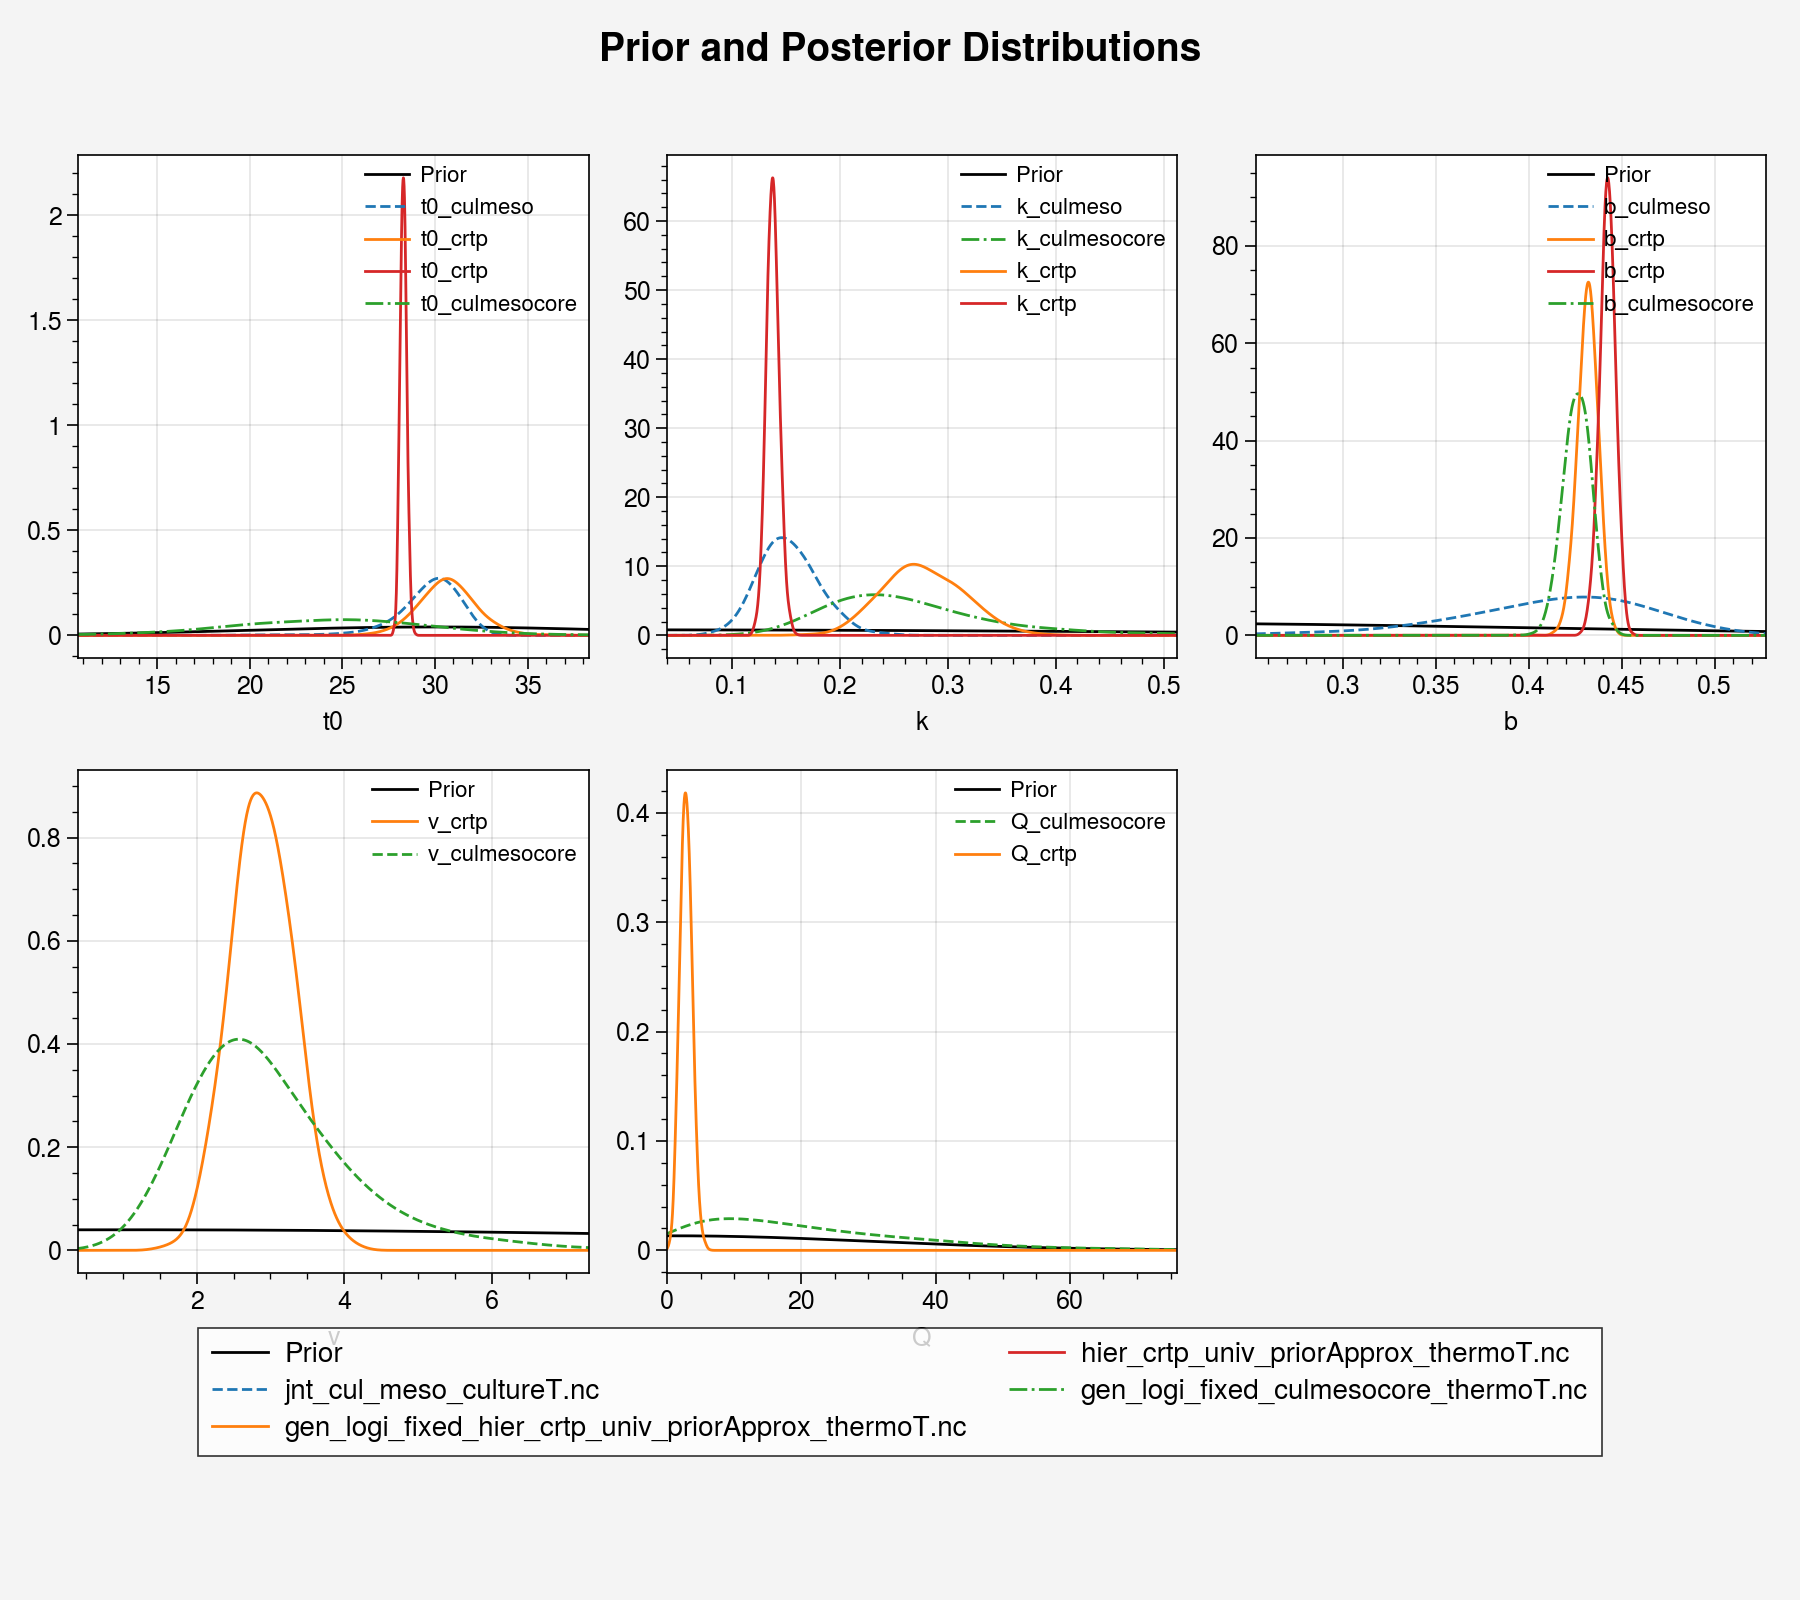

In [49]:
priors = gen_logi_fixed_cul_meso_post_ds.attrs['priors']
plot_prior_distributions(priors,
                            posterior_datasets=[
                                jnt_cul_meso_post_ds,
                                # gen_logi_fixed_cul_meso_post_ds,
                                # jnt_cul_meso_crtp_post_ds,
                                gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds,
                                # jnt_cul_meso_crtp_sst_post_ds,
                                gen_logi_fixed_culmesocore_post_ds,
                                # hier_crtp_post_ds,
                                # hier_crtp_sst_post_ds,
                                # hier_crtp_univ_prior_logmixture_post_ds,
                                hier_crtp_univ_prior_approx_post_ds,
                                # hier_crtp_sst_univ_prior_logmixture_post_ds,
                                # hier_crtp_sst_univ_prior_approx_post_ds
                                ],
                            use_linestyle_by_param=True,
                            show_histogram=False,
                            set_linewidth=1,
                            set_fig_height_factor=4,
                            set_leg_max_ncol=2,
                            )

In [50]:
x_vals = np.linspace(0, 100, 500)

## CASE 1: Generalized logistic model with free upper limit for coretop
post_ds = gen_logi_fixed_culmesocore_post_ds
n_draws = 500
posterior_df = post_ds[['t0_culmesocore', 'b_culmesocore', 'k_culmesocore', 'v_culmesocore', 'Q_culmesocore']].to_dataframe().reset_index()
sampled_draws = posterior_df.sample(n=n_draws, replace=False, random_state=42).reset_index(drop=True)
ensemble_fixed_culmesocore = np.zeros((n_draws, len(x_vals)))

for i in range(n_draws):
    row = sampled_draws.loc[i]
    ensemble_fixed_culmesocore[i, :] = generalized_logistic_model_fixed_upper(
        x_vals,
        x0=row['t0_culmesocore'],
        b=row['b_culmesocore'],
        k=row['k_culmesocore'],
        v=row['v_culmesocore'],
        Q=row['Q_culmesocore']
    )
    
median_curve_fixed_culmesocore = np.percentile(ensemble_fixed_culmesocore, 50, axis=0)
lower_bound_fixed_culmesocore = np.percentile(ensemble_fixed_culmesocore, 5, axis=0)
upper_bound_fixed_culmesocore = np.percentile(ensemble_fixed_culmesocore, 95, axis=0)

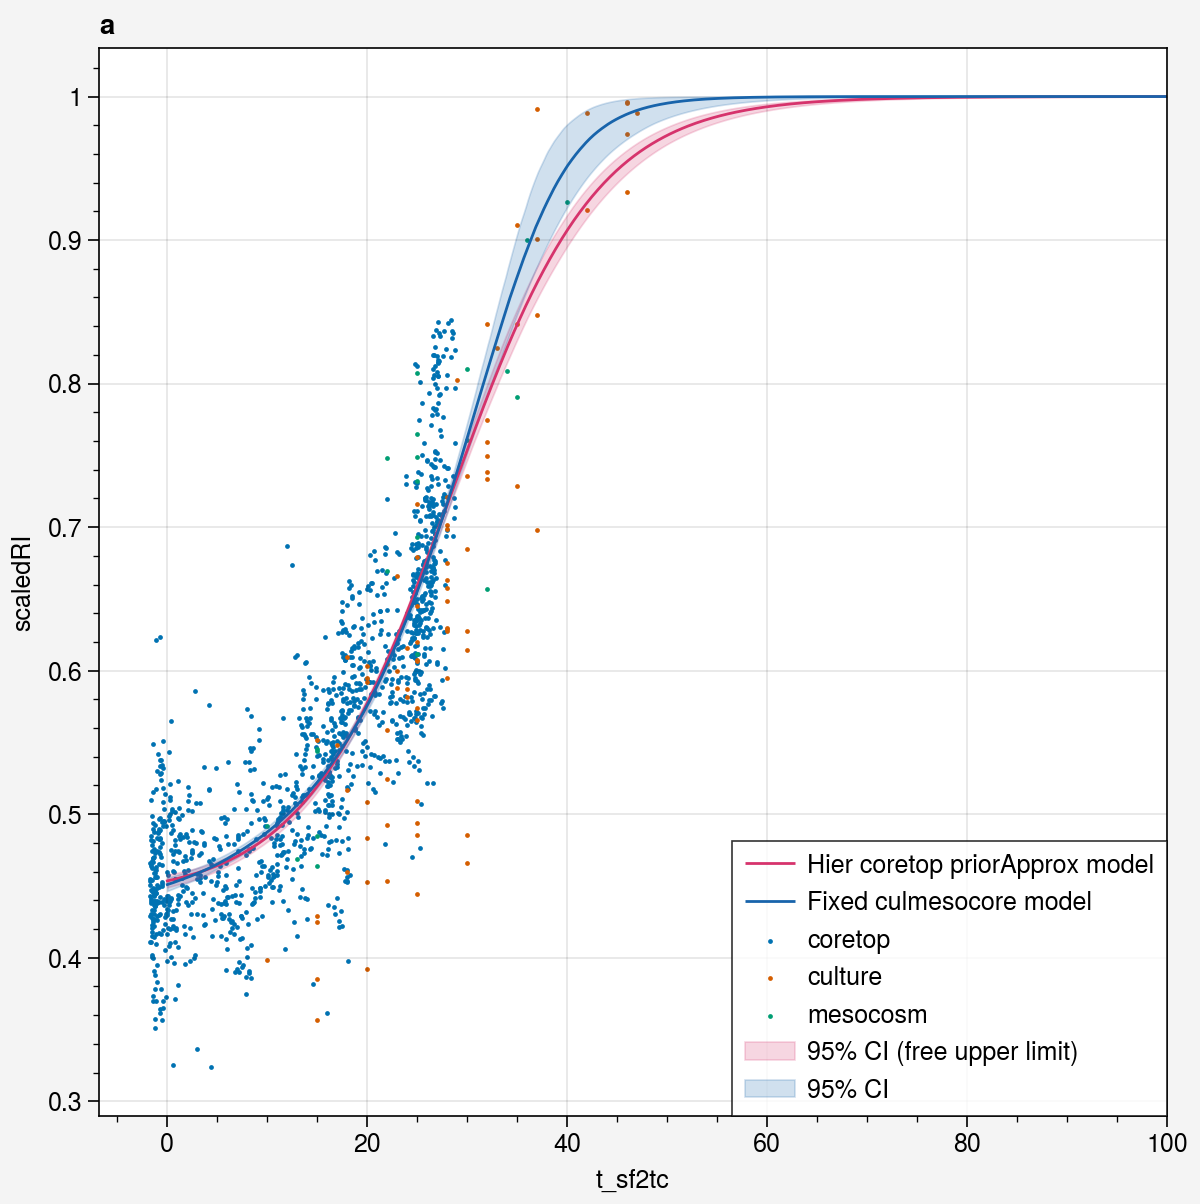

In [51]:
fig, axs = plot.subplots(width=6)

ax = axs[0]
grouped = combined_df.groupby('datatype')
for name, group in grouped:
    ax.scatter(group['t_sf2tc'], group['scaledRI'], label=name, 
               m='.', s=5)

### fully joint coretop model
ax.plot(x_vals, median_curve_hier_crtp_priorApprox, color='pink7', lw=1, label='Hier coretop priorApprox model')
ax.fill_between(x_vals, lower_bound_hier_crtp_priorApprox, upper_bound_hier_crtp_priorApprox,
               color='pink7', alpha=0.2, label='95% CI (free upper limit)')

### fixed culmesocore model
ax.plot(x_vals, median_curve_fixed_culmesocore, color='blue9', lw=1, label='Fixed culmesocore model')
ax.fill_between(x_vals, lower_bound_fixed_culmesocore, upper_bound_fixed_culmesocore, 
               color='blue9', alpha=0.2, label='95% CI')

h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='lr',ncols=1)

### 2.4 Joint cul-meso --> hier coretop - Multivariate

#### 2.4.1 fit with T and gdgt23ratio

##### Prior Approximation

In [52]:

# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()


prior_mean_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].mean(dim="draw").item()
prior_sd_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].std(dim="draw").item()

prior_mean_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].mean(dim="draw").item()
prior_sd_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].std(dim="draw").item()

prior_mean_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].mean(dim="draw").item()
prior_sd_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].std(dim="draw").item()

prior_mean_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).mean(dim="draw").item()
prior_sd_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).std(dim="draw").item()

prior_mean_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).mean(dim="draw").item()
prior_sd_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).std(dim="draw").item()

data = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    # "no3_crtp": no3_crtp,
    "no3_cutoff": -1, ## set to -1 to not use no3
    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
    "prior_mean_Q": prior_mean_Q,
    "prior_sd_Q": prior_sd_Q,
    "prior_mean_v": prior_mean_v,
    "prior_sd_v": prior_sd_v,
}

stan_file_name = 'gen_logi_fixed_hier_crtp_multiv_priorApprox'
gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_post_ds, diag = get_posterior(
    data=data, stan_file=stan_file_name,temptype='thermoT')

display(gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_post_ds)

# Save posteriors
save_posterior(gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_post_ds)

07:43:26 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/gen_logi_fixed_hier_crtp_multiv_priorApprox.stan to exe file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/gen_logi_fixed_hier_crtp_multiv_priorApprox


🔧 Compiling Stan model: gen_logi_fixed_hier_crtp_multiv_priorApprox.stan


07:43:31 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/gen_logi_fixed_hier_crtp_multiv_priorApprox
07:43:31 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: gen_logi_fixed_hier_crtp_multiv_priorApprox.stan


chain 1 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

07:43:50 - cmdstanpy - INFO - CmdStan done processing.
07:43:50 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crt

<xarray.Dataset> Size: 320kB
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 32kB 0 1 2 3 4 ... 3996 3997 3998 3999
Data variables:
    t0_crtp                 (draw) float64 32kB 29.99 30.0 31.01 ... 31.98 30.45
    k_crtp                  (draw) float64 32kB 0.2475 0.2473 ... 0.2531 0.2469
    b_crtp                  (draw) float64 32kB 0.4468 0.4474 ... 0.4538 0.4523
    Q_crtp                  (draw) float64 32kB 2.343 2.459 2.198 ... 1.409 2.0
    v_crtp                  (draw) float64 32kB 2.736 2.776 ... 2.693 2.608
    beta0_gdgt23ratio_crtp  (draw) float64 32kB -0.005586 ... -0.005543
    beta0_no3_crtp          (draw) float64 32kB -0.01224 -0.004426 ... -0.02606
    sigma_scaledRI_crtp     (draw) float64 32kB 0.04877 0.04953 ... 0.0503
    inflection_point        (draw) float64 32kB 34.05 34.12 ... 35.89 34.33
Attributes: (12/33)
    stan_model_name:              gen_logi_fixed_hier_crtp_multiv_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    run_time:                     2025-08-04T07:43:50.964801
    run_duration (sec):           19.6
    temptype:                     thermoT
    ...                           ...
    stan_diag_max_rhat:           1.00328
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1447.85
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio.nc')

In [53]:
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()


prior_mean_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].mean(dim="draw").item()
prior_sd_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].std(dim="draw").item()

prior_mean_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].mean(dim="draw").item()
prior_sd_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].std(dim="draw").item()

prior_mean_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].mean(dim="draw").item()
prior_sd_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].std(dim="draw").item()

prior_mean_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).mean(dim="draw").item()
prior_sd_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).std(dim="draw").item()

prior_mean_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).mean(dim="draw").item()
prior_sd_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).std(dim="draw").item()

data = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    # "no3_crtp": no3_crtp,
    "no3_cutoff": -1, ## set to -1 to not use no3

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
    "prior_mean_Q": prior_mean_Q,
    "prior_sd_Q": prior_sd_Q,
    "prior_mean_v": prior_mean_v,
    "prior_sd_v": prior_sd_v,
}

stan_file_name = 'gen_logi_fixed_hier_crtp_multiv_priorApprox'
gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_post_ds, diag = get_posterior(data=data, 
                                                            stan_file=stan_file_name,
                                                            temptype='sst')
display(gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_post_ds)

# Save posteriors
save_posterior(gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_post_ds)

07:43:51 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

07:44:14 - cmdstanpy - INFO - CmdStan done processing.
07:44:14 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crt

<xarray.Dataset> Size: 320kB
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 32kB 0 1 2 3 4 ... 3996 3997 3998 3999
Data variables:
    t0_crtp                 (draw) float64 32kB 32.35 27.92 ... 27.88 28.67
    k_crtp                  (draw) float64 32kB 0.2005 0.1469 ... 0.1687 0.1524
    b_crtp                  (draw) float64 32kB 0.4245 0.4235 ... 0.4402 0.4221
    Q_crtp                  (draw) float64 32kB 2.629 3.076 ... 3.303 2.996
    v_crtp                  (draw) float64 32kB 3.003 2.05 2.055 ... 2.119 2.208
    beta0_gdgt23ratio_crtp  (draw) float64 32kB -0.005383 -0.005548 ... -0.0059
    beta0_no3_crtp          (draw) float64 32kB -0.05682 -0.0347 ... -0.009182
    sigma_scaledRI_crtp     (draw) float64 32kB 0.05176 0.05269 ... 0.05199
    inflection_point        (draw) float64 32kB 37.83 32.81 ... 32.33 33.87
Attributes: (12/33)
    stan_model_name:              gen_logi_fixed_hier_crtp_multiv_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    run_time:                     2025-08-04T07:44:14.455763
    run_duration (sec):           23.39
    temptype:                     sst
    ...                           ...
    stan_diag_max_rhat:           1.00168
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1696.4
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio.nc')

In [54]:

# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()


prior_mean_t0 = jnt_cul_meso_post_ds["t0_culmeso"].mean(dim="draw").item()
prior_sd_t0 = jnt_cul_meso_post_ds["t0_culmeso"].std(dim="draw").item()

prior_mean_k = jnt_cul_meso_post_ds["k_culmeso"].mean(dim="draw").item()
prior_sd_k = jnt_cul_meso_post_ds["k_culmeso"].std(dim="draw").item()

prior_mean_b = jnt_cul_meso_post_ds["b_culmeso"].mean(dim="draw").item()
prior_sd_b = jnt_cul_meso_post_ds["b_culmeso"].std(dim="draw").item()

data = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    # "no3_crtp": no3_crtp,
    "no3_cutoff": -1, ## set to -1 to not use no3

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
}

stan_file_name = 'hier_crtp_multiv_priorApprox'
hier_crtp_priorApprox_multiv_g23r_post_ds, diag = get_posterior(data=data, 
                                                            stan_file=stan_file_name,
                                                            temptype='thermoT')
display(hier_crtp_priorApprox_multiv_g23r_post_ds)

# Save posteriors
save_posterior(hier_crtp_priorApprox_multiv_g23r_post_ds)

07:44:14 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/hier_crtp_multiv_priorApprox.stan to exe file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/hier_crtp_multiv_priorApprox


🔧 Compiling Stan model: hier_crtp_multiv_priorApprox.stan


07:44:19 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/hier_crtp_multiv_priorApprox
07:44:19 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: hier_crtp_multiv_priorApprox.stan


chain 1 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

07:44:21 - cmdstanpy - INFO - CmdStan done processing.
07:44:21 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
	Exception: normal_lpdf: Scal

<xarray.Dataset> Size: 224kB
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 32kB 0 1 2 3 4 ... 3996 3997 3998 3999
Data variables:
    t0_crtp                 (draw) float64 32kB 26.99 27.04 ... 26.81 26.93
    k_crtp                  (draw) float64 32kB 0.1387 0.139 ... 0.1312 0.1328
    b_crtp                  (draw) float64 32kB 0.4655 0.464 ... 0.4538 0.4578
    beta0_gdgt23ratio_crtp  (draw) float64 32kB -0.00585 -0.005768 ... -0.005329
    beta0_no3_crtp          (draw) float64 32kB -0.00924 -0.009892 ... -0.04338
    sigma_scaledRI_crtp     (draw) float64 32kB 0.05203 0.05226 ... 0.05024
Attributes: (12/33)
    stan_model_name:              hier_crtp_multiv_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    run_time:                     2025-08-04T07:44:21.273391
    run_duration (sec):           2.13
    temptype:                     thermoT
    ...                           ...
    stan_diag_max_rhat:           1.00258
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1699.25
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio.nc')

In [55]:
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()


prior_mean_t0 = jnt_cul_meso_post_ds["t0_culmeso"].mean(dim="draw").item()
prior_sd_t0 = jnt_cul_meso_post_ds["t0_culmeso"].std(dim="draw").item()

prior_mean_k = jnt_cul_meso_post_ds["k_culmeso"].mean(dim="draw").item()
prior_sd_k = jnt_cul_meso_post_ds["k_culmeso"].std(dim="draw").item()

prior_mean_b = jnt_cul_meso_post_ds["b_culmeso"].mean(dim="draw").item()
prior_sd_b = jnt_cul_meso_post_ds["b_culmeso"].std(dim="draw").item()

data = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    # "no3_crtp": no3_crtp,
    "no3_cutoff": -1, ## set to -1 to not use no3

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
}

stan_file_name = 'hier_crtp_multiv_priorApprox'
hier_crtp_priorApprox_multiv_sst_g23r_post_ds, diag = get_posterior(data=data, 
                                                            stan_file=stan_file_name,
                                                            temptype='sst')
display(hier_crtp_priorApprox_multiv_sst_g23r_post_ds)

# Save posteriors
save_posterior(hier_crtp_priorApprox_multiv_sst_g23r_post_ds)

07:44:21 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

07:44:23 - cmdstanpy - INFO - CmdStan done processing.
07:44:23 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
	Exception: normal_lpdf: Scal

<xarray.Dataset> Size: 224kB
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 32kB 0 1 2 3 4 ... 3996 3997 3998 3999
Data variables:
    t0_crtp                 (draw) float64 32kB 28.42 28.19 ... 28.57 28.35
    k_crtp                  (draw) float64 32kB 0.1139 0.1082 ... 0.105 0.1256
    b_crtp                  (draw) float64 32kB 0.4546 0.448 ... 0.4421 0.4667
    beta0_gdgt23ratio_crtp  (draw) float64 32kB -0.005791 ... -0.006218
    beta0_no3_crtp          (draw) float64 32kB -0.002679 -0.002758 ... -0.01062
    sigma_scaledRI_crtp     (draw) float64 32kB 0.05177 0.05086 ... 0.05163
Attributes: (12/33)
    stan_model_name:              hier_crtp_multiv_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    run_time:                     2025-08-04T07:44:23.742962
    run_duration (sec):           2.4
    temptype:                     sst
    ...                           ...
    stan_diag_max_rhat:           1.00308
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1484.0
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/hier_crtp_multiv_priorApprox_sst_gdgt23ratio.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/hier_crtp_multiv_priorApprox_sst_gdgt23ratio.nc')

##### Full Hierachical (Jnt Cul-Meso --> Hier Coretop)

In [56]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    # "no3_crtp": no3_crtp,
    "no3_cutoff": -1 ## set to -1 to not use no3

}
stan_file_name = 'gen_logi_fixed_hier_crtp_multiv'
gen_logi_fixed_hier_crtp_multiv_g23r_post_ds, diag = get_posterior(data=data, 
                                                            stan_file=stan_file_name,
                                                            temptype='thermoT')
display(gen_logi_fixed_hier_crtp_multiv_g23r_post_ds)

# Save posteriors
save_posterior(gen_logi_fixed_hier_crtp_multiv_g23r_post_ds)

#####################################################
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()
### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(sst_crtp),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    # "no3_crtp": no3_crtp,
    "no3_cutoff": -1 ## set to -1 to not use no3

}
stan_file_name = 'gen_logi_fixed_hier_crtp_multiv'
gen_logi_fixed_hier_crtp_sst_multiv_g23r_post_ds, diag = get_posterior(data=data, 
                                                                stan_file=stan_file_name,
                                                                temptype='sst',)
display(gen_logi_fixed_hier_crtp_sst_multiv_g23r_post_ds)

# Save posteriors
save_posterior(gen_logi_fixed_hier_crtp_sst_multiv_g23r_post_ds)

07:44:23 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/gen_logi_fixed_hier_crtp_multiv.stan to exe file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/gen_logi_fixed_hier_crtp_multiv


🔧 Compiling Stan model: gen_logi_fixed_hier_crtp_multiv.stan


07:44:30 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/gen_logi_fixed_hier_crtp_multiv
07:44:30 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: gen_logi_fixed_hier_crtp_multiv.stan


chain 1 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

07:46:34 - cmdstanpy - INFO - CmdStan done processing.
07:46:34 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 110, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 110, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
Exception:

<xarray.Dataset> Size: 672kB
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 32kB 0 1 2 3 4 ... 3996 3997 3998 3999
Data variables: (12/20)
    t0_culmeso              (draw) float64 32kB 30.27 28.74 ... 34.88 33.07
    k_culmeso               (draw) float64 32kB 0.2748 0.2884 ... 0.4695 0.4936
    b_culmeso               (draw) float64 32kB 0.2812 0.2756 ... 0.2077 0.2518
    Q_culmeso               (draw) float64 32kB 21.25 16.31 ... 14.97 27.78
    v_culmeso               (draw) float64 32kB 6.023 5.156 ... 10.48 9.383
    t0_crtp                 (draw) float64 32kB 29.94 29.8 29.02 ... 34.6 33.03
    ...                      ...
    sigma_b_culmeso         (draw) float64 32kB 0.1194 0.24 ... 0.3236 0.1287
    sigma_Q_culmeso         (draw) float64 32kB 1.005 1.107 1.299 ... 1.76 2.303
    sigma_v_culmeso         (draw) float64 32kB 1.02 1.327 ... 0.2433 0.7902
    sigma_scaledRI_cul      (draw) float64 32kB 0.07771 0.07762 ... 0.06644
    sigma_scaledRI_meso     (draw) float64 32kB 0.07714 0.07605 ... 0.1213
    sigma_scaledRI_crtp     (draw) float64 32kB 0.05167 0.05171 ... 0.05201
Attributes: (12/45)
    stan_model_name:              gen_logi_fixed_hier_crtp_multiv
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    run_time:                     2025-08-04T07:46:34.924776
    run_duration (sec):           66.8
    temptype:                     sst
    ...                           ...
    stan_diag_max_rhat:           1.05505
    stan_diag_n_high_rhat:        16
    stan_diag_rhat_status:        FAIL
    stan_diag_min_ess_bulk:       98.7622
    stan_diag_ess_status:         FAIL
    stan_diag_overall_status:     FAIL

Saved forward posterior to /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/gen_logi_fixed_hier_crtp_multiv_sst_gdgt23ratio.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/gen_logi_fixed_hier_crtp_multiv_sst_gdgt23ratio.nc')

In [57]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    # "no3_crtp": no3_crtp,
    "no3_cutoff": -1 ## set to -1 to not use no3

}
stan_file_name = 'gen_logi_fixed_hier_crtp_multiv'
gen_logi_fixed_hier_crtp_multiv_g23r_post_ds, diag = get_posterior(data=data, 
                                                            stan_file=stan_file_name,
                                                            temptype='thermoT')
display(gen_logi_fixed_hier_crtp_multiv_g23r_post_ds)

07:46:35 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

07:47:31 - cmdstanpy - INFO - CmdStan done processing.
07:47:31 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 110, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 110, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
Exception:

<xarray.Dataset> Size: 672kB
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 32kB 0 1 2 3 4 ... 3996 3997 3998 3999
Data variables: (12/20)
    t0_culmeso              (draw) float64 32kB 32.52 30.88 ... 30.31 30.76
    k_culmeso               (draw) float64 32kB 0.4465 0.3025 ... 0.4457 0.4621
    b_culmeso               (draw) float64 32kB 0.1455 0.08124 ... 0.2559 0.2684
    Q_culmeso               (draw) float64 32kB 49.49 35.31 ... 51.69 51.63
    v_culmeso               (draw) float64 32kB 11.58 9.07 9.985 ... 8.076 8.224
    t0_crtp                 (draw) float64 32kB 30.15 31.41 ... 29.31 29.02
    ...                      ...
    sigma_b_culmeso         (draw) float64 32kB 0.1823 0.247 ... 0.4219 0.4121
    sigma_Q_culmeso         (draw) float64 32kB 4.147 3.232 ... 0.9371 0.8411
    sigma_v_culmeso         (draw) float64 32kB 1.479 1.763 ... 0.6478 0.7199
    sigma_scaledRI_cul      (draw) float64 32kB 0.0685 0.07346 ... 0.08161
    sigma_scaledRI_meso     (draw) float64 32kB 0.1256 0.116 ... 0.1305 0.1315
    sigma_scaledRI_crtp     (draw) float64 32kB 0.04863 0.04915 ... 0.04993
Attributes: (12/45)
    stan_model_name:              gen_logi_fixed_hier_crtp_multiv
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    run_time:                     2025-08-04T07:47:31.847873
    run_duration (sec):           56.76
    temptype:                     thermoT
    ...                           ...
    stan_diag_max_rhat:           1.01679
    stan_diag_n_high_rhat:        10
    stan_diag_rhat_status:        FAIL
    stan_diag_min_ess_bulk:       340.759
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     FAIL

In [61]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    # "no3_crtp": no3_crtp,
    "no3_cutoff": -1 ## set to -1 to not use no3

}
stan_file_name = 'gen_logi_fixed_hier_crtp_multiv'
gen_logi_fixed_hier_crtp_multiv_g23r_post_ds2, diag = get_posterior(data=data, 
                                                            stan_file=stan_file_name,
                                                            temptype='thermoT')
display(gen_logi_fixed_hier_crtp_multiv_g23r_post_ds2)

07:54:10 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

07:55:07 - cmdstanpy - INFO - CmdStan done processing.
07:55:07 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 110, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 110, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
Exception:

<xarray.Dataset> Size: 672kB
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 32kB 0 1 2 3 4 ... 3996 3997 3998 3999
Data variables: (12/20)
    t0_culmeso              (draw) float64 32kB 32.52 30.88 ... 30.31 30.76
    k_culmeso               (draw) float64 32kB 0.4465 0.3025 ... 0.4457 0.4621
    b_culmeso               (draw) float64 32kB 0.1455 0.08124 ... 0.2559 0.2684
    Q_culmeso               (draw) float64 32kB 49.49 35.31 ... 51.69 51.63
    v_culmeso               (draw) float64 32kB 11.58 9.07 9.985 ... 8.076 8.224
    t0_crtp                 (draw) float64 32kB 30.15 31.41 ... 29.31 29.02
    ...                      ...
    sigma_b_culmeso         (draw) float64 32kB 0.1823 0.247 ... 0.4219 0.4121
    sigma_Q_culmeso         (draw) float64 32kB 4.147 3.232 ... 0.9371 0.8411
    sigma_v_culmeso         (draw) float64 32kB 1.479 1.763 ... 0.6478 0.7199
    sigma_scaledRI_cul      (draw) float64 32kB 0.0685 0.07346 ... 0.08161
    sigma_scaledRI_meso     (draw) float64 32kB 0.1256 0.116 ... 0.1305 0.1315
    sigma_scaledRI_crtp     (draw) float64 32kB 0.04863 0.04915 ... 0.04993
Attributes: (12/45)
    stan_model_name:              gen_logi_fixed_hier_crtp_multiv
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    run_time:                     2025-08-04T07:55:07.764613
    run_duration (sec):           57.48
    temptype:                     thermoT
    ...                           ...
    stan_diag_max_rhat:           1.01679
    stan_diag_n_high_rhat:        10
    stan_diag_rhat_status:        FAIL
    stan_diag_min_ess_bulk:       340.759
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     FAIL

In [63]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    # "no3_crtp": no3_crtp,
    "no3_cutoff": -1 ## set to -1 to not use no3

}
stan_file_name = 'hier_crtp_multiv'
hier_crtp_multiv_g23r_post_ds, diag = get_posterior(data=data, 
                                                            stan_file=stan_file_name,
                                                            temptype='thermoT')
display(hier_crtp_multiv_g23r_post_ds)

# Save posteriors
save_posterior(hier_crtp_multiv_g23r_post_ds)

#####################################################
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()
### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(sst_crtp),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    # "no3_crtp": no3_crtp,
    "no3_cutoff": -1 ## set to -1 to not use no3

}
stan_file_name = 'hier_crtp_multiv'
hier_crtp_sst_multiv_g23r_post_ds, diag = get_posterior(data=data, 
                                                                stan_file=stan_file_name,
                                                                temptype='sst',)
display(hier_crtp_sst_multiv_g23r_post_ds)

# Save posteriors
save_posterior(hier_crtp_sst_multiv_g23r_post_ds)

07:55:21 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/hier_crtp_multiv.stan to exe file /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/hier_crtp_multiv


🔧 Compiling Stan model: hier_crtp_multiv.stan


07:55:27 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/stan_models/hier_crtp_multiv
07:55:27 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: hier_crtp_multiv.stan


chain 1 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

07:55:36 - cmdstanpy - INFO - CmdStan done processing.
07:55:36 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line

<xarray.Dataset> Size: 480kB
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 32kB 0 1 2 3 4 ... 3996 3997 3998 3999
Data variables: (12/14)
    t0_culmeso              (draw) float64 32kB 31.06 29.23 ... 28.53 28.59
    k_culmeso               (draw) float64 32kB 0.1541 0.1586 ... 0.1494 0.141
    b_culmeso               (draw) float64 32kB 0.4498 0.4336 ... 0.3825 0.386
    t0_crtp                 (draw) float64 32kB 28.05 28.12 ... 28.47 28.44
    k_crtp                  (draw) float64 32kB 0.1087 0.1061 ... 0.1032 0.1026
    b_crtp                  (draw) float64 32kB 0.4462 0.4486 ... 0.4433 0.4428
    ...                      ...
    sigma_t0_culmeso        (draw) float64 32kB 2.088 1.381 ... 0.2198 0.1592
    sigma_k_culmeso         (draw) float64 32kB 0.06705 0.05277 ... 0.0635
    sigma_b_culmeso         (draw) float64 32kB 0.07256 0.02643 ... 0.06401
    sigma_scaledRI_cul      (draw) float64 32kB 0.07468 0.0798 ... 0.0827
    sigma_scaledRI_meso     (draw) float64 32kB 0.09302 0.08357 ... 0.1308
    sigma_scaledRI_crtp     (draw) float64 32kB 0.05275 0.05278 ... 0.05239
Attributes: (12/45)
    stan_model_name:              hier_crtp_multiv
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    run_time:                     2025-08-04T07:55:36.939103
    run_duration (sec):           4.64
    temptype:                     sst
    ...                           ...
    stan_diag_max_rhat:           1.00426
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1132.42
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     FAIL

Saved forward posterior to /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/hier_crtp_multiv_sst_gdgt23ratio.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/hier_crtp_multiv_sst_gdgt23ratio.nc')

#### 2.4.2 fit the data with T, gdgt23ratio, and no3

##### Prior Approximation

In [64]:

# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median','no3_sf2tc_avg']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()
no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

prior_mean_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].mean(dim="draw").item()
prior_sd_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].std(dim="draw").item()

prior_mean_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].mean(dim="draw").item()
prior_sd_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].std(dim="draw").item()

prior_mean_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].mean(dim="draw").item()
prior_sd_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].std(dim="draw").item()

prior_mean_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).mean(dim="draw").item()
prior_sd_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).std(dim="draw").item()

prior_mean_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).mean(dim="draw").item()
prior_sd_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).std(dim="draw").item()

no3_cutoff_values = [
    1, 1.5, 2, 2.5, 2.7,
    5, 10, 15,100
    ]
for no3_cutoff in no3_cutoff_values:
    print(no3_cutoff)
    data = {
        "N_crtp": len(t_crtp),
        "t_crtp": t_crtp,
        "scaledRI_crtp": scaledRI_crtp,
        "gdgt23ratio_crtp": gdgt23ratio_crtp,
        "no3_crtp": no3_crtp,
        "no3_cutoff": no3_cutoff, ## set to -1 to not use no3

        "prior_mean_t0": prior_mean_t0,
        "prior_sd_t0": prior_sd_t0,
        "prior_mean_k": prior_mean_k,
        "prior_sd_k": prior_sd_k,
        "prior_mean_b": prior_mean_b,
        "prior_sd_b": prior_sd_b,
        "prior_mean_Q": prior_mean_Q,
        "prior_sd_Q": prior_sd_Q,
        "prior_mean_v": prior_mean_v,
        "prior_sd_v": prior_sd_v,
    }
    

    stan_file_name = 'gen_logi_fixed_hier_crtp_multiv_priorApprox'
    gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_no3_post_ds, diag = get_posterior(data=data, 
                                                                stan_file=stan_file_name,
                                                                temptype='thermoT')
    display(gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_no3_post_ds)

    # Save posteriors
    save_posterior(gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_no3_post_ds)

07:55:37 - cmdstanpy - INFO - CmdStan start processing


1


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

07:58:57 - cmdstanpy - INFO - CmdStan done processing.
07:58:57 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crt

<xarray.Dataset> Size: 320kB
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 32kB 0 1 2 3 4 ... 3996 3997 3998 3999
Data variables:
    t0_crtp                 (draw) float64 32kB 32.47 34.08 33.87 ... 29.73 30.1
    k_crtp                  (draw) float64 32kB 0.2664 0.2448 ... 0.2485 0.2343
    b_crtp                  (draw) float64 32kB 0.4643 0.461 ... 0.4712 0.4731
    Q_crtp                  (draw) float64 32kB 1.721 1.387 ... 2.792 2.335
    v_crtp                  (draw) float64 32kB 2.905 2.988 ... 2.505 2.313
    beta0_gdgt23ratio_crtp  (draw) float64 32kB -0.004807 ... -0.004468
    beta0_no3_crtp          (draw) float64 32kB -0.01601 -0.01631 ... -0.01732
    sigma_scaledRI_crtp     (draw) float64 32kB 0.04659 0.04856 ... 0.04798
    inflection_point        (draw) float64 32kB 36.47 38.55 ... 33.42 33.68
Attributes: (12/40)
    stan_model_name:              gen_logi_fixed_hier_crtp_multiv_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    run_time:                     2025-08-04T07:58:57.080201
    run_duration (sec):           20.46
    temptype:                     thermoT
    ...                           ...
    stan_diag_max_rhat:           1.00459
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1388.42
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_100.0.nc


In [65]:
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median','no3_sf2tc_avg']].dropna()
t_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()
no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

prior_mean_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].mean(dim="draw").item()
prior_sd_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].std(dim="draw").item()

prior_mean_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].mean(dim="draw").item()
prior_sd_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].std(dim="draw").item()

prior_mean_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].mean(dim="draw").item()
prior_sd_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].std(dim="draw").item()

prior_mean_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).mean(dim="draw").item()
prior_sd_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).std(dim="draw").item()

prior_mean_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).mean(dim="draw").item()
prior_sd_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).std(dim="draw").item()

no3_cutoff_values = [
    1, 1.5, 2, 2.5, 2.7,
    5, 10, 15,100
    ]
for no3_cutoff in no3_cutoff_values:
    data = {
        "N_crtp": len(t_crtp),
        "t_crtp": t_crtp,
        "scaledRI_crtp": scaledRI_crtp,
        "gdgt23ratio_crtp": gdgt23ratio_crtp,
        "no3_crtp": no3_crtp,
        "no3_cutoff": no3_cutoff, ## set to -1 to not use no3

        "prior_mean_t0": prior_mean_t0,
        "prior_sd_t0": prior_sd_t0,
        "prior_mean_k": prior_mean_k,
        "prior_sd_k": prior_sd_k,
        "prior_mean_b": prior_mean_b,
        "prior_sd_b": prior_sd_b,
        "prior_mean_Q": prior_mean_Q,
        "prior_sd_Q": prior_sd_Q,
        "prior_mean_v": prior_mean_v,
        "prior_sd_v": prior_sd_v,
    }

    stan_file_name = 'gen_logi_fixed_hier_crtp_multiv_priorApprox'
    gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_no3_post_ds, diag = get_posterior(data=data, 
                                                                stan_file=stan_file_name,
                                                                temptype='sst')
    display(gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_no3_post_ds)

    # Save posteriors
    save_posterior(gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_no3_post_ds)

07:58:57 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

08:02:21 - cmdstanpy - INFO - CmdStan done processing.
08:02:21 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crt

<xarray.Dataset> Size: 320kB
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 32kB 0 1 2 3 4 ... 3996 3997 3998 3999
Data variables:
    t0_crtp                 (draw) float64 32kB 32.26 31.5 33.94 ... 33.2 29.74
    k_crtp                  (draw) float64 32kB 0.2664 0.2172 ... 0.2465 0.2065
    b_crtp                  (draw) float64 32kB 0.4849 0.4641 ... 0.4719 0.4738
    Q_crtp                  (draw) float64 32kB 2.794 3.125 ... 3.038 3.739
    v_crtp                  (draw) float64 32kB 2.737 2.454 2.363 ... 2.994 2.34
    beta0_gdgt23ratio_crtp  (draw) float64 32kB -0.005074 ... -0.005614
    beta0_no3_crtp          (draw) float64 32kB -0.02563 -0.02166 ... -0.02032
    sigma_scaledRI_crtp     (draw) float64 32kB 0.04921 0.04949 ... 0.04915
    inflection_point        (draw) float64 32kB 36.04 35.64 ... 37.65 33.85
Attributes: (12/40)
    stan_model_name:              gen_logi_fixed_hier_crtp_multiv_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    run_time:                     2025-08-04T08:02:21.906128
    run_duration (sec):           22.74
    temptype:                     sst
    ...                           ...
    stan_diag_max_rhat:           1.00151
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1542.52
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_100.0.nc


In [66]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median','no3_sf2tc_avg']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()
no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

no3_cutoff_values = [
    1, 1.5, 2, 2.5, 2.7,
    5, 10, 15, 100
    ]
for no3_cutoff in no3_cutoff_values:
    ### cul + meso + coretop
    data = {
        "N_cul": len(culture_data_full),
        "t_cul": t_cul,
        "scaledRI_cul": scaledRI_cul,
        "N_meso": len(meso_data_full),
        "t_meso": t_meso,
        "scaledRI_meso": scaledRI_meso,
        "N_crtp": len(t_crtp),
        "t_crtp": t_crtp,
        "scaledRI_crtp": scaledRI_crtp,
        "gdgt23ratio_crtp": gdgt23ratio_crtp,
        "no3_crtp": no3_crtp,
        "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

    }
    stan_file_name = 'hier_crtp_multiv'
    hier_crtp_multiv_g23r_no3_post_ds, diag = get_posterior(data=data, 
                                                                    stan_file=stan_file_name,
                                                                    temptype='thermoT',
                                                                    )
    display(hier_crtp_multiv_g23r_no3_post_ds)

    # Save posteriors
    save_posterior(hier_crtp_multiv_g23r_no3_post_ds)

08:02:21 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

08:03:11 - cmdstanpy - INFO - CmdStan done processing.
08:03:11 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line

<xarray.Dataset> Size: 480kB
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 32kB 0 1 2 3 4 ... 3996 3997 3998 3999
Data variables: (12/14)
    t0_culmeso              (draw) float64 32kB 31.23 31.02 ... 28.64 28.36
    k_culmeso               (draw) float64 32kB 0.1851 0.1777 ... 0.1341 0.1305
    b_culmeso               (draw) float64 32kB 0.4595 0.4548 ... 0.3711 0.3626
    t0_crtp                 (draw) float64 32kB 28.61 28.59 28.4 ... 28.6 28.11
    k_crtp                  (draw) float64 32kB 0.1305 0.1281 ... 0.1364 0.1363
    b_crtp                  (draw) float64 32kB 0.4807 0.4802 ... 0.4769 0.483
    ...                      ...
    sigma_t0_culmeso        (draw) float64 32kB 2.927 2.775 ... 0.1506 0.6241
    sigma_k_culmeso         (draw) float64 32kB 0.1024 0.1489 ... 0.06651
    sigma_b_culmeso         (draw) float64 32kB 0.04869 0.03963 ... 0.2265
    sigma_scaledRI_cul      (draw) float64 32kB 0.07042 0.07084 ... 0.07848
    sigma_scaledRI_meso     (draw) float64 32kB 0.1108 0.1173 ... 0.09541
    sigma_scaledRI_crtp     (draw) float64 32kB 0.04727 0.04664 ... 0.04877
Attributes: (12/52)
    stan_model_name:              hier_crtp_multiv
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    run_time:                     2025-08-04T08:03:11.187714
    run_duration (sec):           5.18
    temptype:                     thermoT
    ...                           ...
    stan_diag_max_rhat:           1.04623
    stan_diag_n_high_rhat:        11
    stan_diag_rhat_status:        FAIL
    stan_diag_min_ess_bulk:       62.0287
    stan_diag_ess_status:         FAIL
    stan_diag_overall_status:     FAIL

Saved forward posterior to /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/hier_crtp_multiv_thermoT_gdgt23ratio_no3_100.0.nc


In [67]:
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median', 'no3_sf2tc_avg']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()
no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

no3_cutoff_values = [
    1, 1.5, 2, 2.5, 2.7,
    5, 10, 15, 100
    ]
for no3_cutoff in no3_cutoff_values:
    
    ### cul + meso + coretop
    data = {
        "N_cul": len(culture_data_full),
        "t_cul": t_cul,
        "scaledRI_cul": scaledRI_cul,
        "N_meso": len(meso_data_full),
        "t_meso": t_meso,
        "scaledRI_meso": scaledRI_meso,
        "N_crtp": len(sst_crtp),
        "t_crtp": sst_crtp,
        "scaledRI_crtp": scaledRI_crtp,
        "gdgt23ratio_crtp": gdgt23ratio_crtp,
        "no3_crtp": no3_crtp,
        "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

    }
    stan_file_name = 'hier_crtp_multiv'
    hier_crtp_sst_multiv_g23r_no3_post_ds, diag = get_posterior(data=data, 
                                                                                    stan_file=stan_file_name,
                                                                                    temptype='sst',
                                                                                    )
    display(hier_crtp_sst_multiv_g23r_no3_post_ds)

    # Save posteriors
    save_posterior(hier_crtp_sst_multiv_g23r_no3_post_ds)

08:03:11 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

08:03:57 - cmdstanpy - INFO - CmdStan done processing.
08:03:57 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line

<xarray.Dataset> Size: 480kB
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 32kB 0 1 2 3 4 ... 3996 3997 3998 3999
Data variables: (12/14)
    t0_culmeso              (draw) float64 32kB 30.76 28.61 31.55 ... 29.14 31.4
    k_culmeso               (draw) float64 32kB 0.1656 0.1095 ... 0.1549 0.1595
    b_culmeso               (draw) float64 32kB 0.4515 0.3618 ... 0.3958 0.4476
    t0_crtp                 (draw) float64 32kB 29.93 30.23 30.14 ... 30.3 30.04
    k_crtp                  (draw) float64 32kB 0.1219 0.1166 ... 0.1186 0.126
    b_crtp                  (draw) float64 32kB 0.483 0.4765 ... 0.4777 0.4841
    ...                      ...
    sigma_t0_culmeso        (draw) float64 32kB 0.4928 2.113 ... 0.841 4.238
    sigma_k_culmeso         (draw) float64 32kB 0.06102 0.07934 ... 0.1326
    sigma_b_culmeso         (draw) float64 32kB 0.05456 0.2587 ... 0.1512 0.2557
    sigma_scaledRI_cul      (draw) float64 32kB 0.07297 0.07934 ... 0.08127
    sigma_scaledRI_meso     (draw) float64 32kB 0.1179 0.09951 ... 0.08333
    sigma_scaledRI_crtp     (draw) float64 32kB 0.04936 0.04935 ... 0.04669
Attributes: (12/52)
    stan_model_name:              hier_crtp_multiv
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    run_time:                     2025-08-04T08:03:57.664084
    run_duration (sec):           5.39
    temptype:                     sst
    ...                           ...
    stan_diag_max_rhat:           1.00704
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       848.632
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     FAIL

Saved forward posterior to /home/ronnie-rattan/Documents/GitHub/TEXAS/TEXAS/posterior_cache/hier_crtp_multiv_sst_gdgt23ratio_no3_100.0.nc


# Posterior plots --- QC

### 1. Joint culture-mesocosm

Grouped param names: {'t0': ['t0_culmeso'], 'k': ['k_culmeso'], 'b': ['b_culmeso'], 'v': [], 'Q': [], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Grouped param names: {'t0': ['t0_culmeso'], 'k': ['k_culmeso'], 'b': ['b_culmeso'], 'v': [], 'Q': [], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
['t0', 'k', 'b']


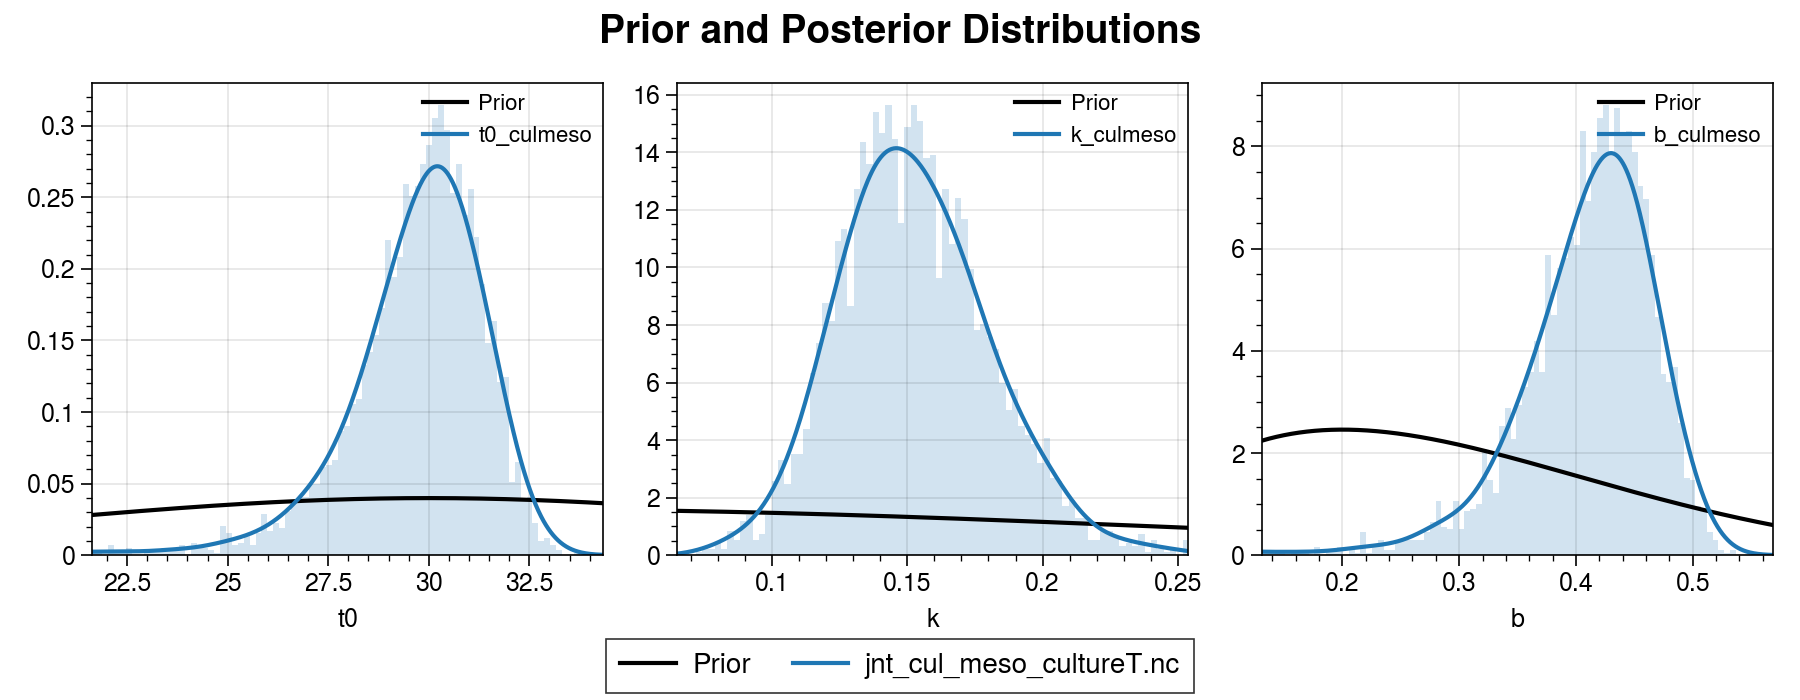

In [68]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = plot_prior_distributions(
    priors,
    posterior_datasets=[jnt_cul_meso_post_ds]
)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want


### 2. Joint  culture-mesocosm vs culture-mesocosm-coretop

Grouped param names: {'t0': ['t0_culmesocore', 't0_culmeso'], 'k': ['k_culmeso', 'k_culmesocore'], 'b': ['b_culmesocore', 'b_culmeso'], 'v': [], 'Q': [], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Grouped param names: {'t0': ['t0_culmesocore', 't0_culmeso'], 'k': ['k_culmeso', 'k_culmesocore'], 'b': ['b_culmesocore', 'b_culmeso'], 'v': [], 'Q': [], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
['t0', 'k', 'b']


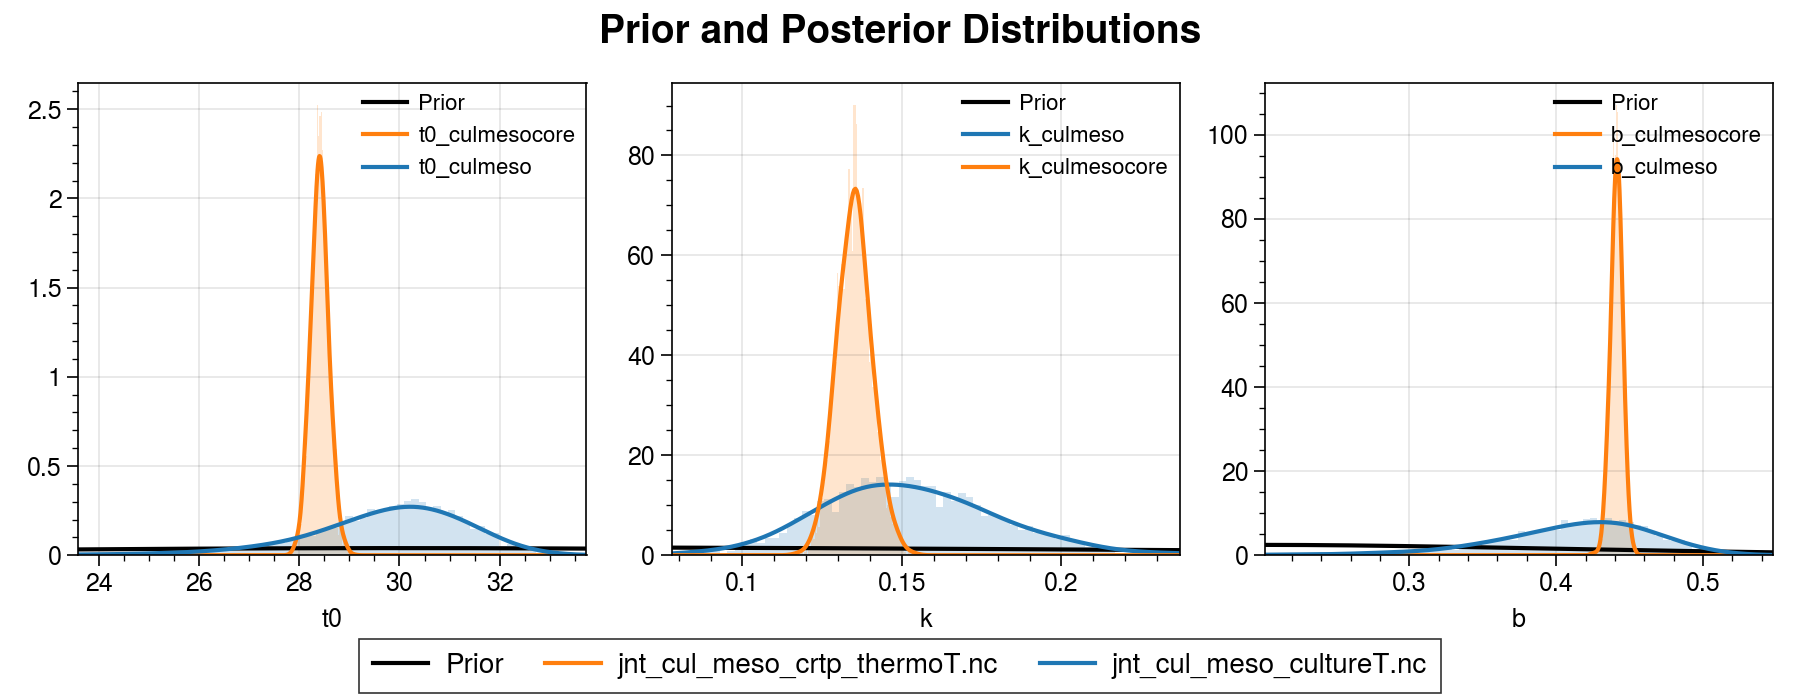

In [69]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_post_ds,
        jnt_cul_meso_crtp_post_ds
        ],

)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want


### 3. jnt-culture-mesocosm vs jnt-culture-mesocosm-coretop vs jnt-culmeso-hier-crtp

Grouped param names: {'t0': ['t0_crtp', 't0_culmesocore', 't0_culmeso'], 'k': ['k_crtp', 'k_culmeso', 'k_culmesocore'], 'b': ['b_culmesocore', 'b_culmeso', 'b_crtp'], 'v': [], 'Q': [], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Grouped param names: {'t0': ['t0_crtp', 't0_culmesocore', 't0_culmeso'], 'k': ['k_crtp', 'k_culmeso', 'k_culmesocore'], 'b': ['b_culmesocore', 'b_culmeso', 'b_crtp'], 'v': [], 'Q': [], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
['t0', 'k', 'b']


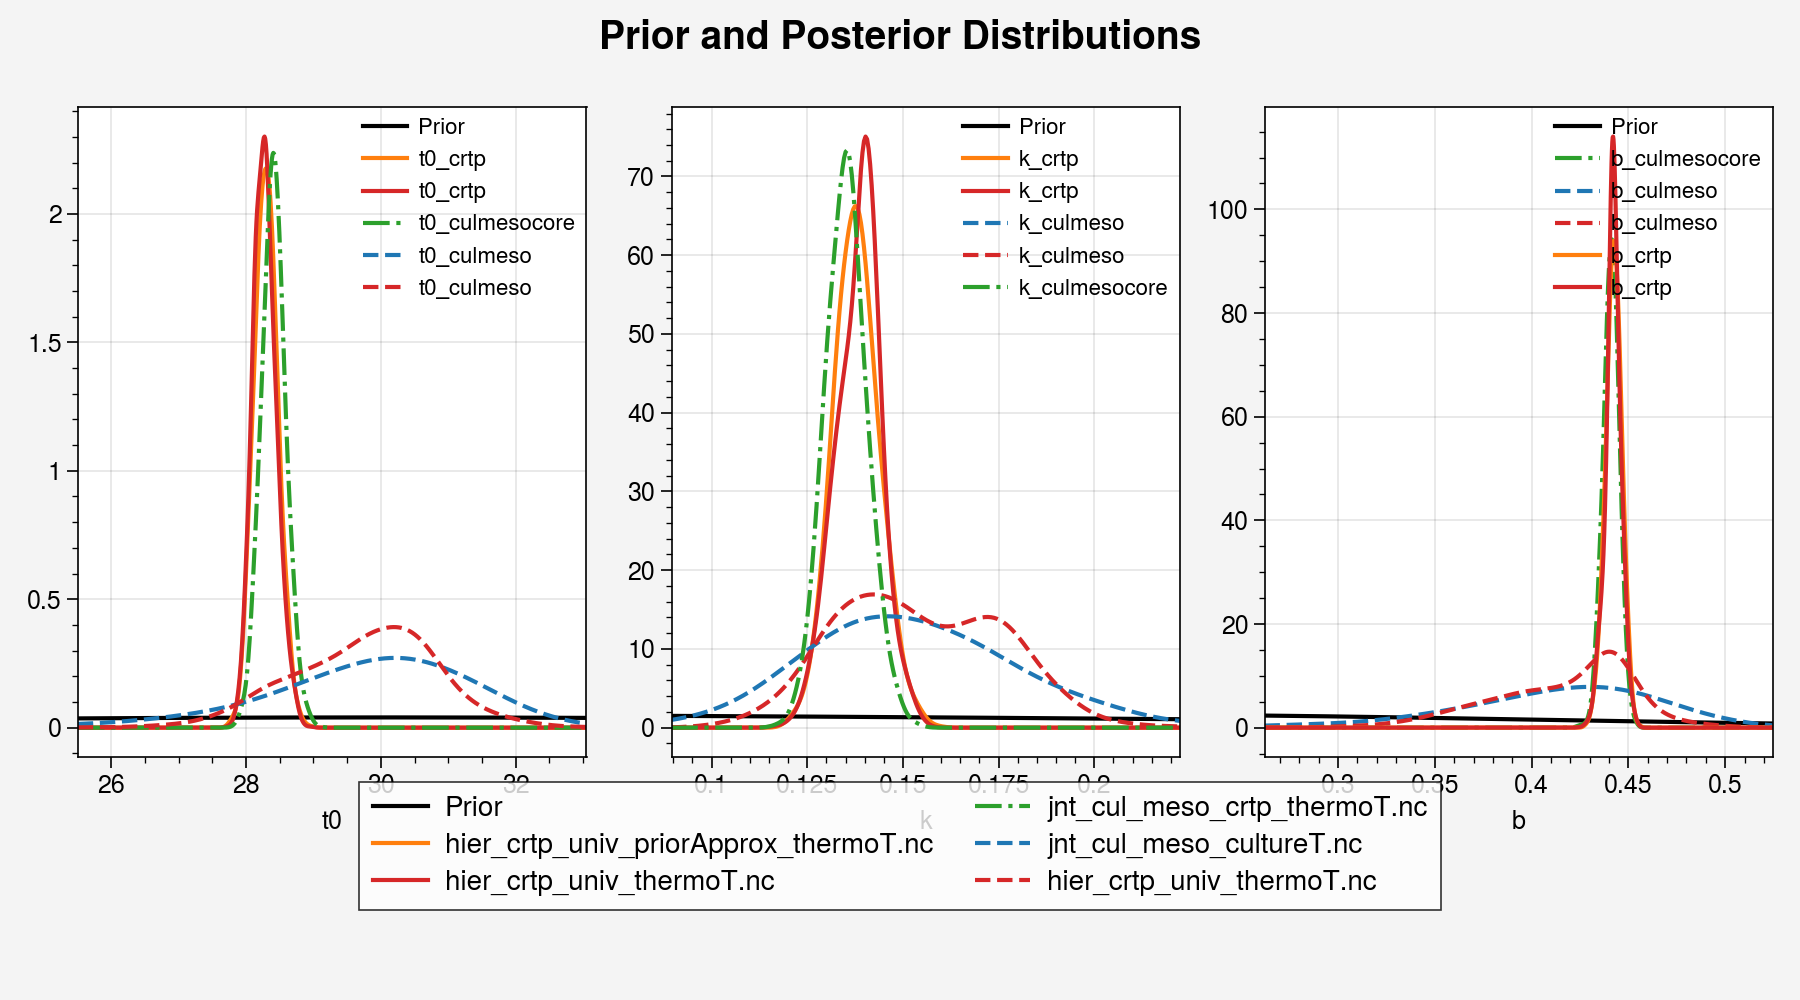

In [70]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_post_ds,
        # hier_crtp_univ_prior_logmixture_post_ds,
        hier_crtp_univ_prior_approx_post_ds,
        jnt_cul_meso_crtp_post_ds,
        hier_crtp_post_ds
        ],
    use_linestyle_by_param=True,
    show_histogram=False,
    set_fig_height_factor=5,
    set_leg_max_ncol=2
)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)


Grouped param names: {'t0': ['t0_crtp', 't0_culmesocore', 't0_culmeso'], 'k': ['k_crtp', 'k_culmeso', 'k_culmesocore'], 'b': ['b_culmesocore', 'b_culmeso', 'b_crtp'], 'v': [], 'Q': [], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Grouped param names: {'t0': ['t0_crtp', 't0_culmesocore', 't0_culmeso'], 'k': ['k_crtp', 'k_culmeso', 'k_culmesocore'], 'b': ['b_culmesocore', 'b_culmeso', 'b_crtp'], 'v': [], 'Q': [], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
['t0', 'k', 'b']


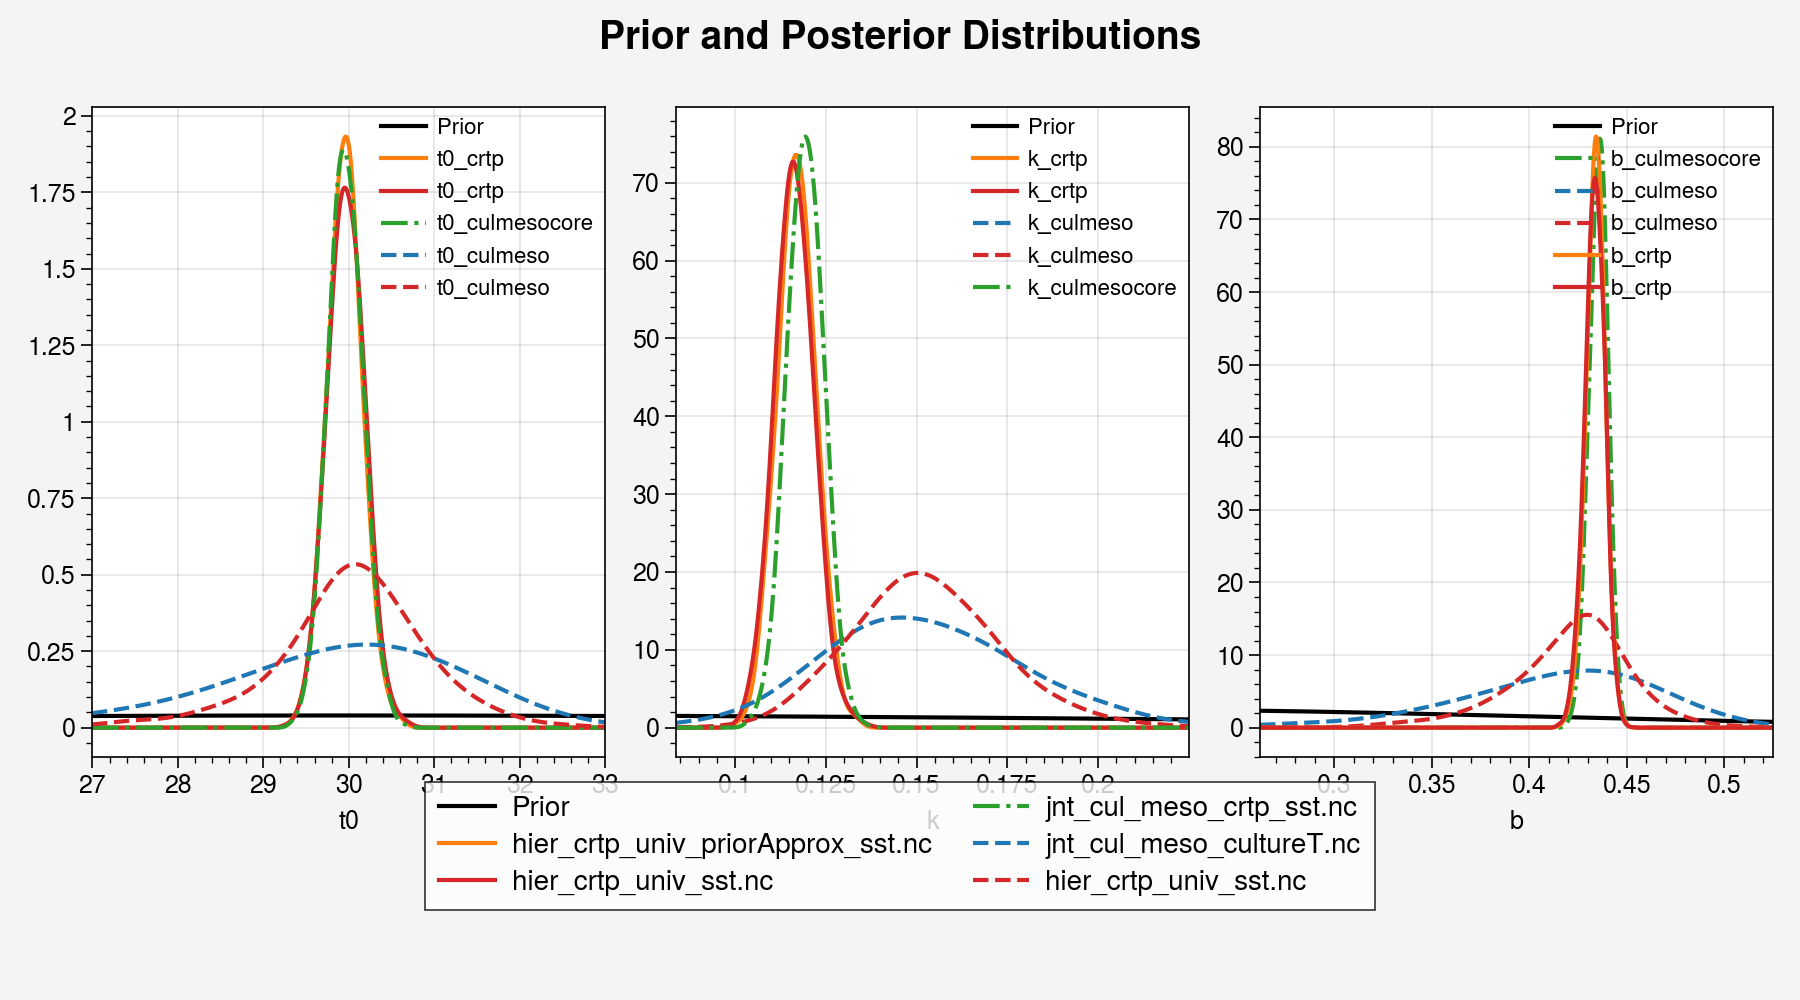

In [71]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_post_ds,
        # hier_crtp_univ_prior_logmixture_post_ds,
        hier_crtp_sst_univ_prior_approx_post_ds,
        jnt_cul_meso_crtp_sst_post_ds,
        hier_crtp_sst_post_ds
        ],
    use_linestyle_by_param=True,
    show_histogram=False,
    set_fig_height_factor=5,
    set_leg_max_ncol=2
)
axes[0][0].set_xlim(27,33)
# Later in notebook
fig.savefig("posterior_check.png", dpi=300)


Grouped param names: {'t0': ['t0_culmesocore', 't0_culmeso'], 'k': ['k_culmeso', 'k_culmesocore'], 'b': ['b_culmesocore', 'b_culmeso'], 'v': [], 'Q': [], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Grouped param names: {'t0': ['t0_culmesocore', 't0_culmeso'], 'k': ['k_culmeso', 'k_culmesocore'], 'b': ['b_culmesocore', 'b_culmeso'], 'v': [], 'Q': [], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
['t0', 'k', 'b']


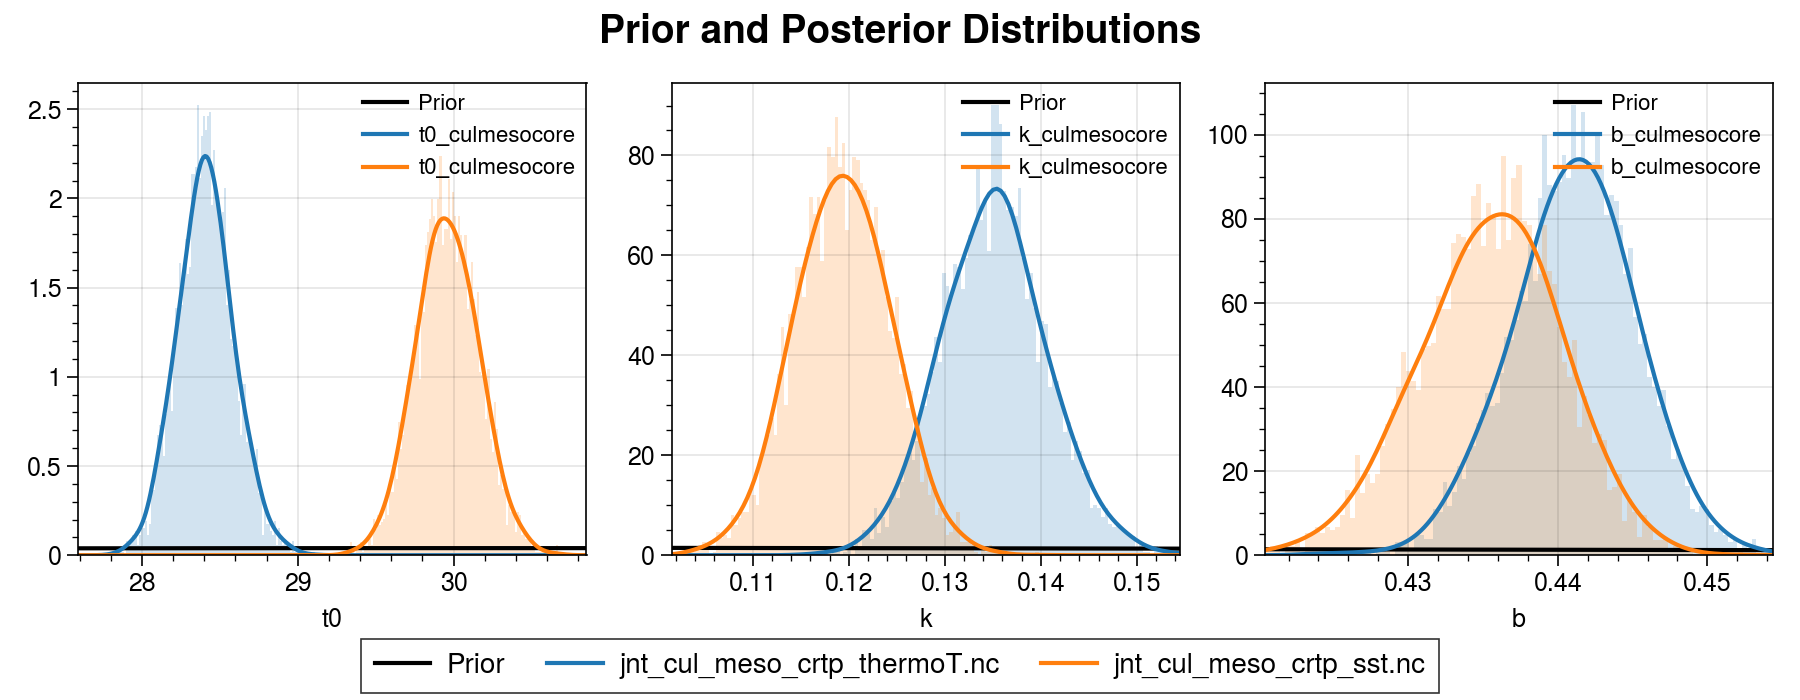

In [72]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_crtp_post_ds,
        jnt_cul_meso_crtp_sst_post_ds
        ],

)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want


In [73]:
jnt_cul_meso_post_ds.attrs.get('use_gdgt23ratio',0)

0

In [ ]:
# ## load the posterior datasets
# hier_crtp_multiv_no3_post_ds = load_posterior('hier_crtp_multiv_thermoT_no3_1.0')
# hier_crtp_multiv_g23r_no3_post_ds = load_posterior('hier_crtp_multiv_thermoT_gdgt23ratio_no3_1.0')
# priors = hier_crtp_multiv_g23r_no3_post_ds.attrs['priors']

# fig, axes = plot_prior_distributions(
#                 priors,
#                 posterior_datasets=[
#                     jnt_cul_meso_post_ds,
#                     jnt_cul_meso_crtp_post_ds,
#                     hier_crtp_post_ds,
#                     hier_crtp_univ_prior_approx_post_ds,
#                     hier_crtp_multiv_g23r_post_ds,
#                     hier_crtp_multiv_no3_post_ds,
#                     hier_crtp_multiv_g23r_no3_post_ds,
#                     ],

#                 # focus_on_posterior=False,
#                 use_linestyle_by_param=True,
#                 show_histogram=False,
#                 set_leg_max_ncol=2,
#                 set_fig_height_factor=4.5,
#                 # suffix_include=["crtp","culmesocore"]
#                 )

# axes[1][0].set_xlim(-0.025,0)
# axes[0][0].set_xlim(25,35)

In [75]:
# coretop_df['new_deltaRI'].hist()

In [76]:
# fig,  axs = plot.subplots(ncols=2,width=10)
# plot_data = coretop_df_temp
# ax = axs[0]
# plot_x = plot_data['t_sf2tc_avg']
# plot_y = plot_data['scaledRI_median']
# plot_c = plot_data['gdgt23ratio_median']
# m = ax.scatter(plot_x, plot_y, s=10, c=plot_c, mec='k', cmap='blues', levels=[0,5,10,15], label='Core-top data')
# ax.colorbar(m, loc='r')

# plot_data = coretop_df
# ax = axs[1]
# plot_x = plot_data['t_sf2tc_avg']
# plot_y = plot_data['scaledRI_median']
# plot_c = plot_data['gdgt23ratio_median']
# m = ax.scatter(plot_x, plot_y, s=10, c=plot_c, mec='k', cmap='blues', levels=[0,5,10,15], label='Core-top data')
# ax.colorbar(m, loc='r')

Grouped param names: {'t0': ['t0_culmeso', 't0_crtp'], 'k': ['k_culmeso', 'k_crtp'], 'b': ['b_culmeso', 'b_crtp'], 'v': ['v_culmeso', 'v_crtp'], 'Q': ['Q_culmeso', 'Q_crtp'], 'a': ['a_crtp', 'a_culmeso'], 'beta0_gdgt23ratio': ['beta0_gdgt23ratio_crtp'], 'beta0_no3': ['beta0_no3_crtp']}
Grouped param names: {'t0': ['t0_culmeso', 't0_crtp'], 'k': ['k_culmeso', 'k_crtp'], 'b': ['b_culmeso', 'b_crtp'], 'v': ['v_culmeso', 'v_crtp'], 'Q': ['Q_culmeso', 'Q_crtp'], 'a': ['a_crtp', 'a_culmeso'], 'beta0_gdgt23ratio': ['beta0_gdgt23ratio_crtp'], 'beta0_no3': ['beta0_no3_crtp']}
['t0', 'k', 'b', 'v', 'Q', 'a', 'beta0_gdgt23ratio', 'beta0_no3']


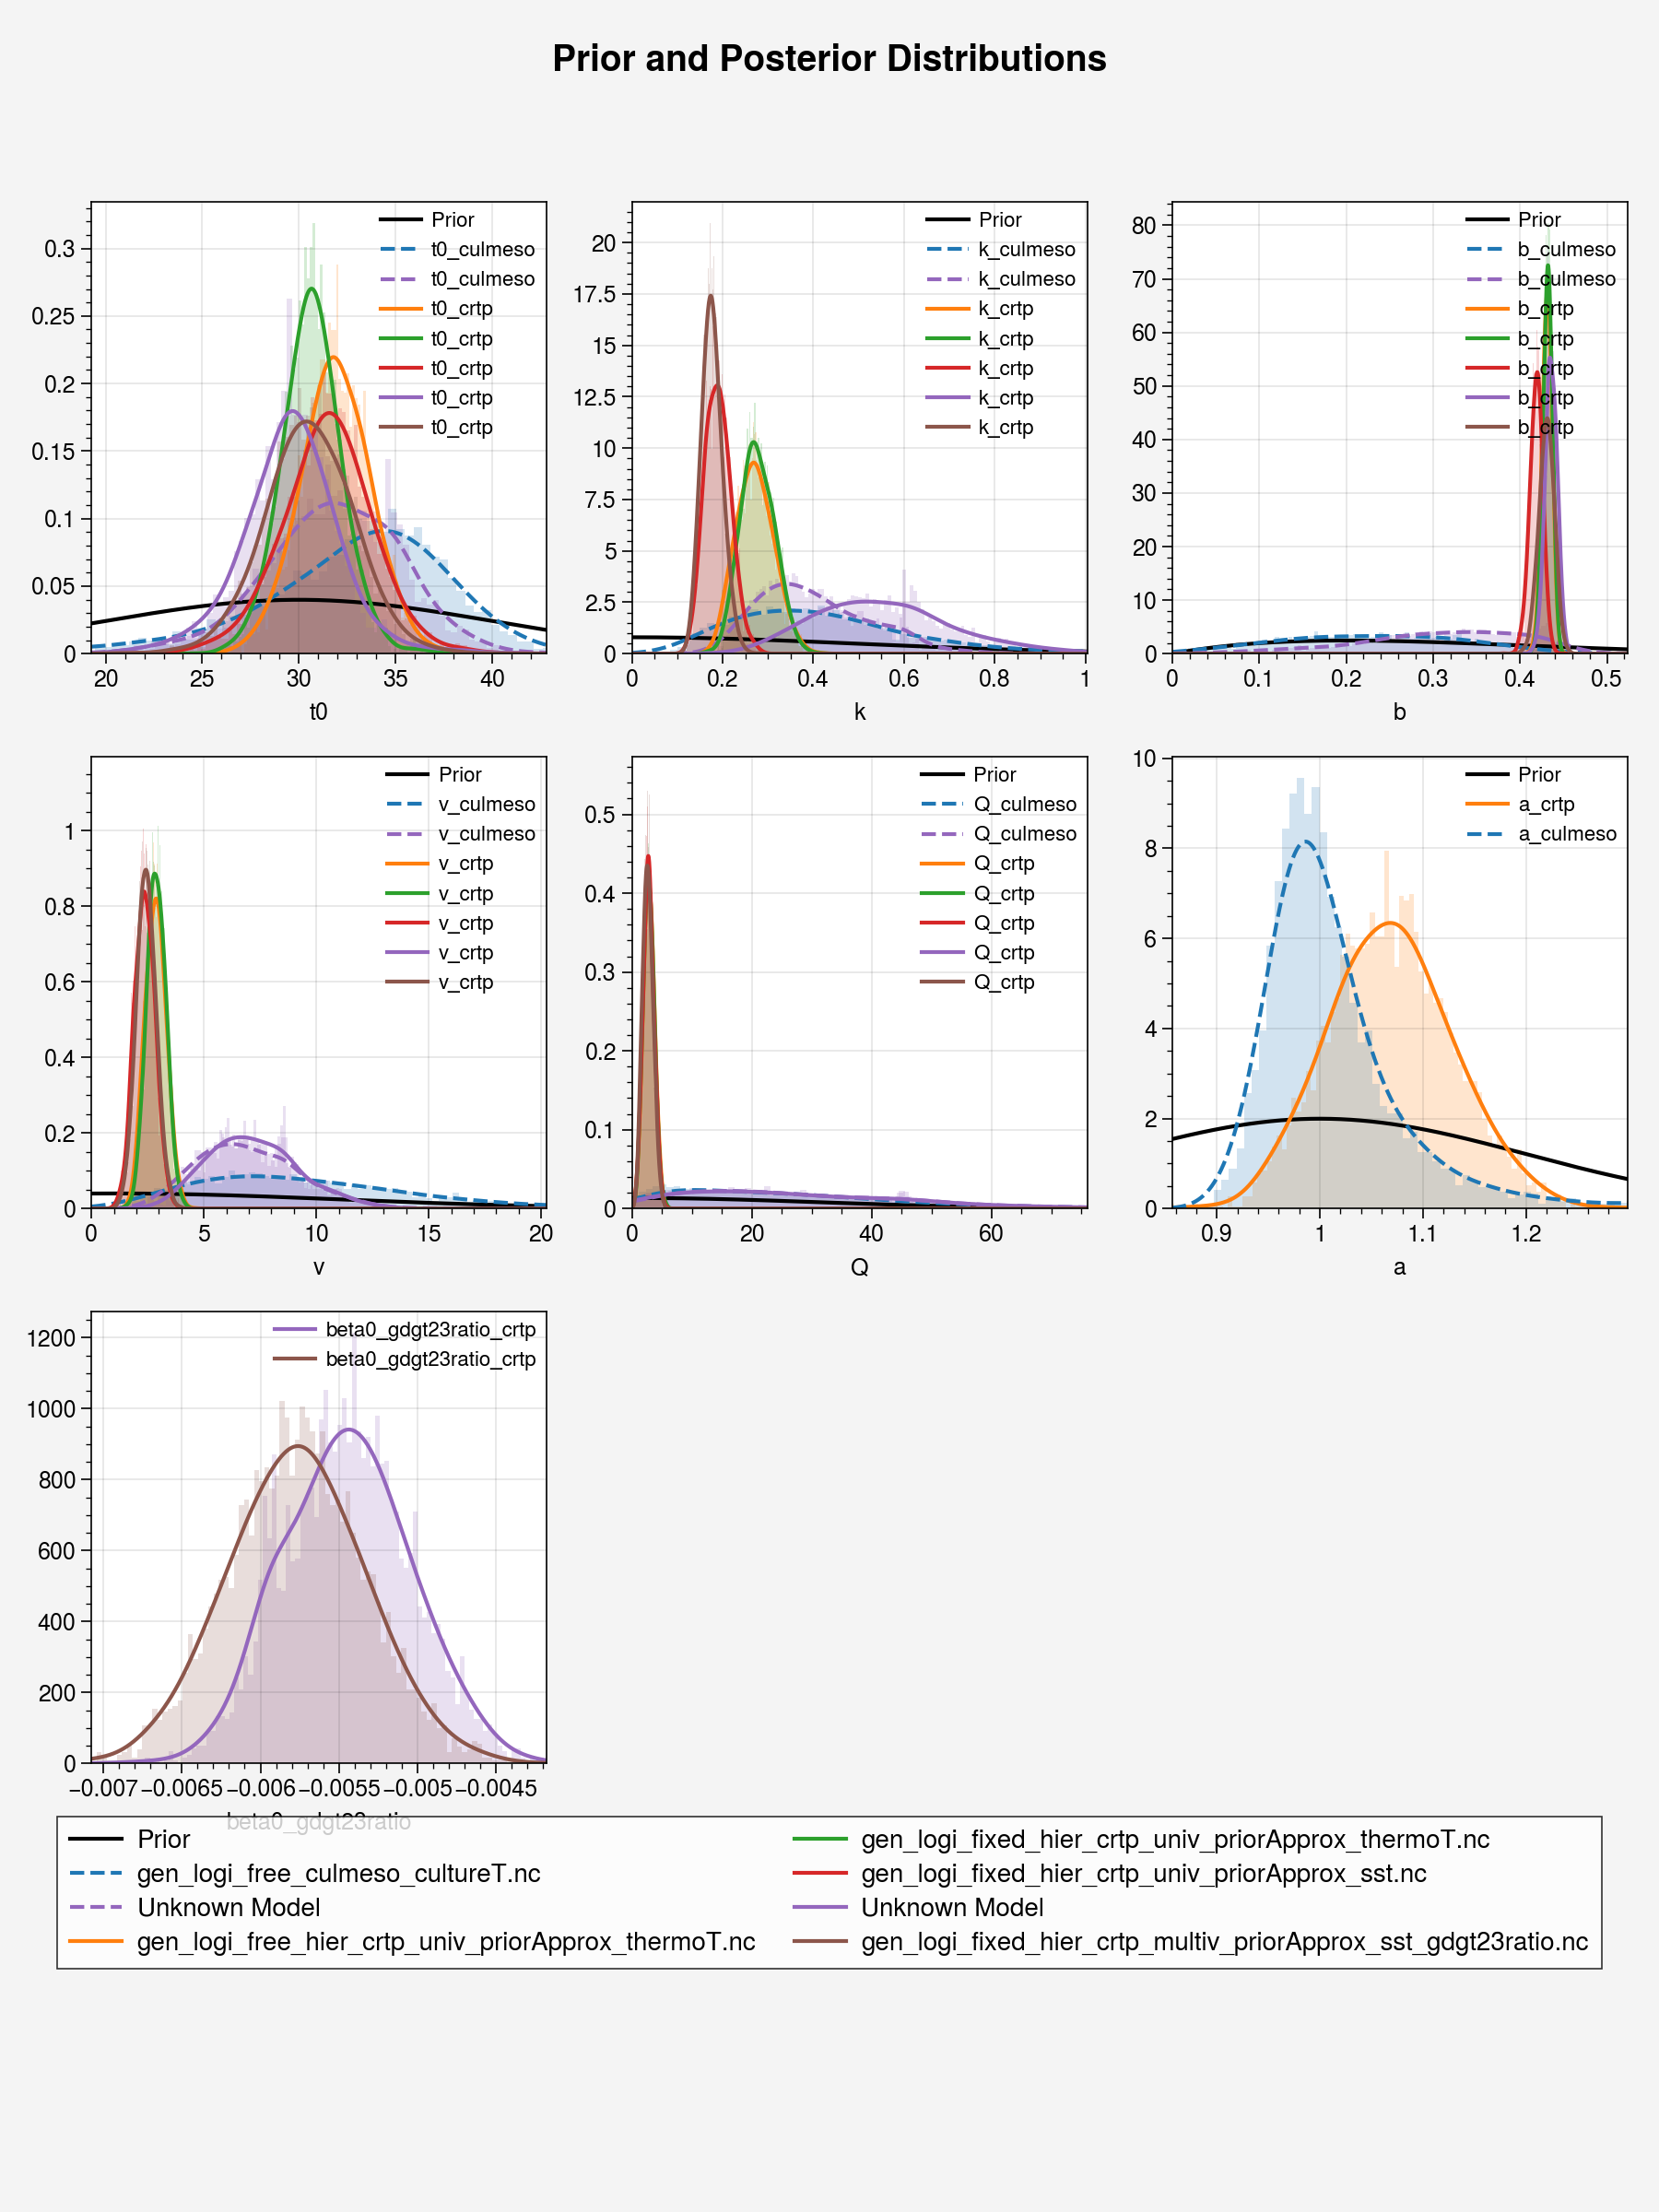

In [77]:
# Reload the dataviz_utils module to get the latest changes
import importlib
import TEXAS.dataviz_utils as dv
importlib.reload(dv)

# Test the plotting function with the updated code
fig, axes = plot_prior_distributions(
    priors_list=gen_logi_free_cul_meso_post_ds.attrs['priors'],
    posterior_datasets=[
        gen_logi_free_cul_meso_post_ds,
        gen_logi_free_hier_crtp_univ_prior_approx_post_ds,
        gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds,
        gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds_sst,
        gen_logi_fixed_hier_crtp_multiv_g23r_post_ds,
        gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_post_ds
        ],
    set_leg_max_ncol=2,
    set_fig_height_factor=4,
    use_linestyle_by_param=True,  # Enable different linestyles for different parameter suffixes
    # zoomin_dataset_idx=4
)

Text(0, 0.5, 'Scaled RI')

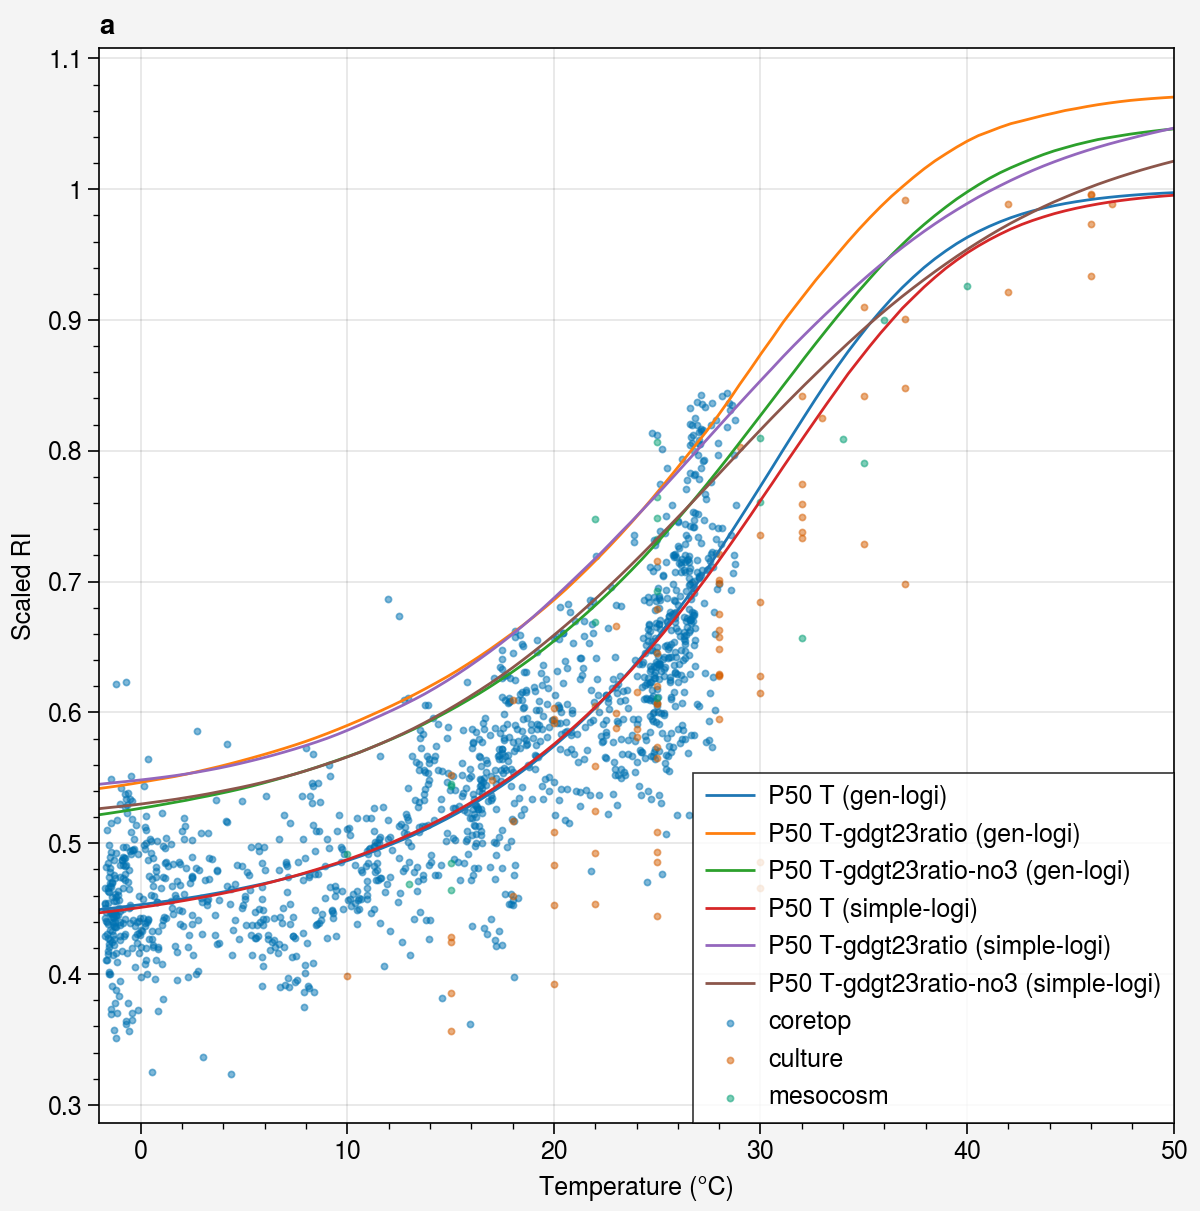

In [82]:

fig, ax = plot.subplots(width=6)

grouped = combined_df.groupby('datatype')
for name, group in grouped:
    ax.scatter(group['t_sf2tc'], group['scaledRI'], 
               s=5, label=name, alpha=0.5)

gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds = load_posterior('gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT')
gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_post_ds = load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio')
gen_logi_multiv_gdgt23ratio_no3 = load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.5')

jnt_cul_meso_crtp_post_ds = load_posterior('gen_logi_fixed_culmesocore_thermoT')
hier_crtp_multiv_gdgt23ratio_no3 = load_posterior('hier_crtp_multiv_thermoT_gdgt23ratio_no3_1.5')

post_ds_list = [
    # gen_logi_fixed_cul_meso_post_ds,
    gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds,
    gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_post_ds,
    gen_logi_multiv_gdgt23ratio_no3,
    # jnt_cul_meso_post_ds,
    jnt_cul_meso_crtp_post_ds,
    hier_crtp_multiv_g23r_post_ds,
    hier_crtp_multiv_gdgt23ratio_no3,
]
ds_labels = [
    'T (gen-logi)',
    'T-gdgt23ratio (gen-logi)',
    'T-gdgt23ratio-no3 (gen-logi)',
    'T (simple-logi)',
    'T-gdgt23ratio (simple-logi)',
    'T-gdgt23ratio-no3 (simple-logi)',
]
temperature_range = np.linspace(-2, 50, 100)
gdgt23_ratio = np.full(100, 5)  # Constant GDGT-2/3 ratio
no3_vals = np.full(100, 1e-3)  # No NO3 values used
colors = plot.get_colors('tab10',N=len(post_ds_list))
for i, sel_post_ds in enumerate(post_ds_list):
    # Generate ensemble (auto-detection)
    results = TEXAS.ensemble.generate_ensemble_auto(
        posterior_ds=sel_post_ds,
        x_vals=temperature_range,
        gdgt23ratio=gdgt23_ratio,  # Required for multivariate models
        no3=no3_vals,
        n_draws=500,
        seed=42
    )
    
    # display(results)

    # Access results
    median_pred = results['p50']        # Median prediction
    lower_bound = results['p5']         # 5th percentile
    upper_bound = results['p95']        # 95th percentile

    ax.plot(temperature_range, median_pred, lw=1, 
            c=colors[i],
            label=f'P50 {ds_labels[i]}',)
    # ax.fill_between(temperature_range, lower_bound, upper_bound,
    #                 c=colors[i],alpha=0.2, 
    #                 # label=f'95% CI {sel_post_ds.attrs["filename"]}'
    #                 )

h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='lr', ncols=1)

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Scaled RI')

# Why Normal Instead of Cauchy Priors? 🤔

## The Problem with Cauchy Priors

### 1. **Heavy Tails = Extreme Values**
- **Cauchy(0,1)**: Has infinite variance, very heavy tails
- **Problem**: Allows extreme parameter values that are unrealistic
- **Example**: `sigma_scaledRI ~ cauchy(0, 0.1)` can generate noise levels of 10+ (completely unrealistic for scaled RI)

### 2. **Poor Hierarchical Performance** 
```stan
// BAD: Cauchy hyperpriors
sigma_t0_culmeso ~ cauchy(0, 1);    // Can be huge!
t0_crtp ~ normal(t0_culmeso, sigma_t0_culmeso);  // Unstable hierarchy
```
- **Issue**: Huge `sigma` values → weak hierarchical shrinkage
- **Result**: Coretop parameters don't learn from culture+mesocosm data

### 3. **Sampling Difficulties**
- **Cauchy**: Hard for Stan to sample efficiently
- **Symptoms**: Slow convergence, divergent transitions, high Rhat
- **Cause**: Extreme tail behavior confuses NUTS sampler

## Why Normal Priors Are Better

### 1. **Realistic Constraints**
```stan
// GOOD: Informative normal priors
sigma_scaledRI_cul ~ normal(0.01, 0.1);     // Realistic noise levels
sigma_t0_culmeso ~ normal(0, 5);            // Reasonable temperature variation
sigma_k_culmeso ~ normal(0, 0.2);           // Respects k ∈ [0,1] bounds
```

### 2. **Better Hierarchical Shrinkage**
```stan
// Proper hierarchical structure
t0_culmeso ~ normal(30, 10);                    // Culture+mesocosm center
sigma_t0_culmeso ~ normal(0, 5);                // Reasonable scale
t0_crtp ~ normal(t0_culmeso, sigma_t0_culmeso); // Coretop inherits info
```
- **Result**: Purple line (coretop) properly positioned relative to orange/blue lines

### 3. **Computational Efficiency**
- **Faster sampling**: Normal distributions are Stan's "native" format
- **Better convergence**: Avoids extreme values that break sampler
- **Fewer divergences**: Smoother posterior geometry

## Scientific Justification

### **For Observation Noise** (`sigma_scaledRI`)
```stan
// OLD: sigma_scaledRI ~ cauchy(0, 0.1)
// NEW: sigma_scaledRI ~ normal(0.01, 0.1)
```
- **Expectation**: Scaled RI measurements precise to ~0.01-0.05 units
- **Cauchy problem**: Allows noise > 1.0 (larger than signal!)
- **Normal solution**: Concentrates mass around realistic values

### **For Hierarchical Scales** (`sigma_*_culmeso`)
```stan
// OLD: sigma_t0_culmeso ~ cauchy(0, 1)  
// NEW: sigma_t0_culmeso ~ normal(0, 5)
```
- **Expectation**: Coretop temperatures vary ±2-10°C from culture+mesocosm
- **Cauchy problem**: Allows ±100°C variations (nonsensical)
- **Normal solution**: Reasonable biological variation

## The "Weakly Informative" Myth

### **Cauchy ≠ Weakly Informative**
- **Common misconception**: "Cauchy(0,1) is non-informative"
- **Reality**: Cauchy is **strongly informative toward extreme values**
- **Better approach**: Use normal priors scaled to domain knowledge

### **True Weak Information**
```stan
// Domain-appropriate weak priors
sigma_t0_culmeso ~ normal(0, 5);     // "Could be 1-10°C variation"
sigma_k_culmeso ~ normal(0, 0.2);    // "k usually 0.1-0.8, so σ < 0.5"
```

## Expected Improvements in Your Models

### 1. **Faster Stan Sampling**
- Fewer divergent transitions
- Better Rhat values (< 1.01)
- Higher effective sample size

### 2. **Sensible Parameter Estimates**
- Observation noise: 0.01-0.1 range (realistic)
- Hierarchical scales: Reasonable biological variation
- No extreme outlier estimates

### 3. **Proper Hierarchical Behavior**
- Coretop estimates informed by culture+mesocosm data
- Purple line positioned correctly relative to other data
- Better uncertainty quantification

## Summary
**Normal priors** provide the right balance of:
- ✅ **Flexibility**: Allow parameter exploration
- ✅ **Constraint**: Prevent unrealistic values  
- ✅ **Efficiency**: Fast, stable Stan sampling
- ✅ **Interpretability**: Match scientific expectations

**Cauchy priors** are often:
- ❌ **Too permissive**: Allow extreme unrealistic values
- ❌ **Computationally expensive**: Slow sampling, divergences  
- ❌ **Scientifically inappropriate**: Don't match domain knowledge
- ❌ **Hierarchically weak**: Poor information sharing